# 🫀 MIMIC-III-Ext-PPG — Conditional Flow Matching
> ### Synthetic PPG Generation for AF/SR Classification

![GPU](https://img.shields.io/badge/Hardware-1x%20NVIDIA%20T4-green?style=flat-square)
![Precision](https://img.shields.io/badge/Precision-float16%20AMP-blue?style=flat-square)
![Order](https://img.shields.io/badge/Execution-%C2%A70%20%E2%86%92%20%C2%A712-orange?style=flat-square)

---

| Section | Content & Pipeline Stage |
| :---: | :--- |
| **§0** | **Setup & Config:** Dependencies, constants, and path definitions |
| **§1** | **Metadata Loading:** AF/SR filtering, Signal Quality Index (SQI), and Heart Rate (HR) |
| **§2** | **IBI Extraction:** Inter-beat interval extraction via ECG R-peaks |
| **§3** | **Data Splitting:** Subject-level split and window capping |
| **§4** | **Data Pipeline:** PyTorch `Dataset` and `DataLoader` implementation |
| **§5** | **Model Architecture:** U-Net Conditional Flow Matching model |
| **§6** | **Training:** Model training loop |
| **§7** | **Visual Generation:** Guidance scale sweep and visual sample inspection |
| **§8** | **Spectral Evaluation:** Frequency-domain analysis (PSD + LSD) |
| **§9** | **Physiological Consistency:** Cardiopulmonary metric validation |
| **§10** | **Statistical Validation:** t-SNE, Wasserstein distance, DTW, PRD, Pearson, and p-Test |
| **§11** | **Functional Evaluation:** In-domain Clf1D classifier and cross-domain testing <br>• **Part A:** In-domain evaluation (ClfUNetGAN) <br>• **Parts B–D:** Cross-domain generalization |
| **§12** | **Data Scarcity Tests:** Model robustness analysis under limited data constraints |


## §0 — Setup

In [1]:
import subprocess, sys

def install(pkg):
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', pkg, '-q',
        '--upgrade-strategy', 'only-if-needed'
    ])

install('wfdb')
install('neurokit2')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 31.5 MB/s eta 0:00:00


In [2]:
import os, ast, warnings, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, welch, find_peaks
from scipy.stats import wasserstein_distance
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from sklearn.metrics import roc_auc_score, precision_score, f1_score
from sklearn.preprocessing import StandardScaler
import wfdb
import neurokit2 as nk
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42 #42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# ── Device — single GPU ──────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ── AMP — float16 with safe init_scale ───────────────────────────────────────
# Key fix: init_scale=128 prevents GradScaler from cancelling steps
# in early epochs when gradients are large with random init.
USE_AMP = torch.cuda.is_available()
scaler  = torch.cuda.amp.GradScaler(
    enabled        = USE_AMP,
    init_scale     = 128,     # start low — prevents early overflow
    growth_factor  = 2.0,
    backoff_factor = 0.5,
    growth_interval= 1000,    # grow scale slowly
)
torch.backends.cudnn.benchmark = True
print(f"AMP    : {'float16 (init_scale=128)' if USE_AMP else 'float32'}")

# ── Paths — adjust if needed ─────────────────────────────────────────────────
BASE_PATH    = '/kaggle/input/datasets/simaosoares4/mimic-ext-experiment/p00_380/p00'
METADATA_CSV = '/kaggle/input/datasets/simaosoares4/mimic-ext-experiment/p00_380/p00/metadata.csv'
IBI_VALUES = '/kaggle/input/datasets/simaosoares4/ibi-values-b2/ibi_session_3_380.csv'
WORK_DIR     = '/kaggle/working'
IBI_SESSION  = os.path.join(WORK_DIR, 'ibi_session.csv1')   # within-session cache
CKPT_PATH    = os.path.join(WORK_DIR, 'best_model_v5.pt')  # best model only

# ── Signal constants ──────────────────────────────────────────────────────────
FS         = 125
#WIN_SEC    = 30
#WIN_LEN    = FS * WIN_SEC          # 3750 samples
#PAD_LEN    = (256 - WIN_LEN % 256) % 256   # 90 → padded to 3840 (divisible by 4^4)

# ── 10-second window constants ────────────────────────────────────────────────
WIN_SEC    = 10               # changed from 30
WIN_LEN    = FS * WIN_SEC     # 1250 samples per 10s window
WIN_LEN_30 = FS * 30          # 3750 — full WFDB file length (for slicing)
N_SUBWIN   = 3                # sub-windows per 30s file
PAD_LEN    = (256 - WIN_LEN % 256) % 256   # 30 → padded to 1280 (5×256)

print(f"WIN_LEN={WIN_LEN}  PAD={PAD_LEN} → {WIN_LEN+PAD_LEN} internally")
print(f"Each 30s WFDB file → {N_SUBWIN} sub-windows of {WIN_SEC}s")

# ── Pipeline constants ────────────────────────────────────────────────────────
CAP        = 600 #1000#400 #200       # max segments per subject per class
BATCH_SIZE = 64
EPOCHS     = 40#30        # B1 ablation phase: reduced from 50 — val loss plateaus ~epoch 10-20
LR         = 1e-4
BASE_CH    = 64 #96
T_DIM      = 256
COND_DIM   = 128
# Conditioning ablation — raw conditioning vector, cumulative:
# B0: IBI_mean_norm, IBI_std_norm
# B1: + signed rhythm label (SR=-1, AF=+1) — see PPGDataset.RHYTHM_SIGN
# B2: + RMSSD_norm (root mean square of successive RR differences)
# See build_cond()/build_cond_from_df() in §4.
RAW_COND_DIM = 4
ODE_STEPS  = 100       # Heun sampler steps at evaluation
CFG_DROP   = 0.10      # classifier-free guidance dropout during training
IBI_MIN    = 0.3       # seconds — physiological filter
IBI_MAX    = 2.0

print(f"WIN_LEN={WIN_LEN}  PAD={PAD_LEN} → {WIN_LEN+PAD_LEN} internally")
print(f"CAP={CAP}  EPOCHS={EPOCHS}  BATCH={BATCH_SIZE}  BASE_CH={BASE_CH}")
print(f"RAW_COND_DIM={RAW_COND_DIM}  (IBI_mean, IBI_std, RMSSD, rhythm_label)")


Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB
AMP    : float16 (init_scale=128)
WIN_LEN=1250  PAD=30 → 1280 internally
Each 30s WFDB file → 3 sub-windows of 10s
WIN_LEN=1250  PAD=30 → 1280 internally
CAP=600  EPOCHS=40  BATCH=64  BASE_CH=64
RAW_COND_DIM=4  (IBI_mean, IBI_std, RMSSD, rhythm_label)


## §1 — Metadata: AF/SR filter + provisional split

In [3]:
# ── Scan subjects on disk ─────────────────────────────────────────────────────
def scan_subjects(base):
    smap = {}
    if not os.path.exists(base):
        return smap
    entries = [e for e in os.listdir(base)
               if os.path.isdir(os.path.join(base, e)) and e.startswith('p')]
    if not entries:
        return smap
    if len(entries[0]) > 3:   # flat: pXXXXXX directly
        for name in entries:
            try: smap[int(name[1:])] = os.path.join(base, name)
            except ValueError: pass
    else:                      # nested: pXX/pXXXXXX
        for grp in entries:
            gp = os.path.join(base, grp)
            for name in os.listdir(gp):
                sp = os.path.join(gp, name)
                if os.path.isdir(sp) and name.startswith('p'):
                    try: smap[int(name[1:])] = sp
                    except ValueError: pass
    return smap

SUBJ_MAP = scan_subjects(BASE_PATH)
print(f"Subjects on disk: {len(SUBJ_MAP)}")

def parse_sqi(s):
    try: return ast.literal_eval(str(s))
    except: return [-99, -99, -99]

COLS = ['signal_file_name', 'folder_path', 'subject_id',
        'event_rhythm', 'vector_10s_pleth_sqi',
        'median_30s_hr', 'iqr_30s_hr']

print("Loading metadata.csv...")
df_meta = pd.read_csv(METADATA_CSV, usecols=COLS, low_memory=False)

# Primary filters on 30s records
df_30s = df_meta[df_meta['subject_id'].isin(SUBJ_MAP.keys())].copy()
df_30s = df_30s[df_30s['event_rhythm'].isin(['AF', 'SR'])].copy()
df_30s = df_30s.dropna(subset=['median_30s_hr', 'iqr_30s_hr'])
df_30s = df_30s[(df_30s['median_30s_hr'] >= 30) &
                (df_30s['median_30s_hr'] <= 200)].copy()
df_30s['wfdb_path'] = df_30s.apply(
    lambda r: os.path.join(SUBJ_MAP.get(r['subject_id'], ''), r['signal_file_name']),
    axis=1)

print(f"30s records after filters: {len(df_30s):,}")

# ── Expand each 30s record into 3 independent 10s sub-windows ────────────────
# The metadata field vector_10s_pleth_sqi has one SQI value per sub-window,
# so we can filter each sub-window individually.
rows_10s = []
for _, row in df_30s.iterrows():
    sqi_vec = parse_sqi(row['vector_10s_pleth_sqi'])
    for sw in range(N_SUBWIN):
        sqi_sw = sqi_vec[sw] if sw < len(sqi_vec) else -99
        if sqi_sw >= 0:   # per-sub-window SQI filter
            rows_10s.append({
                'signal_file_name': row['signal_file_name'],
                'subject_id':       row['subject_id'],
                'event_rhythm':     row['event_rhythm'],
                'wfdb_path':        row['wfdb_path'],
                'sub_win':          sw,          # 0, 1, or 2
                'sqi':              sqi_sw,
                'median_30s_hr':    row['median_30s_hr'],
                'iqr_30s_hr':       row['iqr_30s_hr'],
            })

df = pd.DataFrame(rows_10s)
print(f"10s sub-windows after SQI filter: {len(df):,}")
print(df['event_rhythm'].value_counts().to_string())

# ── 70/15/15 subject-level split (identical logic to 30s version) ─────────────
all_sids = df['subject_id'].unique()
af_sids  = set(df[df['event_rhythm']=='AF']['subject_id'].unique())
has_af   = [s for s in all_sids if s in af_sids]
no_af    = [s for s in all_sids if s not in af_sids]

def split_70_15_15(lst, seed=SEED):
    tr, tmp = train_test_split(lst, test_size= 0.30, random_state=seed)
    #tr, tmp = train_test_split(lst, test_size= 0.40, random_state=seed)
    vl, te  = train_test_split(tmp, test_size=0.50, random_state=seed)
    return tr, vl, te

af_tr, af_vl, af_te = split_70_15_15(has_af)
sr_tr, sr_vl, sr_te = split_70_15_15(no_af)
TRAIN_SIDS = set(af_tr) | set(sr_tr)
VAL_SIDS   = set(af_vl) | set(sr_vl)
TEST_SIDS  = set(af_te) | set(sr_te)

assert not (TRAIN_SIDS & VAL_SIDS) and not (TRAIN_SIDS & TEST_SIDS)
print(f"\n✓ Leakage-free split: Train={len(TRAIN_SIDS)} | Val={len(VAL_SIDS)} | Test={len(TEST_SIDS)}")

# Cap sub-windows per subject per class
# (each 30s file contributes up to 3 sub-windows — cap limits total per subject)
def cap_segs(df_fold, cap=CAP, seed=SEED):
    out = []
    for (_, _), grp in df_fold.groupby(['subject_id', 'event_rhythm']):
        out.append(grp.sample(min(cap, len(grp)), random_state=seed))
    return pd.concat(out).reset_index(drop=True)

df_capped = pd.concat([
    cap_segs(df[df['subject_id'].isin(TRAIN_SIDS)]),
    cap_segs(df[df['subject_id'].isin(VAL_SIDS)]),
    cap_segs(df[df['subject_id'].isin(TEST_SIDS)]),
]).reset_index(drop=True)

print(f"\nAfter split + cap={CAP}: {len(df_capped):,} sub-windows")
print(df_capped['event_rhythm'].value_counts().to_string())
print(f"\nNote: {len(df_capped):,} × {WIN_SEC}s = "
      f"{len(df_capped)*WIN_SEC/3600:.1f}h of labelled signal")

Subjects on disk: 380
Loading metadata.csv...
30s records after filters: 363,521
10s sub-windows after SQI filter: 1,090,563
event_rhythm
SR    648498
AF    442065

✓ Leakage-free split: Train=250 | Val=54 | Test=54

After split + cap=600: 213,621 sub-windows
event_rhythm
AF    110892
SR    102729

Note: 213,621 × 10s = 593.4h of labelled signal


In [4]:
# ── Cap diagnostic: is CAP actually limiting anyone, and who? ────────────────
# Uses `df` (BEFORE cap_segs) so we see how many sub-windows were available per
# (subject_id, event_rhythm) group prior to capping — same grouping cap_segs()
# itself uses. This tells us whether raising CAP would help (groups sitting
# at/above the cap) or would do nothing (groups already below it).

def cap_diagnostic(df_fold, fold_name, cap=CAP):
    counts = (df_fold.groupby(['subject_id', 'event_rhythm'])
                      .size().reset_index(name='n_segs'))
    print(f"\n--- {fold_name} ---")
    for rhythm in ['AF', 'SR']:
        sub = counts[counts['event_rhythm'] == rhythm]
        if len(sub) == 0:
            print(f"  {rhythm}: no subjects")
            continue
        n_capped        = int((sub['n_segs'] >= cap).sum())
        total_available = int(sub['n_segs'].sum())
        total_after_cap = int(sub['n_segs'].clip(upper=cap).sum())
        lost            = total_available - total_after_cap
        lost_pct        = lost / total_available * 100 if total_available else 0.0
        print(f"  {rhythm}: {len(sub)} subjects | "
              f"{n_capped} at/above cap ({n_capped/len(sub)*100:.0f}%) | "
              f"available={total_available:,}  kept={total_after_cap:,}  "
              f"lost_to_cap={lost:,} ({lost_pct:.1f}%)")
        print(f"       segs/subject — min={sub['n_segs'].min()}  "
              f"median={sub['n_segs'].median():.0f}  "
              f"mean={sub['n_segs'].mean():.1f}  max={sub['n_segs'].max()}")

cap_diagnostic(df[df['subject_id'].isin(TRAIN_SIDS)], "Train")
cap_diagnostic(df[df['subject_id'].isin(VAL_SIDS)],   "Val")
cap_diagnostic(df[df['subject_id'].isin(TEST_SIDS)],  "Test")



--- Train ---
  AF: 209 subjects | 88 at/above cap (42%) | available=284,694  kept=75,096  lost_to_cap=209,598 (73.6%)
       segs/subject — min=3  median=390  mean=1362.2  max=18006
  SR: 164 subjects | 94 at/above cap (57%) | available=445,902  kept=68,697  lost_to_cap=377,205 (84.6%)
       segs/subject — min=3  median=783  mean=2718.9  max=48960

--- Val ---
  AF: 45 subjects | 24 at/above cap (53%) | available=58,191  kept=18,102  lost_to_cap=40,089 (68.9%)
       segs/subject — min=3  median=702  mean=1293.1  max=10053
  SR: 41 subjects | 22 at/above cap (54%) | available=67,560  kept=16,830  lost_to_cap=50,730 (75.1%)
       segs/subject — min=3  median=744  mean=1647.8  max=8694

--- Test ---
  AF: 45 subjects | 23 at/above cap (51%) | available=99,180  kept=17,694  lost_to_cap=81,486 (82.2%)
       segs/subject — min=6  median=669  mean=2204.0  max=29979
  SR: 37 subjects | 24 at/above cap (65%) | available=135,036  kept=17,202  lost_to_cap=117,834 (87.3%)
       segs/subject

## §2 — IBI Feature Extraction
IBI_mean and IBI_std derived from ECG R-peaks (channel II) via NeuroKit2.
Fallback to metadata-derived values when ECG is unavailable (~10% of files).
Results saved to working directory for reuse within the session.


In [5]:
def ecg_ibi_10s(path, sub_win):
    """
    Extract IBI_mean, IBI_std and RMSSD (B2) from a 10s slice of the ECG channel.
    sub_win: 0 = first 10s, 1 = middle 10s, 2 = last 10s of the 30s file.
    """
    start = sub_win * WIN_LEN
    end   = start + WIN_LEN
    try:
        rec = wfdb.rdrecord(path)
        if 'II' not in rec.sig_name:
            return None, None, None
        ecg = rec.p_signal[start:end, rec.sig_name.index('II')]
        if len(ecg) < WIN_LEN or np.isnan(ecg).any() or np.all(ecg == ecg[0]):
            return None, None, None
        _, info = nk.ecg_peaks(ecg, sampling_rate=FS, method='neurokit')
        rr = np.diff(info['ECG_R_Peaks']) / FS
        rr = rr[(rr >= IBI_MIN) & (rr <= IBI_MAX)]
        if len(rr) < 2:   # 10s ≈ 8–14 beats → minimum 2 RR intervals
            return None, None, None
        rmssd = float(np.sqrt(np.mean(np.diff(rr) ** 2)))   # FIX (B2)
        return float(np.mean(rr)), float(np.std(rr)), rmssd
    except:
        return None, None, None


def meta_ibi(hr_med, hr_iqr):
    """Fallback: approximate IBI from 30s metadata HR (same for all 3 sub-windows).
    No real RR series available here, so RMSSD (B2) can't be estimated —
    returns None, which causes these rows to be dropped by the physiological
    filter below (a small fraction of the data, ~0.5%)."""
    try:
        return float(60. / hr_med), float((hr_iqr * 60. / hr_med**2) / 1.35), None
    except:
        return None, None, None


# ── Compute or load within-session cache ──────────────────────────────────────
# FIX (B2): a cache from a pre-RMSSD run won't have the 'RMSSD' column — detect
# and force a recompute instead of silently proceeding without the new feature.
_cache_ok = os.path.exists(IBI_VALUES)
if _cache_ok:
    _peek = pd.read_csv(IBI_VALUES, nrows=1)
    if 'RMSSD' not in _peek.columns:
        print(f"Cache at {IBI_VALUES} predates RMSSD (B2) — deleting and recomputing.")
        os.remove(IBI_SESSION)
        _cache_ok = False

if _cache_ok:
    print(f"Session cache found: {IBI_VALUES}")
    df_ibi = pd.read_csv(IBI_VALUES)
    # Match on both signal_file_name AND sub_win
    key_cache  = df_ibi['signal_file_name'] + '_' + df_ibi['sub_win'].astype(str)
    key_capped = df_capped['signal_file_name'] + '_' + df_capped['sub_win'].astype(str)
    df_ibi = df_ibi[key_cache.isin(key_capped)].copy()
    print(f"Loaded and filtered: {len(df_ibi):,} records")
else:
    print(f"Computing IBI for {len(df_capped):,} sub-windows ({WIN_SEC}s each)...")
    rows, t0 = [], time.time()
    for i, (_, row) in enumerate(df_capped.iterrows()):
        if i % 5000 == 0 and i > 0:
            eta = (time.time()-t0) / i * (len(df_capped)-i)
            print(f"  {i}/{len(df_capped)}  ETA: {eta/60:.1f} min")
        sw = int(row['sub_win'])
        im, is_, irm = ecg_ibi_10s(row['wfdb_path'], sw)
        src = 'ecg'
        if im is None:
            im, is_, irm = meta_ibi(row['median_30s_hr'], row['iqr_30s_hr'])
            src = 'meta'
        rows.append({
            'signal_file_name': row['signal_file_name'],
            'sub_win':          sw,
            'subject_id':       row['subject_id'],
            'event_rhythm':     row['event_rhythm'],
            'wfdb_path':        row['wfdb_path'],
            'IBI_mean':         im,
            'IBI_std':          is_,
            'RMSSD':            irm,   # FIX (B2)
            'source':           src,
        })
    df_ibi = pd.DataFrame(rows)
    df_ibi.to_csv(IBI_SESSION, index=False)
    print(f"Saved to {IBI_SESSION} ({(time.time()-t0)/60:.1f} min)")

# Physiological filter
df_ibi = df_ibi.dropna(subset=['IBI_mean','IBI_std','RMSSD'])   # FIX (B2): +RMSSD
df_ibi = df_ibi[(df_ibi['IBI_mean']>=IBI_MIN) & (df_ibi['IBI_mean']<=IBI_MAX) &
                (df_ibi['IBI_std']>=0) & (df_ibi['IBI_std']<=0.5)].copy()

print(f"\nAfter physiological filter: {len(df_ibi):,} sub-windows")
for r in ['AF','SR']:
    s = df_ibi[df_ibi['event_rhythm']==r]
    print(f"  {r}: {len(s):,} | IBI_mean={s['IBI_mean'].mean():.4f}s"
          f" | IBI_std={s['IBI_std'].mean():.4f}s"
          f" | RMSSD={s['RMSSD'].mean():.4f}s")

# Source breakdown
src_counts = df_ibi['source'].value_counts()
print(f"\nIBI source: ecg={src_counts.get('ecg',0):,}"
      f"  meta={src_counts.get('meta',0):,}")

Session cache found: /kaggle/input/datasets/simaosoares4/ibi-values-b2/ibi_session_3_380.csv
Loaded and filtered: 196,653 records

After physiological filter: 194,836 sub-windows
  AF: 98,725 | IBI_mean=0.6511s | IBI_std=0.1053s | RMSSD=0.1536s
  SR: 96,111 | IBI_mean=0.7468s | IBI_std=0.0423s | RMSSD=0.0635s

IBI source: ecg=194,836  meta=0


## §3 — Final Split + IBI Normalisation

In [6]:
df_train = df_ibi[df_ibi['subject_id'].isin(TRAIN_SIDS)].copy()
df_val   = df_ibi[df_ibi['subject_id'].isin(VAL_SIDS)].copy()
df_test  = df_ibi[df_ibi['subject_id'].isin(TEST_SIDS)].copy()

assert not (set(df_train['subject_id']) & set(df_val['subject_id']))
assert not (set(df_train['subject_id']) & set(df_test['subject_id']))
print("✓ No data leakage")

# Z-score normalisation using train set statistics only
IBI_MEAN_MU  = df_train['IBI_mean'].mean()
IBI_MEAN_STD = df_train['IBI_mean'].std()
IBI_STD_MU   = df_train['IBI_std'].mean()
IBI_STD_STD  = df_train['IBI_std'].std()
RMSSD_MU     = df_train['RMSSD'].mean()      # FIX (B2)
RMSSD_STD    = df_train['RMSSD'].std()       # FIX (B2)

def norm_ibi(ibi_mean, ibi_std, rmssd):
    """Z-score normalise IBI_mean, IBI_std, and RMSSD (B2) using train-set stats."""
    nm = (np.asarray(ibi_mean) - IBI_MEAN_MU) / (IBI_MEAN_STD + 1e-8)
    ns = (np.asarray(ibi_std)  - IBI_STD_MU)  / (IBI_STD_STD  + 1e-8)
    nr = (np.asarray(rmssd)    - RMSSD_MU)    / (RMSSD_STD    + 1e-8)
    return nm.astype(np.float32), ns.astype(np.float32), nr.astype(np.float32)

print(f"IBI_mean  train stats: μ={IBI_MEAN_MU:.4f}  σ={IBI_MEAN_STD:.4f}")
print(f"IBI_std   train stats: μ={IBI_STD_MU:.4f}  σ={IBI_STD_STD:.4f}")
print(f"RMSSD     train stats: μ={RMSSD_MU:.4f}  σ={RMSSD_STD:.4f}")
print()
print("╔══════════════════════════════════════════════════════════╗")
print("║              Final dataset after split + cap            ║")
print("╠══════════════════════════════════════════════════════════╣")
for name, fold in [('Train',df_train),('Val',df_val),('Test',df_test)]:
    af = (fold['event_rhythm']=='AF').sum()
    sr = (fold['event_rhythm']=='SR').sum()
    ns = fold['subject_id'].nunique()
    print(f"║  {name:5s}: {len(fold):>6} segs  (AF={af:>5}, SR={sr:>5})  {ns:>3} subjects  ║")
print("╚══════════════════════════════════════════════════════════╝")


✓ No data leakage
IBI_mean  train stats: μ=0.6967  σ=0.1414
IBI_std   train stats: μ=0.0763  σ=0.0679
RMSSD     train stats: μ=0.1118  σ=0.1037

╔══════════════════════════════════════════════════════════╗
║              Final dataset after split + cap            ║
╠══════════════════════════════════════════════════════════╣
║  Train: 131822 segs  (AF=67880, SR=63942)  232 subjects  ║
║  Val  :  30918 segs  (AF=15249, SR=15669)   49 subjects  ║
║  Test :  32096 segs  (AF=15596, SR=16500)   48 subjects  ║
╚══════════════════════════════════════════════════════════╝


## §4 — Dataset & DataLoader

In [7]:
def load_ppg(path, sub_win=0):
    """Load, filter and normalise a 10s sub-window from a 30s WFDB file."""
    start = sub_win * WIN_LEN
    end   = start + WIN_LEN
    try:
        rec = wfdb.rdrecord(path)
        if 'PLETH' not in rec.sig_name:
            return None
        sig = rec.p_signal[start:end, rec.sig_name.index('PLETH')].copy()
        if len(sig) < WIN_LEN or np.isnan(sig).any() or np.all(sig == sig[0]):
            return None
        nyq  = FS / 2
        b, a = butter(4, [0.5/nyq, 8./nyq], btype='band')
        sig  = filtfilt(b, a, sig)
        mn, mx = sig.min(), sig.max()
        if mx - mn < 1e-8:
            return None
        return (2*(sig-mn)/(mx-mn) - 1).astype(np.float32)
    except:
        return None


class PPGDataset(Dataset):
    LABEL       = {'SR': 0, 'AF': 1}
    # FIX (B1): signed rather than {0,1} so neither class collides with the
    # CFG all-zero "null" conditioning vector used in heun_sample()/cfm_loss().
    RHYTHM_SIGN = {'SR': -1.0, 'AF': 1.0}
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
        nm, ns, nr = norm_ibi(df['IBI_mean'].values, df['IBI_std'].values, df['RMSSD'].values)  # FIX (B2): +RMSSD
        self.cond    = build_cond_from_df(nm, ns, nr, df['event_rhythm'].values)
        self.sub_wins = df['sub_win'].values.astype(int)   # ← store sub_win
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        sig   = load_ppg(row['wfdb_path'], sub_win=self.sub_wins[idx])  # ← pass sub_win
        if sig is None:
            sig = np.random.uniform(-1, 1, WIN_LEN).astype(np.float32)
        label = self.LABEL[row['event_rhythm']]
        return (torch.from_numpy(sig).unsqueeze(0),
                torch.from_numpy(self.cond[idx]),
                label)


def build_cond_from_df(nm, ns, nr, rhythms):
    """Stack IBI_mean_norm, IBI_std_norm, RMSSD_norm (B2) and the signed rhythm
    label into the RAW_COND_DIM-wide conditioning vector, one rhythm string per
    row (array)."""
    sign = np.array([PPGDataset.RHYTHM_SIGN[r] for r in rhythms], dtype=np.float32)
    return np.stack([nm, ns, nr, sign], axis=1)


def build_cond(nm, ns, nr, rhythm):
    """Same as build_cond_from_df, but for generation cells where every row in
    the batch shares the SAME target rhythm (e.g. "generate N AF samples")."""
    sign = np.full(len(nm), PPGDataset.RHYTHM_SIGN[rhythm], dtype=np.float32)
    return np.stack([nm, ns, nr, sign], axis=1)


ds_train = PPGDataset(df_train)
ds_val   = PPGDataset(df_val)
ds_test  = PPGDataset(df_test)

dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=2, pin_memory=True, drop_last=True)
dl_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=2, pin_memory=True)
dl_test  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=2, pin_memory=True)

print(f"Train: {len(ds_train):,} segs  |  {len(dl_train)} batches")
print(f"Val:   {len(ds_val):,} segs  |  {len(dl_val)} batches")
print(f"Test:  {len(ds_test):,} segs  |  {len(dl_test)} batches")
s, c, l = next(iter(dl_train))
print(f"\nBatch shapes — signal: {s.shape}  cond: {c.shape}")
print(f"Signal range: [{s.min():.2f}, {s.max():.2f}]")


Train: 131,822 segs  |  2059 batches
Val:   30,918 segs  |  484 batches
Test:  32,096 segs  |  502 batches

Batch shapes — signal: torch.Size([64, 1, 1250])  cond: torch.Size([64, 4])
Signal range: [-1.00, 1.00]


## §5 — Model: 1D U-Net Conditional Flow Matching
4-level U-Net, base_ch=96, AdaGN conditioning, sinusoidal timestep embedding.
Input is reflect-padded to nearest multiple of 256 (3750→3840) to avoid
the shape mismatch that would otherwise require interpolation (which corrupts
the spectrum).


In [8]:
def sinusoidal_embedding(t, dim):
    half  = dim // 2
    freqs = torch.exp(
        -torch.arange(half, device=t.device, dtype=torch.float32)
        * (np.log(10000) / (half - 1)))
    args = t[:, None].float() * freqs[None] * 1000
    return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)


class AdaGN(nn.Module):
    """Adaptive Group Normalisation conditioned on a shared embedding."""
    def __init__(self, ch, emb_dim, groups=8):
        super().__init__()
        self.gn    = nn.GroupNorm(groups, ch)
        self.scale = nn.Linear(emb_dim, ch)
        self.shift = nn.Linear(emb_dim, ch)
        nn.init.zeros_(self.scale.weight); nn.init.ones_(self.scale.bias)
        nn.init.zeros_(self.shift.weight); nn.init.zeros_(self.shift.bias)
    def forward(self, x, emb):
        s = self.scale(emb)[:,:,None]
        b = self.shift(emb)[:,:,None]
        return self.gn(x) * (1 + s) + b


#class ResBlock(nn.Module):
#    def __init__(self, ch, emb_dim, k=5):
#        super().__init__()
#        p = k // 2
#        self.c1  = nn.Conv1d(ch, ch, k, padding=p)
#        self.c2  = nn.Conv1d(ch, ch, k, padding=p)
#        self.a1  = AdaGN(ch, emb_dim)
#        self.a2  = AdaGN(ch, emb_dim)
#        self.act = nn.SiLU()
#    def forward(self, x, emb):
#        h = self.act(self.a1(self.c1(x), emb))
#        h = self.a2(self.c2(h), emb)
#        return self.act(x + h)


class ResBlock(nn.Module):
    def __init__(self, ch, emb_dim, k=5, dropout=0.05):
        super().__init__()
        p = k // 2
        self.c1      = nn.Conv1d(ch, ch, k, padding=p)
        self.c2      = nn.Conv1d(ch, ch, k, padding=p)
        self.a1      = AdaGN(ch, emb_dim)
        self.a2      = AdaGN(ch, emb_dim)
        self.act     = nn.SiLU()
        self.drop    = nn.Dropout(dropout)   # ← adicionar

    def forward(self, x, emb):
        h = self.act(self.a1(self.c1(x), emb))
        h = self.drop(h)                     # ← adicionar
        h = self.a2(self.c2(h), emb)
        return self.act(x + h)


class UNet1D(nn.Module):
    def __init__(self, base_ch=BASE_CH, t_dim=T_DIM, cond_dim=COND_DIM):
        super().__init__()
        ch  = base_ch
        emb = t_dim + cond_dim
        self.t_proj  = nn.Sequential(nn.Linear(t_dim, t_dim), nn.SiLU(), nn.Linear(t_dim, t_dim))
        self.c_proj  = nn.Sequential(nn.Linear(RAW_COND_DIM, cond_dim), nn.SiLU(), nn.Linear(cond_dim, cond_dim))  # FIX (B1): was Linear(2, ...)
        self.in_conv = nn.Conv1d(1, ch, 7, padding=3)
        # Encoder
        self.d1 = nn.Sequential(ResBlock(ch,   emb), ResBlock(ch,   emb))
        self.p1 = nn.Conv1d(ch,   ch*2, 4, stride=4)
        self.d2 = nn.Sequential(ResBlock(ch*2, emb), ResBlock(ch*2, emb))
        self.p2 = nn.Conv1d(ch*2, ch*4, 4, stride=4)
        self.d3 = nn.Sequential(ResBlock(ch*4, emb), ResBlock(ch*4, emb))
        self.p3 = nn.Conv1d(ch*4, ch*8, 4, stride=4)
        self.d4 = nn.Sequential(ResBlock(ch*8, emb), ResBlock(ch*8, emb))
        self.p4 = nn.Conv1d(ch*8, ch*8, 4, stride=4)
        # Bottleneck
        self.mid = nn.Sequential(ResBlock(ch*8, emb), ResBlock(ch*8, emb))
        # Decoder
        self.u4  = nn.ConvTranspose1d(ch*8, ch*8, 4, stride=4)
        self.r4  = nn.Sequential(ResBlock(ch*16, emb), ResBlock(ch*16, emb))
        self.c4  = nn.Conv1d(ch*16, ch*8, 1)
        self.u3  = nn.ConvTranspose1d(ch*8, ch*4, 4, stride=4)
        self.r3  = nn.Sequential(ResBlock(ch*8,  emb), ResBlock(ch*8,  emb))
        self.c3  = nn.Conv1d(ch*8,  ch*4, 1)
        self.u2  = nn.ConvTranspose1d(ch*4, ch*2, 4, stride=4)
        self.r2  = nn.Sequential(ResBlock(ch*4,  emb), ResBlock(ch*4,  emb))
        self.c2  = nn.Conv1d(ch*4,  ch*2, 1)
        self.u1  = nn.ConvTranspose1d(ch*2, ch,   4, stride=4)
        self.r1  = nn.Sequential(ResBlock(ch*2,  emb), ResBlock(ch*2,  emb))
        self.c1  = nn.Conv1d(ch*2,  ch,   1)
        self.out = nn.Sequential(nn.GroupNorm(8, ch), nn.SiLU(),
                                 nn.Conv1d(ch, 1, 7, padding=3))

    def _emb(self, t, cond):
        te = self.t_proj(sinusoidal_embedding(t, T_DIM))
        ce = self.c_proj(cond)
        return torch.cat([te, ce], dim=-1)

    def _run(self, blocks, x, emb):
        for b in blocks: x = b(x, emb)
        return x

    def forward(self, x, t, cond):
        L = x.shape[-1]                         # 3750
        if PAD_LEN > 0:                          # pad to 3840 (mult. of 256)
            x = F.pad(x, (0, PAD_LEN), mode='reflect')
        emb = self._emb(t, cond)
        x0  = self.in_conv(x)
        s1  = self._run(self.d1, x0, emb)
        s2  = self._run(self.d2, self.p1(s1), emb)
        s3  = self._run(self.d3, self.p2(s2), emb)
        s4  = self._run(self.d4, self.p3(s3), emb)
        m   = self._run(self.mid, self.p4(s4), emb)
        def up(uc, ur, ucat, h, skip):
            h = uc(h)
            sl = min(h.shape[-1], skip.shape[-1])
            h  = torch.cat([h[...,:sl], skip[...,:sl]], dim=1)
            return ucat(self._run(ur, h, emb))
        out = self.out(up(self.u1, self.r1, self.c1,
                          up(self.u2, self.r2, self.c2,
                             up(self.u3, self.r3, self.c3,
                                up(self.u4, self.r4, self.c4, m, s4),
                                s3), s2), s1))
        return out[..., :L]                      # crop back to 3750


# Instantiate — single GPU, no DataParallel
model = UNet1D().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"UNet1D — {n_params/1e6:.2f} M parameters")
print(f"Padding: {PAD_LEN} samples  ({WIN_LEN} → {WIN_LEN+PAD_LEN} → {WIN_LEN})")

with torch.no_grad():
    _o = model(torch.randn(4,1,WIN_LEN).to(DEVICE),
               torch.rand(4).to(DEVICE),
               torch.randn(4,RAW_COND_DIM).to(DEVICE))  # FIX (B1): was (4,2)
assert _o.shape == (4, 1, WIN_LEN)
print(f"✓ Forward pass — output: {_o.shape}  (no interpolation)")


UNet1D — 54.87 M parameters
Padding: 30 samples  (1250 → 1280 → 1250)
✓ Forward pass — output: torch.Size([4, 1, 1250])  (no interpolation)


## §6 — Training
CFM loss: MSE between predicted and target velocity field.

**AMP implementation**: data preparation (noise sampling, interpolation) stays in
float32 to avoid precision issues. Only the model forward pass runs in float16.
The loss is computed in float32. This eliminates the gradient overflow that caused
the GradScaler to cancel steps when using a fully-inside-autocast implementation.


In [9]:
import copy

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# ── Exponential Moving Average of model weights ───────────────────────────────
# EMA produces smoother, better-generalising weights for generation.
# The training model (with dropout) is used for gradient updates.
# The EMA model (no dropout effect) is used for generation.
EMA_DECAY = 0.999#0.9999
ema_model = copy.deepcopy(model)
ema_model.eval()
for p in ema_model.parameters():
    p.requires_grad_(False)

def update_ema(model, ema_model, decay=EMA_DECAY):
    with torch.no_grad():
        for p, ep in zip(model.parameters(), ema_model.parameters()):
            ep.data.mul_(decay).add_(p.data, alpha=1.0 - decay)


def cfm_loss(model, x1, cond, cfg_drop=CFG_DROP, reduction='mean'):
    """
    Conditional Flow Matching loss (OT-CFM straight path).
    Data prep in float32 → model forward in float16 → loss in float32.

    reduction='mean' (default): scalar loss, unchanged behaviour — used for
    the training backward pass.
    reduction='none': per-sample loss, shape (B,) — used in validation to
    split the loss by class (AF/SR) without a second forward pass.
    """
    B = x1.size(0)
    x0      = torch.randn_like(x1)
    t       = torch.rand(B, device=x1.device)
    xt      = (1-t.view(B,1,1))*x0 + t.view(B,1,1)*x1
    ut      = x1 - x0
    mask    = (torch.rand(B, device=x1.device) < cfg_drop).float()
    cond_in = cond * (1 - mask.unsqueeze(1))
    with torch.cuda.amp.autocast(enabled=USE_AMP):
        vt_pred = model(xt, t, cond_in)
    if reduction == 'none':
        return F.mse_loss(vt_pred.float(), ut, reduction='none').mean(dim=(1, 2))
    return F.mse_loss(vt_pred.float(), ut)


print("Optimizer : AdamW  lr=1e-4  wd=1e-3")
print("Scheduler : CosineAnnealingLR")
print("EMA       : decay=0.999")
print("Loss      : CFM MSE (float32 data / float16 model / float32 loss)")

Optimizer : AdamW  lr=1e-4  wd=1e-3
Scheduler : CosineAnnealingLR
EMA       : decay=0.999
Loss      : CFM MSE (float32 data / float16 model / float32 loss)


In [10]:
# ── Sanity check: loss with random weights should be ~1.0–1.5 ────────────────
model.eval()
with torch.no_grad():
    _s, _c, _ = next(iter(dl_train))
    _chk = cfm_loss(model, _s.to(DEVICE), _c.to(DEVICE)).item()
print(f"Loss before training (random weights): {_chk:.4f}  (expected 1.0–1.5)")
assert _chk > 0.5, "ERROR: model appears pre-trained — reset the kernel."
print("✓ Confirmed random init — ready to train from scratch")
model.train()


Loss before training (random weights): 1.3652  (expected 1.0–1.5)
✓ Confirmed random init — ready to train from scratch


UNet1D(
  (t_proj): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): SiLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
  )
  (c_proj): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
  (in_conv): Conv1d(1, 64, kernel_size=(7,), stride=(1,), padding=(3,))
  (d1): Sequential(
    (0): ResBlock(
      (c1): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (c2): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (a1): AdaGN(
        (gn): GroupNorm(8, 64, eps=1e-05, affine=True)
        (scale): Linear(in_features=384, out_features=64, bias=True)
        (shift): Linear(in_features=384, out_features=64, bias=True)
      )
      (a2): AdaGN(
        (gn): GroupNorm(8, 64, eps=1e-05, affine=True)
        (scale): Linear(in_features=384, out_features=64, bias=True)
        (shift): Linear(in_features=384,

In [11]:
history       = {'train': [], 'val': [], 'val_sr': [], 'val_af': []}
best_val_loss = float('inf')
skipped_total = 0
LOG_BATCHES   = {0, 1, 10, 50, 100, 150, 200, 270}

print(f"Training — {EPOCHS} epochs  |  AMP float16  |  single GPU")
print(f"Train batches: {len(dl_train)}  |  Val batches: {len(dl_val)}")
print("─" * 64)

t0 = time.time()

for epoch in range(1, EPOCHS + 1):

    # ── Train ─────────────────────────────────────────────────────────────
    model.train()
    tr_losses     = []
    skipped_epoch = 0

    if epoch == 1:
        print("── Epoch 1 batch-level loss ──────────────────────────────────")

    for batch_idx, (sig, cond, _) in enumerate(dl_train):
        sig  = sig.to(DEVICE, non_blocking=True)
        cond = cond.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()
        loss = cfm_loss(model, sig, cond)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scale_before = scaler.get_scale()
        scaler.step(optimizer)
        scaler.update()

        # ── EMA update after every optimizer step ─────────────────────────
        update_ema(model, ema_model)

        if scaler.get_scale() < scale_before:
            skipped_epoch += 1
        tr_losses.append(loss.item())

        if epoch == 1:
            last_batch = len(dl_train) - 1
            if batch_idx in LOG_BATCHES or batch_idx == last_batch:
                running_mean = np.mean(tr_losses)
                print(f"  Batch {batch_idx:>3d}/{last_batch}  "
                      f"loss={loss.item():.4f}  "
                      f"running_mean={running_mean:.4f}")

    if epoch == 1:
        print("─" * 64)

    skipped_total += skipped_epoch
    scheduler.step()

    # ── Validate with EMA model (no dropout effect) ───────────────────────
    # FIX: per-sample loss (reduction='none') so we can split val loss by
    # class (SR=0, AF=1) — lets us tell apart "the model got worse" from
    # "the val set composition shifted toward the harder (higher IBI-std) class".
    ema_model.eval()
    vl_losses = []
    vl_losses_by_class = {0: [], 1: []}   # PPGDataset.LABEL = {'SR': 0, 'AF': 1}
    with torch.no_grad():
        for sig, cond, label in dl_val:
            sig   = sig.to(DEVICE, non_blocking=True)
            cond  = cond.to(DEVICE, non_blocking=True)
            per_sample = cfm_loss(ema_model, sig, cond, reduction='none').cpu().numpy()
            vl_losses.extend(per_sample.tolist())
            label_np = label.numpy()
            for lbl in (0, 1):
                m = label_np == lbl
                if m.any():
                    vl_losses_by_class[lbl].extend(per_sample[m].tolist())

    tr_loss    = np.mean(tr_losses)
    vl_loss    = np.mean(vl_losses)
    vl_loss_sr = float(np.mean(vl_losses_by_class[0])) if vl_losses_by_class[0] else float('nan')
    vl_loss_af = float(np.mean(vl_losses_by_class[1])) if vl_losses_by_class[1] else float('nan')
    history['train'].append(tr_loss)
    history['val'].append(vl_loss)
    history['val_sr'].append(vl_loss_sr)
    history['val_af'].append(vl_loss_af)

    if epoch % 5 == 0:
        torch.cuda.empty_cache()

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        torch.save({
            'epoch':     epoch,
            'model':     model.state_dict(),
            'ema_model': ema_model.state_dict(),   # ← save EMA weights
            'val_loss':  vl_loss,
            'ibi_stats': {
                'mean_mu': IBI_MEAN_MU, 'mean_std': IBI_MEAN_STD,
                'std_mu':  IBI_STD_MU,  'std_std':  IBI_STD_STD
            }
        }, CKPT_PATH)

    if epoch % 10 == 0 or epoch == 1:
        elapsed  = (time.time()-t0)/60
        skip_pct = skipped_epoch / len(dl_train) * 100
        print(f"Epoch {epoch:3d}/{EPOCHS}  train={tr_loss:.4f}  val={vl_loss:.4f}"
              f"  (SR={vl_loss_sr:.4f} AF={vl_loss_af:.4f})"
              f"  best={best_val_loss:.4f}  skip={skip_pct:.0f}%  [{elapsed:.1f} min]")

print("─" * 64)
print(f"Training complete.  Best val loss: {best_val_loss:.4f}")
print(f"Total skipped steps: {skipped_total} / {EPOCHS*len(dl_train)}"
      f"  ({skipped_total/(EPOCHS*len(dl_train))*100:.1f}%)")

Training — 40 epochs  |  AMP float16  |  single GPU
Train batches: 2059  |  Val batches: 484
────────────────────────────────────────────────────────────────
── Epoch 1 batch-level loss ──────────────────────────────────
  Batch   0/2058  loss=1.3517  running_mean=1.3517
  Batch   1/2058  loss=1.1277  running_mean=1.2397
  Batch  10/2058  loss=0.4609  running_mean=0.7758
  Batch  50/2058  loss=0.2545  running_mean=0.4004
  Batch 100/2058  loss=0.1926  running_mean=0.3070
  Batch 150/2058  loss=0.1872  running_mean=0.2688
  Batch 200/2058  loss=0.1814  running_mean=0.2453
  Batch 270/2058  loss=0.1687  running_mean=0.2249
  Batch 2058/2058  loss=0.1441  running_mean=0.1485
────────────────────────────────────────────────────────────────
Epoch   1/40  train=0.1485  val=0.1452  (SR=0.1356 AF=0.1552)  best=0.1452  skip=0%  [23.0 min]
Epoch  10/40  train=0.1130  val=0.1063  (SR=0.0922 AF=0.1208)  best=0.1063  skip=0%  [94.9 min]
Epoch  20/40  train=0.1088  val=0.1044  (SR=0.0900 AF=0.1191) 

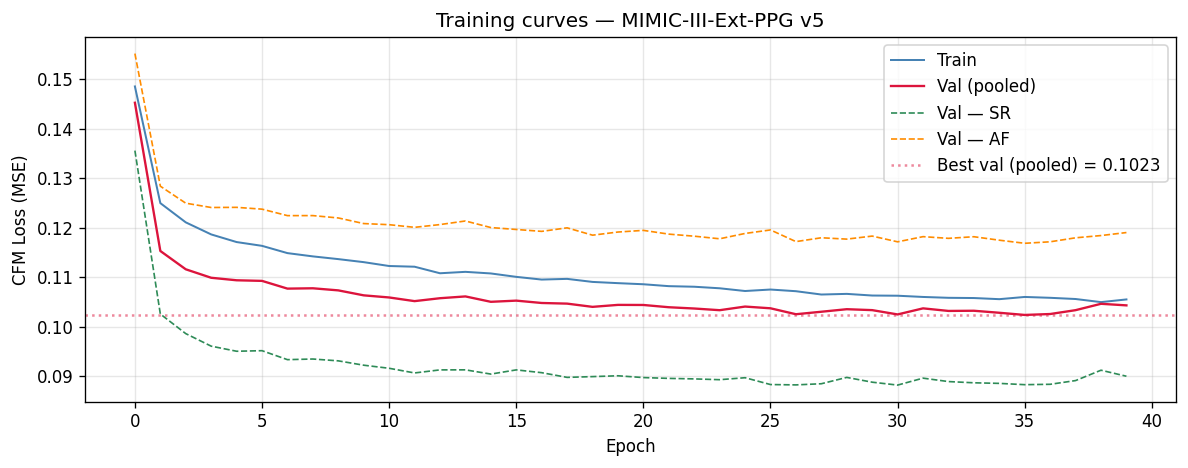

Final val loss — pooled: 0.1043  SR: 0.0900  AF: 0.1190
Best pooled epoch (#36) per-class loss — SR: 0.0882  AF: 0.1168


In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history['train'],  label='Train',       color='steelblue', lw=1.2)
ax.plot(history['val'],    label='Val (pooled)', color='crimson',   lw=1.4)
ax.plot(history['val_sr'], label='Val — SR',     color='seagreen',  lw=1.0, ls='--')
ax.plot(history['val_af'], label='Val — AF',     color='darkorange',lw=1.0, ls='--')
ax.axhline(best_val_loss, color='crimson', ls=':', alpha=0.5,
           label=f'Best val (pooled) = {best_val_loss:.4f}')
ax.set_xlabel('Epoch'); ax.set_ylabel('CFM Loss (MSE)')
ax.set_title('Training curves — MIMIC-III-Ext-PPG v5')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Final val loss — pooled: {history['val'][-1]:.4f}  "
      f"SR: {history['val_sr'][-1]:.4f}  AF: {history['val_af'][-1]:.4f}")
print(f"Best pooled epoch (#{np.argmin(history['val'])+1}) per-class loss — "
      f"SR: {history['val_sr'][np.argmin(history['val'])]:.4f}  "
      f"AF: {history['val_af'][np.argmin(history['val'])]:.4f}")


## §7 — Guidance Scale Sweep + Visual Generation
Find the optimal CFG scale by minimising LSD on a small sample, then generate
a mini-batch of 50 synthetic signals per class for visual inspection.


In [13]:
# Load best checkpoint
ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)

# Load EMA weights into ema_model (already instantiated in §6) — used for ALL
# sampling from this point on (§7, §8, §9, §10, §11).
ema_model.load_state_dict(ckpt['ema_model'])
ema_model.eval()

# FIX: also restore `model` to the SAME best checkpoint and freeze it in eval
# mode. Previously `model` was left at the LAST epoch's weights in .train()
# mode (dropout=0.05 active), and §8/§11 were sampling from it by mistake
# instead of ema_model — injecting non-deterministic dropout noise into the
# reported LSD, physiological, statistical and functional metrics. `model`
# is no longer used for sampling anywhere below; kept only for reference.
model.load_state_dict(ckpt['model'])
model.eval()

print(f"Best checkpoint loaded — epoch {ckpt['epoch']}  val_loss={ckpt['val_loss']:.4f}")
print("Using EMA model for generation everywhere from this point on.")

@torch.no_grad()
def heun_sample(mdl, cond, n_steps, cfg_scale):
    """Heun (2nd-order) ODE sampler with classifier-free guidance."""
    B    = cond.size(0)
    x    = torch.randn(B, 1, WIN_LEN, device=cond.device)
    dt   = 1. / n_steps
    null = torch.zeros_like(cond)
    for i in range(n_steps):
        t_val = torch.full((B,), i*dt, device=cond.device)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            v_c = mdl(x, t_val, cond); v_u = mdl(x, t_val, null)
        v  = v_u + cfg_scale * (v_c - v_u)
        xp = x + dt * v
        t_next = torch.full((B,), (i+1)*dt, device=cond.device)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            v2_c = mdl(xp, t_next, cond); v2_u = mdl(xp, t_next, null)
        v2 = v2_u + cfg_scale * (v2_c - v2_u)
        x  = x + dt * 0.5 * (v + v2)
    return x.float()   # return float32


def lsd(real_b, synth_b, n_fft=512, band=None):
    """Log Spectral Distance (mean over batch).

    band=None restricts nothing — legacy behaviour, RMS over the full
    0..Nyquist spectrum returned by welch().
    band=(fmin, fmax) restricts the RMS to that frequency range (Hz).

    FIX: real signals go through a 0.5-8 Hz Butterworth bandpass in
    load_ppg(), so real PSD is ~numerically-zero outside that band. If
    synthetic samples carry even a small residual outside the passband,
    the log-power difference at those bins blows up and can dominate the
    RMS, even though it says nothing about waveform fidelity inside the
    physiologically relevant band. Use band=(0.5, 8.0) to match the filter.
    """
    eps  = 1e-10
    vals = []
    mask = None
    for i in range(min(len(real_b), len(synth_b))):
        f, r = welch(real_b[i],  fs=FS, nperseg=n_fft)
        _, s = welch(synth_b[i], fs=FS, nperseg=n_fft)
        if band is not None and mask is None:
            mask = (f >= band[0]) & (f <= band[1])
        r_use, s_use = (r[mask], s[mask]) if band is not None else (r, s)
        v = np.sqrt(np.mean((10*np.log10(r_use+eps) - 10*np.log10(s_use+eps))**2))
        if not np.isnan(v): vals.append(v)
    return float(np.mean(vals)) if vals else np.nan


print("Heun sampler and LSD function defined.")


Best checkpoint loaded — epoch 36  val_loss=0.1023
Using EMA model for generation everywhere from this point on.
Heun sampler and LSD function defined.


Sweep: 64 samples/class | 50 ODE steps
Candidates: [0.5, 1.0, 1.5, 2.0, 3.0, 5.0]

  gs=0.5  LSD AF=6.73  SR=8.14  mean=7.44 dB
  gs=1.0  LSD AF=5.77  SR=7.03  mean=6.40 dB
  gs=1.5  LSD AF=6.02  SR=6.24  mean=6.13 dB
  gs=2.0  LSD AF=5.72  SR=6.52  mean=6.12 dB
  gs=3.0  LSD AF=6.00  SR=6.51  mean=6.26 dB
  gs=5.0  LSD AF=6.27  SR=6.48  mean=6.38 dB

✓ Best guidance scale: 2.0  (LSD=6.12 dB)


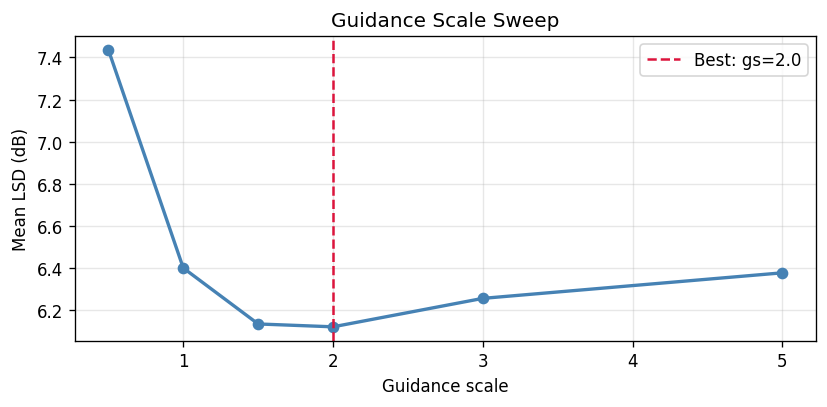

In [14]:
# ── Guidance scale sweep ─────────────────────────────────────────────────────
GS_CANDIDATES = [0.5, 1.0, 1.5, 2.0, 3.0, 5.0]
N_SWEEP       = 64
STEPS_SWEEP   = 50    # faster — half ODE steps for sweep

# Prepare sweep conditioning from test set
sw_cond, sw_real = {}, {}
for rh in ['AF', 'SR']:
    df_cls = df_test[df_test['event_rhythm']==rh].sample(N_SWEEP, random_state=SEED)
    nm, ns, nr = norm_ibi(df_cls['IBI_mean'].values, df_cls['IBI_std'].values, df_cls['RMSSD'].values)  # FIX (B2)
    sw_cond[rh] = torch.tensor(build_cond(nm, ns, nr, rh), dtype=torch.float32).to(DEVICE)  # FIX (B2): +RMSSD
    sw_real[rh] = np.array([s for s in
                            [load_ppg(r['wfdb_path']) for _,r in df_cls.iterrows()]
                            if s is not None][:N_SWEEP])

print(f"Sweep: {N_SWEEP} samples/class | {STEPS_SWEEP} ODE steps")
print(f"Candidates: {GS_CANDIDATES}\n")

sweep_lsd = {}
for gs in GS_CANDIDATES:
    lsd_vals = []
    for rh in ['AF', 'SR']:
        syn = heun_sample(ema_model, sw_cond[rh], STEPS_SWEEP, gs).cpu().numpy().squeeze(1)
        lsd_vals.append(lsd(sw_real[rh], syn, band=(0.5, 8.0)))  # FIX: band-restricted
    mean_lsd = np.nanmean(lsd_vals)
    sweep_lsd[gs] = mean_lsd
    print(f"  gs={gs:.1f}  LSD AF={lsd_vals[0]:.2f}  SR={lsd_vals[1]:.2f}"
          f"  mean={mean_lsd:.2f} dB")

BEST_GS = min(sweep_lsd, key=sweep_lsd.get)
print(f"\n✓ Best guidance scale: {BEST_GS}  (LSD={sweep_lsd[BEST_GS]:.2f} dB)")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(list(sweep_lsd.keys()), list(sweep_lsd.values()), 'o-', color='steelblue', lw=2)
ax.axvline(BEST_GS, color='crimson', ls='--', label=f'Best: gs={BEST_GS}')
ax.set_xlabel('Guidance scale'); ax.set_ylabel('Mean LSD (dB)')
ax.set_title('Guidance Scale Sweep'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


Generated: AF=50  SR=50


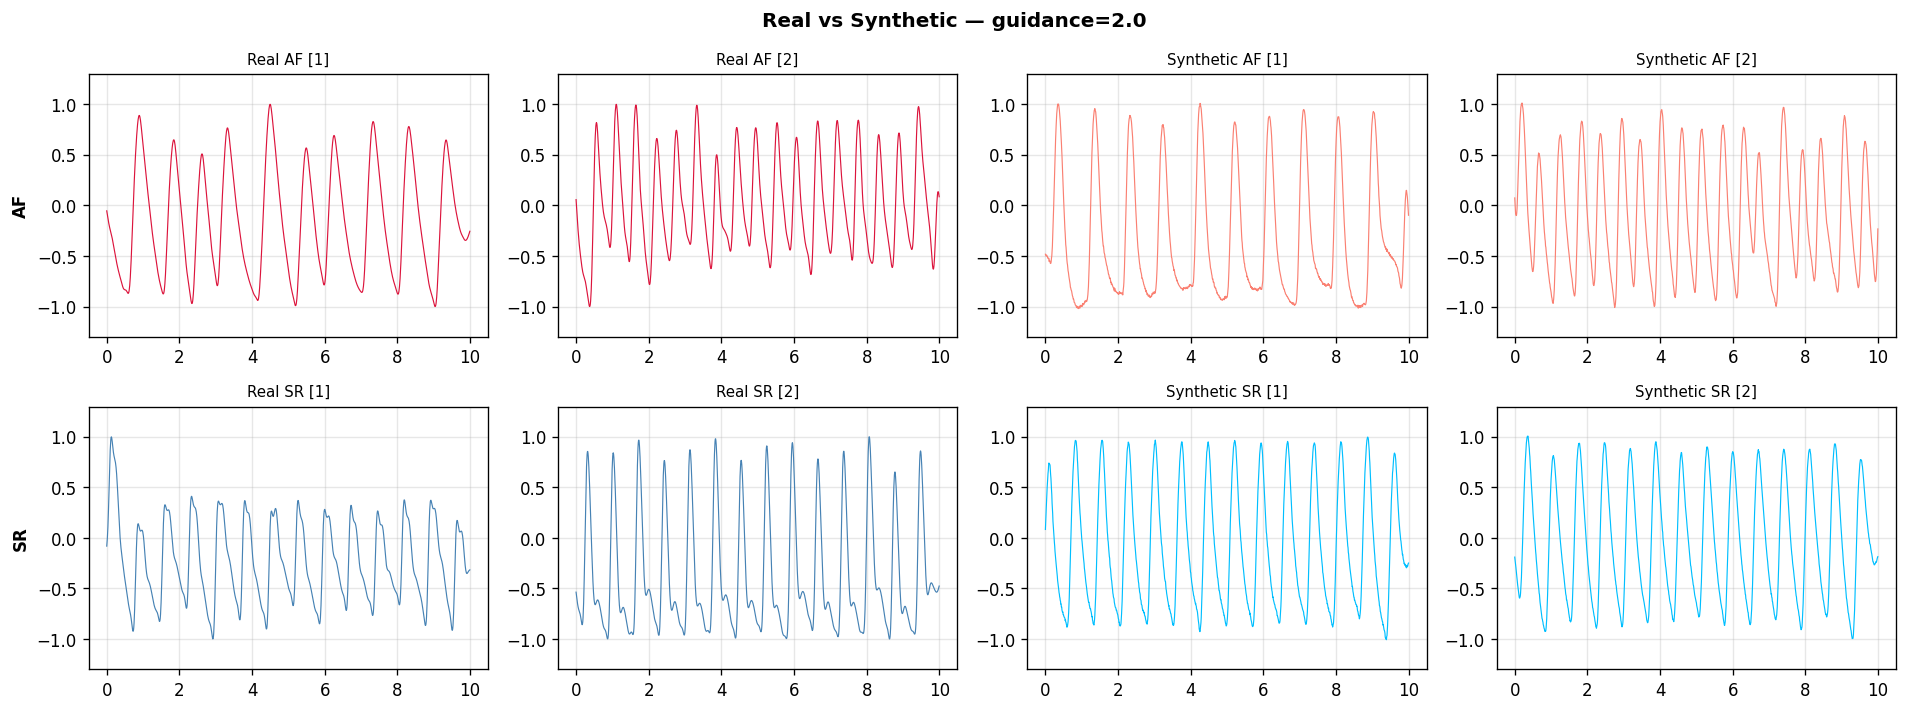

In [15]:
# ── Visual generation — 50 signals per class ─────────────────────────────────
N_VIS = 50

vis_synth, vis_real = {}, {}
for rh in ['AF', 'SR']:
    df_cls = df_test[df_test['event_rhythm']==rh].sample(
        min(N_VIS, len(df_test[df_test['event_rhythm']==rh])), random_state=SEED)
    nm, ns, nr = norm_ibi(df_cls['IBI_mean'].values, df_cls['IBI_std'].values, df_cls['RMSSD'].values)  # FIX (B2)
    cond   = torch.tensor(build_cond(nm, ns, nr, rh), dtype=torch.float32).to(DEVICE)  # FIX (B2): +RMSSD
    synth  = []
    for i in range(0, len(cond), 64):
        synth.append(heun_sample(ema_model, cond[i:i+64], ODE_STEPS, BEST_GS).cpu().numpy())
    vis_synth[rh] = np.concatenate(synth).squeeze(1)
    vis_real[rh]  = np.array([s for s in
                              [load_ppg(r['wfdb_path']) for _,r in df_cls.iterrows()]
                              if s is not None][:N_VIS])

print(f"Generated: AF={vis_synth['AF'].shape[0]}  SR={vis_synth['SR'].shape[0]}")

t_ax = np.arange(WIN_LEN) / FS
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ri, rh in enumerate(['AF', 'SR']):
    for ci in range(4):
        ax  = axes[ri][ci]
        sig = vis_real[rh][ci] if ci < 2 else vis_synth[rh][ci-2]
        lbl = f"{'Real' if ci<2 else 'Synthetic'} {rh} [{ci%2+1}]"
        clr = ('crimson' if rh=='AF' else 'steelblue') if ci<2               else ('salmon' if rh=='AF' else 'deepskyblue')
        ax.plot(t_ax, sig, lw=0.7, color=clr)
        ax.set_title(lbl, fontsize=9); ax.set_ylim(-1.3,1.3); ax.grid(alpha=0.3)
        if ci==0: ax.set_ylabel(rh, fontweight='bold')
plt.suptitle(f'Real vs Synthetic — guidance={BEST_GS}', fontweight='bold')
plt.tight_layout(); plt.show()


## §8 — Spectral Evaluation (PSD + LSD)

LSD AF    (0.5-8 Hz) : 6.1404 dB   |  full spectrum: 33.1660 dB
LSD SR    (0.5-8 Hz) : 6.2623 dB   |  full spectrum: 33.0565 dB
LSD mean  (0.5-8 Hz) : 6.2013 dB   |  full spectrum: 33.1113 dB
Note: the '~3-6 dB' figure referenced in earlier (v3) notebooks was not
independently re-verified and may not be a directly comparable target for
this dataset/window length — treat as indicative only, not a hard benchmark.


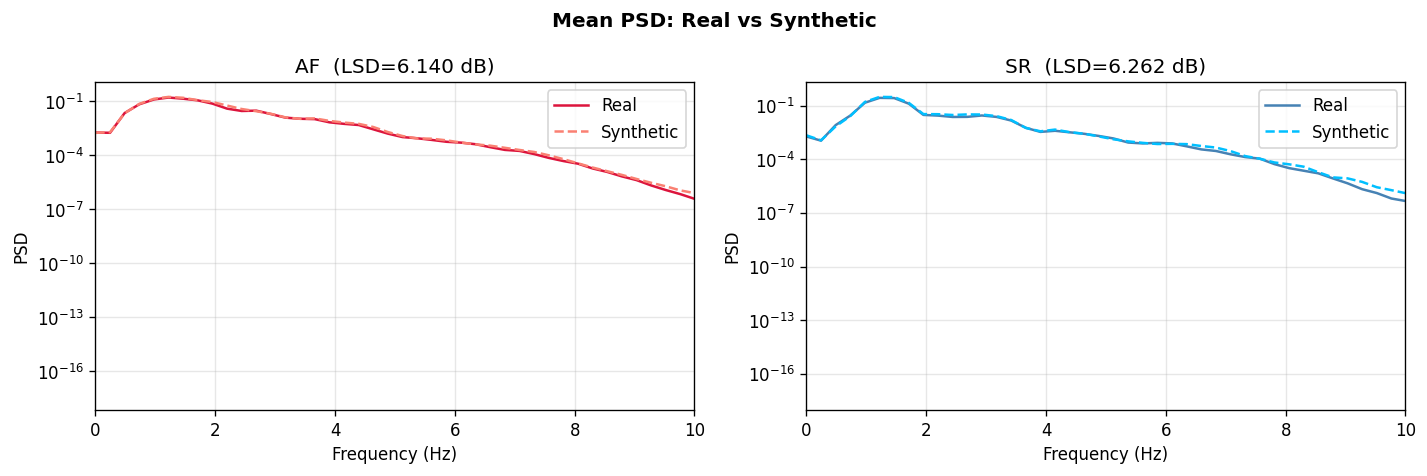

In [16]:
# Generate full evaluation set (300 per class with best guidance scale)
N_EVAL = 300
eval_synth, eval_real = {}, {}
for rh in ['AF', 'SR']:
    df_cls = df_test[df_test['event_rhythm']==rh].sample(
        min(N_EVAL, len(df_test[df_test['event_rhythm']==rh])), random_state=SEED)
    nm, ns, nr = norm_ibi(df_cls['IBI_mean'].values, df_cls['IBI_std'].values, df_cls['RMSSD'].values)  # FIX (B2)
    cond   = torch.tensor(build_cond(nm, ns, nr, rh), dtype=torch.float32).to(DEVICE)  # FIX (B2): +RMSSD
    synth  = []
    for i in range(0, len(cond), 64):
        synth.append(heun_sample(ema_model, cond[i:i+64], ODE_STEPS, BEST_GS).cpu().numpy())  # FIX: was `model`
    eval_synth[rh] = np.concatenate(synth).squeeze(1)
    real = [load_ppg(r['wfdb_path']) for _,r in df_cls.iterrows()]
    eval_real[rh]  = np.array([s for s in real if s is not None][:N_EVAL])

# FIX: report both the full-spectrum (legacy) and the 0.5-8 Hz
# band-restricted LSD side by side. If the full-spectrum number is much
# higher, that confirms near-zero real power outside the passband was
# dominating the metric rather than reflecting true waveform fidelity.
lsd_af_full = lsd(eval_real['AF'], eval_synth['AF'])
lsd_sr_full = lsd(eval_real['SR'], eval_synth['SR'])
lsd_af   = lsd(eval_real['AF'], eval_synth['AF'], band=(0.5, 8.0))
lsd_sr   = lsd(eval_real['SR'], eval_synth['SR'], band=(0.5, 8.0))
lsd_mean      = (lsd_af + lsd_sr) / 2
lsd_mean_full = (lsd_af_full + lsd_sr_full) / 2
print(f"LSD AF    (0.5-8 Hz) : {lsd_af:.4f} dB   |  full spectrum: {lsd_af_full:.4f} dB")
print(f"LSD SR    (0.5-8 Hz) : {lsd_sr:.4f} dB   |  full spectrum: {lsd_sr_full:.4f} dB")
print(f"LSD mean  (0.5-8 Hz) : {lsd_mean:.4f} dB   |  full spectrum: {lsd_mean_full:.4f} dB")
print("Note: the '~3-6 dB' figure referenced in earlier (v3) notebooks was not")
print("independently re-verified and may not be a directly comparable target for")
print("this dataset/window length — treat as indicative only, not a hard benchmark.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, rh, cr, cs in zip(axes, ['AF','SR'],
    ['crimson','steelblue'], ['salmon','deepskyblue']):
    psd_r, psd_s = [], []
    for i in range(min(200, len(eval_real[rh]))):
        _, p = welch(eval_real[rh][i],  fs=FS, nperseg=512); psd_r.append(p)
        _, p = welch(eval_synth[rh][i], fs=FS, nperseg=512); psd_s.append(p)
    freq = np.linspace(0, FS/2, len(psd_r[0]))
    ax.semilogy(freq, np.mean(psd_r,0), color=cr, lw=1.5, label='Real')
    ax.semilogy(freq, np.mean(psd_s,0), color=cs, lw=1.5, ls='--', label='Synthetic')
    ax.set_xlim(0,10); ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('PSD')
    ax.set_title(f'{rh}  (LSD={lsd_af if rh=="AF" else lsd_sr:.3f} dB)')
    ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('Mean PSD: Real vs Synthetic', fontweight='bold')
plt.tight_layout(); plt.show()


# Sampling speed benchmark

In [17]:
# ── Sampling speed benchmark ──────────────────────────────────────────────────
# Mede o tempo do sampler Heun ODE para diferentes números de amostras.
# Reporta: tempo total, tempo por amostra, amostras por segundo.
import time

N_BENCHMARK   = [1, 8, 32, 64]   # batch sizes a testar
N_STEPS_LIST  = [ODE_STEPS]      # testar com os ODE steps usados (100)
N_WARMUP      = 2                 # warmup runs (não contam — aquece CUDA)

# Conditioning fixo para o benchmark (AF, valores médios normalizados)
_nm = np.zeros(max(N_BENCHMARK), dtype=np.float32)   # IBI_mean normalizado = 0
_ns = np.zeros(max(N_BENCHMARK), dtype=np.float32)   # IBI_std normalizado = 0
_nr = np.zeros(max(N_BENCHMARK), dtype=np.float32)   # RMSSD normalizado = 0
_cond_bench = torch.tensor(
    build_cond(_nm, _ns, _nr, 'AF'), dtype=torch.float32).to(DEVICE)

print('Sampling speed benchmark — Heun ODE sampler')
print(f'Device: {DEVICE}  |  WIN_LEN: {WIN_LEN}  |  ODE steps: {ODE_STEPS}')
print(f'Warmup: {N_WARMUP} runs (não contabilizados)\n')

results_speed = {}

for n_steps in N_STEPS_LIST:
    print(f'── ODE steps = {n_steps} ──────────────────────────────────────────')
    for bs in N_BENCHMARK:
        cond_b = _cond_bench[:bs]

        # Warmup
        for _ in range(N_WARMUP):
            with torch.no_grad():
                _ = heun_sample(ema_model, cond_b, n_steps, BEST_GS)
        torch.cuda.synchronize()

        # Medição
        N_REPS = max(1, 10 // bs)   # mais repetições para batches pequenos
        t0 = time.perf_counter()
        for _ in range(N_REPS):
            with torch.no_grad():
                out = heun_sample(ema_model, cond_b, n_steps, BEST_GS)
        torch.cuda.synchronize()
        t1 = time.perf_counter()

        total_s      = (t1 - t0) / N_REPS
        per_sample_s = total_s / bs
        throughput   = bs / total_s

        results_speed[(n_steps, bs)] = dict(
            total_s      = total_s,
            per_sample_s = per_sample_s,
            throughput   = throughput,
        )
        print(f'  batch={bs:>3}  reps={N_REPS}  '
              f'total={total_s:.3f}s  '
              f'per_sample={per_sample_s*1000:.1f}ms  '
              f'throughput={throughput:.1f} samples/s')
    print()

# ── Tabela resumo ─────────────────────────────────────────────────────────────
print('=' * 70)
print(f'  Sampling Speed Summary — Heun ODE, {ODE_STEPS} steps, {WIN_LEN} samples @ {FS} Hz')
print('=' * 70)
print(f"  {'Batch':>6}  {'Time/sample (ms)':>18}  {'Throughput (s/s)':>18}  {'Total (s)':>10}")
print('  ' + '─' * 60)
for bs in N_BENCHMARK:
    r = results_speed[(ODE_STEPS, bs)]
    # throughput em "seconds of signal generated per second of wall time"
    signal_s_per_wall_s = bs * WIN_SEC / r['total_s']
    print(f"  {bs:>6}  "
          f"{r['per_sample_s']*1000:>18.1f}  "
          f"{r['throughput']:>18.1f}  "
          f"{r['total_s']:>10.3f}s")
print('=' * 70)
print()

# Referência: tempo para gerar N_EVAL=300 amostras (como em §8)
r64 = results_speed[(ODE_STEPS, 64)]
t_300 = (300 / 64) * r64['total_s']
print(f'Estimativa para gerar {N_EVAL} amostras (batch=64): ~{t_300:.1f}s')
print(f'Estimativa para gerar 1000 amostras (batch=64):     '
      f'~{(1000/64)*r64["total_s"]:.1f}s')
print()
print(f'Tempo de sinal gerado por segundo de wall time (batch=64):')
print(f'  {64 * WIN_SEC / r64["total_s"]:.1f}s de PPG sintético / segundo de computação')
print()
print('Nota: OT-CFM com Heun ODE a 100 steps é substancialmente mais rápido')
print('que DDPM ancestral (1000 steps) — factor teórico de 10x em steps,')
print('com overhead prático dependente do tamanho do batch e da GPU.')

Sampling speed benchmark — Heun ODE sampler
Device: cuda  |  WIN_LEN: 1250  |  ODE steps: 100
Warmup: 2 runs (não contabilizados)

── ODE steps = 100 ──────────────────────────────────────────
  batch=  1  reps=10  total=7.859s  per_sample=7858.8ms  throughput=0.1 samples/s
  batch=  8  reps=1  total=7.586s  per_sample=948.3ms  throughput=1.1 samples/s
  batch= 32  reps=1  total=13.142s  per_sample=410.7ms  throughput=2.4 samples/s
  batch= 64  reps=1  total=24.180s  per_sample=377.8ms  throughput=2.6 samples/s

  Sampling Speed Summary — Heun ODE, 100 steps, 1250 samples @ 125 Hz
   Batch    Time/sample (ms)    Throughput (s/s)   Total (s)
  ────────────────────────────────────────────────────────────
       1              7858.8                 0.1       7.859s
       8               948.3                 1.1       7.586s
      32               410.7                 2.4      13.142s
      64               377.8                 2.6      24.180s

Estimativa para gerar 300 amostras (bat

## §9 — Physiological Consistency

Computing physiological features from PPG peaks...

Metric           Real AF    Synth AF     Real SR    Synth SR
──────────────────────────────────────────────────────────
  HR          87.744±19.047  90.617±19.965  81.488±12.797  81.876±13.313
  IBI_mean    0.720±0.174  0.697±0.166  0.755±0.122  0.752±0.119
  IBI_std     0.147±0.083  0.133±0.078  0.053±0.069  0.047±0.062
  RMSSD       0.212±0.120  0.194±0.122  0.076±0.108  0.070±0.095


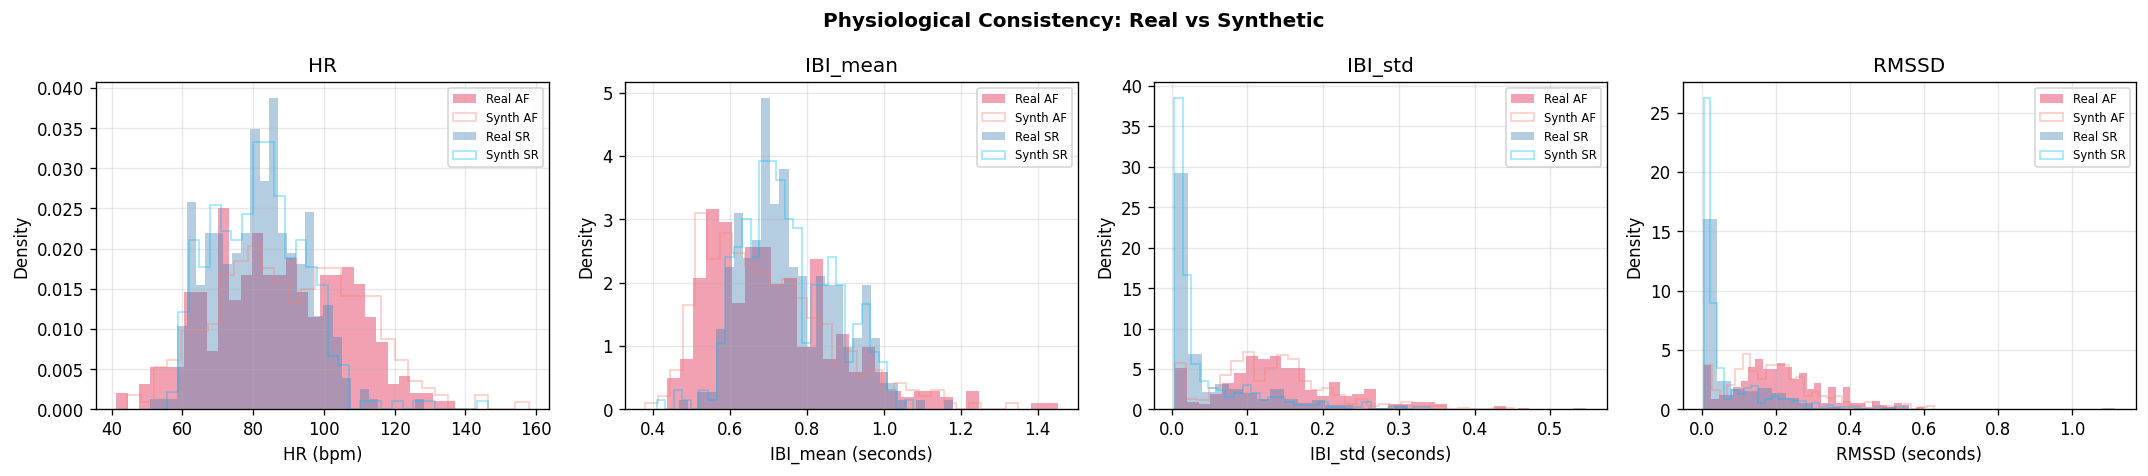

In [18]:
def ppg_hr(sig, fs=FS):
    """Estimate HR from PPG peak detection."""
    try:
        peaks, _ = find_peaks(sig, distance=int(fs*0.3), height=0.05)
        if len(peaks) < 3: return np.nan, np.nan, np.nan, np.nan
        ibi = np.diff(peaks) / fs
        ibi = ibi[(ibi>=IBI_MIN) & (ibi<=IBI_MAX)]
        if len(ibi) < 2: return np.nan, np.nan, np.nan, np.nan
        rmssd = np.sqrt(np.mean(np.diff(ibi)**2)) if len(ibi) > 1 else np.nan 
        return 60./np.mean(ibi), np.mean(ibi), np.std(ibi), rmssd
    except:
        return np.nan, np.nan, np.nan, np.nan

print("Computing physiological features from PPG peaks...")
metrics = {}
for rh in ['AF', 'SR']:
    for kind, arr in [('real', eval_real[rh]), ('synth', eval_synth[rh])]:
        hrs, ibim, ibis, rms = [], [], [], []
        for sig in arr:
            h, m, s, r = ppg_hr(sig)
            if not np.isnan(h):
                hrs.append(h); ibim.append(m); ibis.append(s); rms.append(r)
        metrics[f'{rh}_{kind}'] = {'HR': hrs, 'IBI_mean': ibim, 'IBI_std': ibis, 'RMSSD': rms}

# --- PRINT DAS MÉTRICAS ---
print(f"\n{'Metric':<12}  {'Real AF':>10}  {'Synth AF':>10}  {'Real SR':>10}  {'Synth SR':>10}")
print("─" * 58)

# Corrigido: 'RMSSD' em vez de 'RMSDD'
for feat in ['HR', 'IBI_mean', 'IBI_std', 'RMSSD']:
    vals = []
    for key in ['AF_real', 'AF_synth', 'SR_real', 'SR_synth']:
        v = metrics[key][feat]
        vals.append(f"{np.mean(v):.3f}±{np.std(v):.3f}" if v else "N/A")
    # Corrigido: removido o {vals[4]} que causava o IndexError
    print(f"  {feat:<10}  {vals[0]:>10}  {vals[1]:>10}  {vals[2]:>10}  {vals[3]:>10}")

# --- HISTOGRAMAS ---
# Corrigido: subplots(1, 4) para 4 gráficos numa só linha
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# Corrigido: 'RMSSD' na lista de features
for ax, feat, unit in zip(axes,
    ['HR', 'IBI_mean', 'IBI_std', 'RMSSD'],
    ['bpm', 'seconds', 'seconds', 'seconds']):
    
    for rh, cr, cs in [('AF', 'crimson', 'salmon'), ('SR', 'steelblue', 'deepskyblue')]:
        r_vals = metrics[f'{rh}_real'][feat]
        s_vals = metrics[f'{rh}_synth'][feat]
        if r_vals:
            ax.hist(r_vals, bins=30, alpha=0.4, color=cr, density=True, label=f'Real {rh}')
        if s_vals:
            ax.hist(s_vals, bins=30, alpha=0.4, color=cs, density=True,
                    label=f'Synth {rh}', histtype='step', lw=2)
            
    ax.set_xlabel(f'{feat} ({unit})')
    ax.set_ylabel('Density')
    ax.set_title(feat)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle('Physiological Consistency: Real vs Synthetic', fontweight='bold')
plt.tight_layout()
plt.show()

## §10 — Statistical Validation and other tests

This section includes the following statistical evaluation tests and analysis cells:

* **Wasserstein Distance**
* **Maximum Mean Discrepancy (MMD)**
* **Dynamic Time Warping (DTW)**
* **t-SNE**
* **Nearest-Neighbour Morphological Similarity** (PRD + Pearson)
* **Paired PRD / Pearson** (Conditioning-Vector-Paired)
* **Conditioning Fidelity:** HR MAE and IBI_std Ratio
* **Conditioning Fidelity:** Paired
* **Paired t-Test**

In [19]:
def feature_vec(signals):
    feats = []
    for sig in signals:
        try:
            peaks, _ = find_peaks(sig, distance=int(FS*0.3), height=0.1)
            hr_v  = [FS*60/d for d in np.diff(peaks) if 30 < FS*60/d < 200]
            hr_m  = np.mean(hr_v) if hr_v else 75.
            hr_s  = np.std(hr_v)  if len(hr_v)>1 else 0.
        except:
            hr_m, hr_s = 75., 0.
        freq, pxx = welch(sig, fs=FS, nperseg=256)
        p_lo  = np.trapezoid(pxx[(freq>=0)&(freq<4)],  freq[(freq>=0)&(freq<4)])
        p_hi  = np.trapezoid(pxx[(freq>=4)&(freq<8)],  freq[(freq>=4)&(freq<8)])
        feats.append([hr_m, hr_s, p_lo, p_hi, np.sqrt(np.mean(sig**2))])
    return np.array(feats)

N_TSNE = min(200, len(eval_real['AF']), len(eval_real['SR']))
feat_keys = ['real_AF','real_SR','synth_AF','synth_SR']
feats = {k: feature_vec(v[:N_TSNE]) for k,v in {
    'real_AF':  eval_real['AF'],  'real_SR':  eval_real['SR'],
    'synth_AF': eval_synth['AF'], 'synth_SR': eval_synth['SR']}.items()}

# Wasserstein distances
feat_names = ['HR_mean','HR_std','Power_0-4Hz','Power_4-8Hz','RMS']
print("Wasserstein distance (real vs synthetic):")
print(f"{'Feature':<15}  {'AF':>10}  {'SR':>10}")
print("─" * 40)
for i, fn in enumerate(feat_names):
    wa = wasserstein_distance(feats['real_AF'][:,i], feats['synth_AF'][:,i])
    ws = wasserstein_distance(feats['real_SR'][:,i], feats['synth_SR'][:,i])
    print(f"  {fn:<13}  {wa:>10.4f}  {ws:>10.4f}")


Wasserstein distance (real vs synthetic):
Feature                  AF          SR
────────────────────────────────────────
  HR_mean            3.2242      1.0021
  HR_std             1.0126      0.6485
  Power_0-4Hz        0.0253      0.0376
  Power_4-8Hz        0.0006      0.0003
  RMS                0.0239      0.0407


In [20]:
from scipy.spatial.distance import pdist

def mmd_rbf(X, Y, gamma=None):
    """Maximum Mean Discrepancy (kernel RBF, estimador não-enviesado).
    gamma=None usa a heurística da mediana das distâncias par-a-par
    (combinando X e Y) para escolher a largura de banda do kernel.
    Menor MMD² = distribuições conjuntas mais parecidas.
    """
    X = np.atleast_2d(X); Y = np.atleast_2d(Y)
    if gamma is None:
        Z = np.vstack([X, Y])
        d2 = pdist(Z, 'sqeuclidean')
        med = np.median(d2)
        gamma = 1.0 / (med + 1e-8)

    def rbf(A, B):
        d2 = np.sum(A**2, 1)[:, None] + np.sum(B**2, 1)[None, :] - 2 * A @ B.T
        return np.exp(-gamma * np.clip(d2, 0, None))

    Kxx, Kyy, Kxy = rbf(X, X), rbf(Y, Y), rbf(X, Y)
    m, n = len(X), len(Y)
    sum_xx = (Kxx.sum() - np.trace(Kxx)) / (m * (m - 1))
    sum_yy = (Kyy.sum() - np.trace(Kyy)) / (n * (n - 1))
    sum_xy = Kxy.sum() / (m * n)
    return float(sum_xx + sum_yy - 2 * sum_xy)


print("MMD² (features padronizadas, kernel RBF, menor = mais parecido):")
print(f"{'Classe':<10}  {'MMD²':>10}")
print("─" * 24)
sc_all = StandardScaler().fit(np.vstack([feats['real_AF'], feats['real_SR']]))
mmd_af = mmd_rbf(sc_all.transform(feats['real_AF']), sc_all.transform(feats['synth_AF']))
mmd_sr = mmd_rbf(sc_all.transform(feats['real_SR']), sc_all.transform(feats['synth_SR']))
print(f"  {'AF':<8}  {mmd_af:>10.5f}")
print(f"  {'SR':<8}  {mmd_sr:>10.5f}")


MMD² (features padronizadas, kernel RBF, menor = mais parecido):
Classe            MMD²
────────────────────────
  AF           0.01719
  SR           0.05271


In [21]:
DOWN_FACTOR = 5     # 1250 -> 250 amostras (FS efetiva ~25 Hz, > 2x8 Hz do passband)
DTW_BAND    = 25    # banda de Sakoe-Chiba, em amostras (após downsampling)
N_DTW       = 30    # amostras por classe — DTW é caro, mantido pequeno


def dtw_distance(a, b, band):
    """DTW com banda de Sakoe-Chiba (para tratabilidade). Distância elementar
    = |a_i - b_j|. Implementação simples em numpy/Python puro - sem
    dependências novas."""
    n, m = len(a), len(b)
    D = np.full((n + 1, m + 1), np.inf)
    D[0, 0] = 0.0
    for i in range(1, n + 1):
        j_lo = max(1, i - band)
        j_hi = min(m, i + band)
        for j in range(j_lo, j_hi + 1):
            cost = abs(a[i-1] - b[j-1])
            D[i, j] = cost + min(D[i-1, j], D[i, j-1], D[i-1, j-1])
    return D[n, m]


def dtw_nn_summary(real_sigs, synth_sigs, n=N_DTW, down=DOWN_FACTOR, band=DTW_BAND, seed=SEED):
    """Distância DTW do vizinho-mais-próximo (downsampled + banded).
    fidelidade = média, por sintético, da menor distância a um real
      (sintético -> real: os sinais gerados parecem-se com algum sinal real?)
    cobertura  = média, por real, da menor distância a um sintético
      (real -> sintético: os sinais reais estão bem representados no sintético?)
    """
    rng = np.random.RandomState(seed)
    idx_r = rng.choice(len(real_sigs),  min(n, len(real_sigs)),  replace=False)
    idx_s = rng.choice(len(synth_sigs), min(n, len(synth_sigs)), replace=False)
    R = [real_sigs[i][::down]  for i in idx_r]
    S = [synth_sigs[i][::down] for i in idx_s]

    D = np.zeros((len(S), len(R)))
    for i, s in enumerate(S):
        for j, r in enumerate(R):
            D[i, j] = dtw_distance(s, r, band)

    fidelity = float(D.min(axis=1).mean())
    coverage = float(D.min(axis=0).mean())
    return fidelity, coverage


print(f"DTW nearest-neighbour (N={N_DTW}/classe, downsample x{DOWN_FACTOR}, banda={DTW_BAND}):")
print(f"{'Classe':<10}  {'Fidelidade':>12}  {'Cobertura':>12}")
print("─" * 38)
fid_af, cov_af = dtw_nn_summary(eval_real['AF'], eval_synth['AF'])
fid_sr, cov_sr = dtw_nn_summary(eval_real['SR'], eval_synth['SR'])
print(f"  {'AF':<8}  {fid_af:>12.3f}  {cov_af:>12.3f}")
print(f"  {'SR':<8}  {fid_sr:>12.3f}  {cov_sr:>12.3f}")
print("\n(menor = mais parecido; fidelidade baixa e cobertura baixa juntas são o ideal)")


DTW nearest-neighbour (N=30/classe, downsample x5, banda=25):
Classe        Fidelidade     Cobertura
──────────────────────────────────────
  AF              30.214        32.323
  SR              24.540        24.575

(menor = mais parecido; fidelidade baixa e cobertura baixa juntas são o ideal)


In [22]:
def dtw_nn_baseline(
    real_sigs, n=N_DTW, down=DOWN_FACTOR, band=DTW_BAND, seed=SEED
):
    """Calcula a baseline Real vs Real dividindo o dataset real em dois grupos disjuntos.

    Isto evita comparar um sinal consigo mesmo (distância 0).
    """
    rng = np.random.RandomState(seed)
    n_total = len(real_sigs)

    # Precisamos de 2 * n sinais reais únicos para fazer 2 grupos de tamanho n
    k = min(n, n_total // 2)
    indices = rng.choice(n_total, 2 * k, replace=False)

    idx_a = indices[:k]
    idx_b = indices[k:]

    real_A = [real_sigs[i] for i in idx_a]
    real_B = [real_sigs[i] for i in idx_b]

    # Reutiliza a sua função dtw_nn_summary entre os dois grupos reais
    fid_base, cov_base = dtw_nn_summary(
        real_A, real_B, n=k, down=down, band=band, seed=seed
    )

    # Como ambos são conjuntos reais da mesma distribuição,
    # a média entre fidelidade e cobertura é o valor de referência
    return (fid_base + cov_base) / 2



print(
    f"DTW nearest-neighbour (N={N_DTW}/classe, downsample x{DOWN_FACTOR},"
    f" banda={DTW_BAND}):"
)
print(
    f"{'Classe':<10}  {'Fidelidade':>12}  {'Cobertura':>12} "
    f" {'Baseline (Real vs Real)':>25}"
)
print("─" * 63)

# 1. Cálculos do Modelo (Sintético vs Real)
fid_af, cov_af = dtw_nn_summary(eval_real["AF"], eval_synth["AF"])
fid_sr, cov_sr = dtw_nn_summary(eval_real["SR"], eval_synth["SR"])

# 2. Cálculos da Baseline (Real vs Real)
base_af = dtw_nn_baseline(eval_real["AF"])
base_sr = dtw_nn_baseline(eval_real["SR"])

print(f"  {'AF':<8}  {fid_af:>12.3f}  {cov_af:>12.3f}  {base_af:>25.3f}")
print(f"  {'SR':<8}  {fid_sr:>12.3f}  {cov_sr:>12.3f}  {base_sr:>25.3f}")

print("\n(quanto mais próximo o modelo estiver da Baseline Real vs Real, melhor)")

DTW nearest-neighbour (N=30/classe, downsample x5, banda=25):
Classe        Fidelidade     Cobertura    Baseline (Real vs Real)
───────────────────────────────────────────────────────────────
  AF              30.214        32.323                     32.099
  SR              24.540        24.575                     25.219

(quanto mais próximo o modelo estiver da Baseline Real vs Real, melhor)



Computing t-SNE...


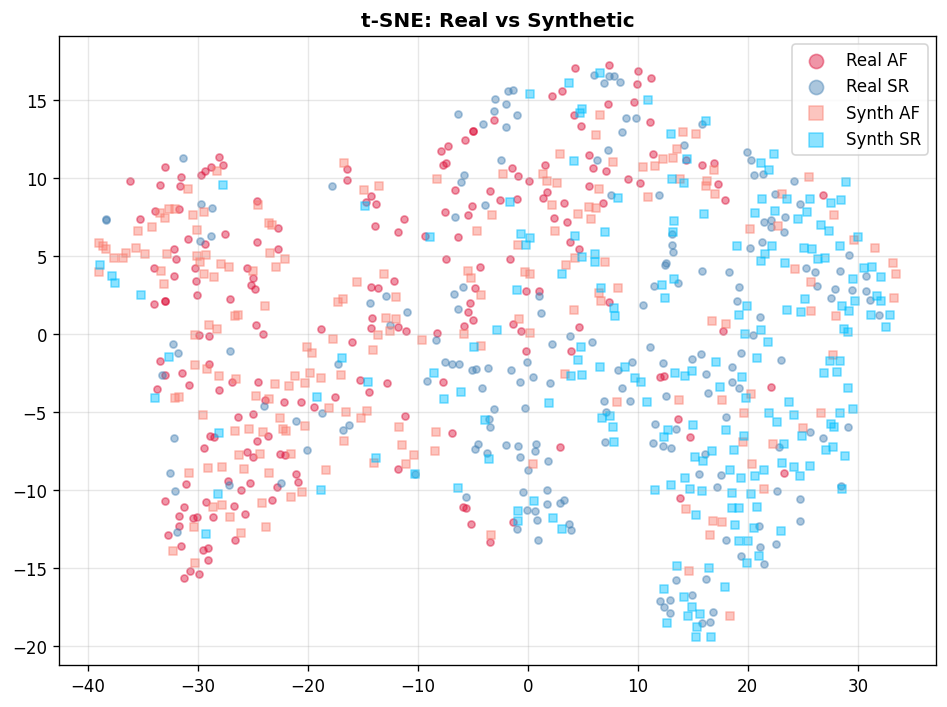

In [23]:
# t-SNE
all_f  = np.concatenate([feats[k] for k in feat_keys])
all_l  = [f'Real AF']*N_TSNE + [f'Real SR']*N_TSNE + [f'Synth AF']*N_TSNE + [f'Synth SR']*N_TSNE
sc     = StandardScaler().fit_transform(all_f)
print("\nComputing t-SNE...")
emb    = TSNE(n_components=2, perplexity=40, random_state=SEED, n_iter=1000).fit_transform(sc)

#colours = {'Real AF':'crimson','Real SR':'steelblue','Synth AF':'salmon','Synth SR':'deepskyblue'}
#markers = {'Real AF':'o','Real SR':'o','Synth AF':'s','Synth SR':'s'}
#fig, ax = plt.subplots(figsize=(8, 6))
#for lbl in feat_keys:
#    lbl2 = lbl.replace('_',' ').title()
#    mask = [l == lbl2 for l in all_l]
#    ax.scatter(emb[mask,0], emb[mask,1], c=colours[lbl2], marker=markers[lbl2],
#               alpha=0.45, s=18, label=lbl2)
#ax.set_title('t-SNE: Real vs Synthetic', fontweight='bold')
#ax.legend(markerscale=2); ax.grid(alpha=0.3)
#plt.tight_layout(); plt.show()
# Manual label mapping — avoid .title() which corrupts 'AF' → 'Af'

label_map = {
    'real_AF': 'Real AF',   'real_SR': 'Real SR',
    'synth_AF': 'Synth AF', 'synth_SR': 'Synth SR'
}
colours = {'Real AF':'crimson','Real SR':'steelblue',
           'Synth AF':'salmon','Synth SR':'deepskyblue'}
markers = {'Real AF':'o','Real SR':'o','Synth AF':'s','Synth SR':'s'}

fig, ax = plt.subplots(figsize=(8, 6))
for key in ['real_AF','real_SR','synth_AF','synth_SR']:
    lbl2 = label_map[key]
    mask = [l == lbl2 for l in all_l]
    ax.scatter(emb[mask,0], emb[mask,1], c=colours[lbl2],
               marker=markers[lbl2], alpha=0.45, s=18, label=lbl2)
ax.set_title('t-SNE: Real vs Synthetic', fontweight='bold')
ax.legend(markerscale=2); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## §10b — Nearest-Neighbour Morphological Similarity (PRD + Pearson)

Nearest-neighbour PRD and Pearson between generated signals and real signals.  
**Critical context:** these metrics were designed for *reconstruction* tasks (where a  
ground-truth reference pair exists). For generative models sampling from noise there  
is no defined pair — the nearest real neighbour is the closest available proxy.  

To contextualise: the **real-vs-real baseline** computes the same metrics between  
disjoint sets of real signals from different patients. If synth-vs-real ≈ real-vs-real,  
the generator produces signals with morphological diversity consistent with the real  
inter-patient variability — which is the correct interpretation.  

Followed by **conditioning fidelity**: MAE between the HR encoded in the conditioning  
vector and the HR estimated from the generated signal, and IBI\_std ratio (synthetic  
vs real), measuring whether the model honoured its explicit conditioning targets.

In [24]:
from sklearn.metrics import pairwise_distances

# ── Helper functions ──────────────────────────────────────────────────────────
def prd_signal(real, synth):
    """Percent Root-mean-square Difference (%). Designed for reconstruction tasks."""    
    num = np.sum((real - synth) ** 2)
    den = np.sum(real ** 2)
    return 100.0 * np.sqrt(num / (den + 1e-10))


def nn_metrics(real_sigs, synth_sigs, n=200, seed=SEED):
    """
    Synth-vs-Real: for each synthetic, find its nearest real (L2) and compute
    PRD and Pearson on that pair. Returns (prd_mean, prd_std, pcc_mean, pcc_std).
    """
    rng   = np.random.default_rng(seed)
    idx_r = rng.choice(len(real_sigs),  min(n, len(real_sigs)),  replace=False)
    idx_s = rng.choice(len(synth_sigs), min(n, len(synth_sigs)), replace=False)
    R, S  = real_sigs[idx_r], synth_sigs[idx_s]
    D     = pairwise_distances(S, R, metric='euclidean')
    nn_i  = D.argmin(axis=1)
    prds, pccs = [], []
    for i, j in enumerate(nn_i):
        prds.append(prd_signal(R[j], S[i]))
        r = np.corrcoef(R[j], S[i])[0, 1]
        if not np.isnan(r): pccs.append(r)
    return float(np.mean(prds)), float(np.std(prds)), float(np.mean(pccs)), float(np.std(pccs))


def nn_metrics_real_vs_real(real_sigs, n=200, seed=SEED+1):
    """
    Real-vs-Real baseline: same computation between two disjoint subsets of real
    signals. This is the morphological floor — how different two real signals from
    different patients are. If synth-vs-real ≈ real-vs-real, the generator produces
    diversity consistent with inter-patient variability.
    """
    rng   = np.random.default_rng(seed)
    n_use = min(n * 2, len(real_sigs))
    idx   = rng.choice(len(real_sigs), n_use, replace=False)
    n_h   = n_use // 2
    R1, R2 = real_sigs[idx[:n_h]], real_sigs[idx[n_h:2*n_h]]
    D      = pairwise_distances(R1, R2, metric='euclidean')
    nn_i   = D.argmin(axis=1)
    prds, pccs = [], []
    for i, j in enumerate(nn_i):
        prds.append(prd_signal(R2[j], R1[i]))
        r = np.corrcoef(R2[j], R1[i])[0, 1]
        if not np.isnan(r): pccs.append(r)
    return float(np.mean(prds)), float(np.std(prds)), float(np.mean(pccs)), float(np.std(pccs))


# ── Compute all metrics ───────────────────────────────────────────────────────
print("Computing nearest-neighbour PRD and Pearson (n=200 per class)...")
print("This may take ~1–2 min (pairwise L2 over 200×200 matrices).")

nn_res = {}
for rh in ['AF', 'SR']:
    pm, ps, cm, cs   = nn_metrics(eval_real[rh], eval_synth[rh])
    rpm, rps, rcm, rcs = nn_metrics_real_vs_real(eval_real[rh])
    nn_res[rh] = dict(prd_sv=(pm, ps), pcc_sv=(cm, cs),
                      prd_rr=(rpm, rps), pcc_rr=(rcm, rcs))
    print(f'  {rh} done')

# ── Results table ─────────────────────────────────────────────────────────────
print()
print('=' * 80)
print('  §10b — Nearest-Neighbour Morphological Metrics')
print('=' * 80)
print(f"  {'Metric':<30}  {'AF (Synth→Real NN)':>20}  {'AF (Real→Real)':>16}")
print('  ' + '─' * 72)
for rh, label_s, label_r in [
        ('AF', 'Synth→Real NN', 'Real→Real baseline'),
        ('SR', 'Synth→Real NN', 'Real→Real baseline')]:
    r = nn_res[rh]
    pm, ps   = r['prd_sv'];  cm, cs   = r['pcc_sv']
    rpm, rps = r['prd_rr'];  rcm, rcs = r['pcc_rr']
    print(f"  {'─'*72}")
    print(f"  Class: {rh}")
    print(f"  {'PRD (%)':<28}  {pm:>8.2f}±{ps:>6.2f}   (NN)  "
          f"  {rpm:>8.2f}±{rps:>6.2f} (Real↔Real)")
    print(f"  {'Pearson':<28}  {cm:>8.4f}±{cs:>6.4f}   (NN)  "
          f"  {rcm:>8.4f}±{rcs:>6.4f} (Real↔Real)")
print('=' * 80)
print()
print('Interpretation:')
print('  PRD > 100% and low Pearson are EXPECTED for generation (vs reconstruction).')
print('  Key question: are Synth→Real values comparable to Real→Real baseline?')
for rh in ['AF', 'SR']:
    r = nn_res[rh]
    delta_prd = r['prd_sv'][0] - r['prd_rr'][0]
    delta_pcc = r['pcc_sv'][0] - r['pcc_rr'][0]
    print(f'  {rh}: PRD overhead = {delta_prd:+.2f}%  |  '
          f'Pearson gap = {delta_pcc:+.4f}')
print()
print('Overhead close to zero → synthetics indistinguishable from')
print('inter-patient real variability in morphological terms.')

Computing nearest-neighbour PRD and Pearson (n=200 per class)...
This may take ~1–2 min (pairwise L2 over 200×200 matrices).
  AF done
  SR done

  §10b — Nearest-Neighbour Morphological Metrics
  Metric                            AF (Synth→Real NN)    AF (Real→Real)
  ────────────────────────────────────────────────────────────────────────
  ────────────────────────────────────────────────────────────────────────
  Class: AF
  PRD (%)                         113.58± 29.91   (NN)      108.85± 23.89 (Real↔Real)
  Pearson                         0.3952±0.1642   (NN)      0.3919±0.1747 (Real↔Real)
  ────────────────────────────────────────────────────────────────────────
  Class: SR
  PRD (%)                          68.69± 20.28   (NN)       75.01± 27.93 (Real↔Real)
  Pearson                         0.7599±0.1537   (NN)      0.7115±0.1887 (Real↔Real)

Interpretation:
  PRD > 100% and low Pearson are EXPECTED for generation (vs reconstruction).
  Key question: are Synth→Real values compar

# 10b-v2 — Paired PRD/Pearson (conditioning-vector-paired)
Versão mais rigorosa de §10b:
   Paired:   synthetic_i gerado do conditioning de real_i → PRD/Pearson(synth_i, real_i)
   Baseline: para cada real_i, encontra real_j com conditioning mais próximo (j≠i)
             → PRD/Pearson(real_i, real_j)
O baseline controla a similaridade de condicionamento — isola a variação
morfológica natural entre doentes com HRV semelhante.
Requires: prd_signal (§10b), load_ppg (§4), ema_model, norm_ibi, build_cond,
           heun_sample, ODE_STEPS, BEST_GS, df_test, SEED, DEVICE

In [25]:
# ── §10b-v2 — Paired PRD/Pearson (conditioning-vector-paired) ────────────────
# Versão mais rigorosa de §10b:
#   Paired:   synthetic_i gerado do conditioning de real_i → PRD/Pearson(synth_i, real_i)
#   Baseline: para cada real_i, encontra real_j com conditioning mais próximo (j≠i)
#             → PRD/Pearson(real_i, real_j)
# O baseline controla a similaridade de condicionamento — isola a variação
# morfológica natural entre doentes com HRV semelhante.
#
# Requires: prd_signal (§10b), load_ppg (§4), ema_model, norm_ibi, build_cond,
#           heun_sample, ODE_STEPS, BEST_GS, df_test, SEED, DEVICE

from sklearn.preprocessing import StandardScaler as _SS

# Redefinir prd_signal se §10b não tiver corrido
if 'prd_signal' not in dir():
    def prd_signal(real, synth):
        num = np.sum((real - synth) ** 2)
        den = np.sum(real ** 2)
        return 100.0 * np.sqrt(num / (den + 1e-10))

N_PAIRED = 200   # pares por classe

print('§10b-v2 — Paired PRD/Pearson (conditioning-vector-paired)')
print(f'N = {N_PAIRED} pares por classe\n')

paired_res = {}

for rh in ['AF', 'SR']:
    # ── 1. Amostrar N linhas de df_test ──────────────────────────────────────
    df_rh = (df_test[df_test['event_rhythm'] == rh]
             .sample(min(N_PAIRED * 2, len(df_test[df_test['event_rhythm'] == rh])),
                     random_state=SEED)
             .reset_index(drop=True))

    # ── 2. Carregar sinais reais linha a linha (garante alinhamento) ──────────
    reals, valid_idx = [], []
    for i, row in df_rh.iterrows():
        try:
            sig = load_ppg(row['wfdb_path'], int(row['sub_win']))
            if sig is not None and len(sig) == WIN_LEN:
                reals.append(sig)
                valid_idx.append(i)
                if len(reals) >= N_PAIRED:
                    break
        except:
            continue

    df_valid   = df_rh.loc[valid_idx].reset_index(drop=True)
    X_real_p   = np.array(reals, dtype=np.float32)   # (n, WIN_LEN)
    n_valid    = len(X_real_p)
    print(f'{rh}: {n_valid} sinais reais carregados')

    if n_valid < 10:
        print(f'  WARN: menos de 10 sinais válidos — saltar\n')
        continue

    # ── 3. Gerar sintéticos paired (um por linha de df_valid) ─────────────────
    torch.cuda.empty_cache()
    nm, ns, nr = norm_ibi(df_valid['IBI_mean'].values,
                          df_valid['IBI_std'].values,
                          df_valid['RMSSD'].values)
    cond_t = torch.tensor(build_cond(nm, ns, nr, rh),
                          dtype=torch.float32).to(DEVICE)
    chunks = []
    for i in range(0, len(cond_t), 64):
        chunks.append(
            heun_sample(ema_model, cond_t[i:i+64], ODE_STEPS, BEST_GS)
            .cpu().numpy().squeeze(1))
    X_synth_p = np.concatenate(chunks)    # (n, WIN_LEN) — alinhado com X_real_p
    torch.cuda.empty_cache()

    # ── 4. PRD/Pearson paired: synthetic_i vs real_i ──────────────────────────
    prds_p, pccs_p = [], []
    for i in range(n_valid):
        prds_p.append(prd_signal(X_real_p[i], X_synth_p[i]))
        r = np.corrcoef(X_real_p[i], X_synth_p[i])[0, 1]
        if not np.isnan(r):
            pccs_p.append(r)

    # ── 5. Baseline: nearest conditioning neighbor (real vs conditioning-matched real)
    # Para cada real_i, encontra real_j (j≠i) com conditioning mais próximo
    cond_raw    = df_valid[['IBI_mean', 'IBI_std', 'RMSSD']].values
    cond_scaled = _SS().fit_transform(cond_raw)
    D_cond      = pairwise_distances(cond_scaled, metric='euclidean')
    np.fill_diagonal(D_cond, np.inf)      # excluir self
    nn_cond_idx = D_cond.argmin(axis=1)  # índice do conditioning mais próximo

    prds_b, pccs_b, cond_dists = [], [], []
    for i in range(n_valid):
        j = nn_cond_idx[i]
        prds_b.append(prd_signal(X_real_p[i], X_real_p[j]))
        r = np.corrcoef(X_real_p[i], X_real_p[j])[0, 1]
        if not np.isnan(r):
            pccs_b.append(r)
        cond_dists.append(D_cond[i, j])   # distância de condicionamento do par

    paired_res[rh] = dict(
        prd_p  = (float(np.mean(prds_p)), float(np.std(prds_p))),
        pcc_p  = (float(np.mean(pccs_p)), float(np.std(pccs_p))),
        prd_b  = (float(np.mean(prds_b)), float(np.std(prds_b))),
        pcc_b  = (float(np.mean(pccs_b)), float(np.std(pccs_b))),
        cond_d = (float(np.mean(cond_dists)), float(np.std(cond_dists))),
        n      = n_valid,
    )
    
    paired_res[rh]['X_real']    = X_real_p
    paired_res[rh]['X_synth']   = X_synth_p
    paired_res[rh]['nn_cond_i'] = nn_cond_idx
    
    overhead_prd = float(np.mean(prds_p)) - float(np.mean(prds_b))
    overhead_pcc = float(np.mean(pccs_p)) - float(np.mean(pccs_b))
    print(f'  PRD  paired={np.mean(prds_p):.2f}%  baseline={np.mean(prds_b):.2f}%  '
          f'overhead={overhead_prd:+.2f}%')
    print(f'  PCC  paired={np.mean(pccs_p):.4f}   baseline={np.mean(pccs_b):.4f}   '
          f'gap={overhead_pcc:+.4f}')
    print(f'  Mean conditioning distance of baseline pairs: {np.mean(cond_dists):.4f}')
    print()

# ── Tabela de resultados ───────────────────────────────────────────────────────
print()
print('=' * 82)
print('  §10b-v2 — Paired PRD/Pearson (conditioning-vector-paired)')
print('=' * 82)
print(f"  {'Metric':<38}  {'AF':>18}  {'SR':>18}")
print('  ' + '─' * 78)
for rh in ['AF', 'SR']:
    if rh not in paired_res: continue
    r = paired_res[rh]
    print(f"  {'─'*78}")
    print(f"  Class {rh}  (n = {r['n']})")
    print(f"  {'PRD (%) — synth_i vs real_i':<38}  "
          f"{r['prd_p'][0]:>7.2f}±{r['prd_p'][1]:>6.2f}   "
          f"  {paired_res[rh]['prd_p'][0]:>7.2f}")
    print(f"  {'PRD (%) — real_i vs cond-NN real_j':<38}  "
          f"{r['prd_b'][0]:>7.2f}±{r['prd_b'][1]:>6.2f}   "
          f"  {'(baseline)':>7}")
    print(f"  {'PRD overhead (synth−baseline)':<38}  "
          f"{r['prd_p'][0]-r['prd_b'][0]:>+14.2f}%")
    print(f"  {'Pearson — synth_i vs real_i':<38}  "
          f"{r['pcc_p'][0]:>7.4f}±{r['pcc_p'][1]:>6.4f}   "
          f"  {paired_res[rh]['pcc_p'][0]:>7.4f}")
    print(f"  {'Pearson — real_i vs cond-NN real_j':<38}  "
          f"{r['pcc_b'][0]:>7.4f}±{r['pcc_b'][1]:>6.4f}   "
          f"  {'(baseline)':>7}")
    print(f"  {'Pearson gap (synth−baseline)':<38}  "
          f"{r['pcc_p'][0]-r['pcc_b'][0]:>+14.4f}")
print('=' * 82)

print()
print('Interpretation:')
print('  Baseline = real_i vs real_j with most similar conditioning vector.')
print('  Controls for conditioning similarity — isolates morphological variation')
print('  beyond what IBI_mean/IBI_std/RMSSD can predict.')
print()
print('  PRD overhead ≈ 0 → synthetic morphology is as close to real_i as')
print('  another real signal with the same HRV features would be.')
print('  PRD overhead >> 0 → generator introduces extra morphological variation')
print('  beyond what conditioning determines.')
print()
for rh in paired_res:
    r = paired_res[rh]
    print(f'  {rh}: PRD overhead = {r["prd_p"][0]-r["prd_b"][0]:+.2f}%  |  '
          f'Pearson gap = {r["pcc_p"][0]-r["pcc_b"][0]:+.4f}  |  '
          f'mean cond-dist of baseline pairs = {r["cond_d"][0]:.4f}')

# ── Comparação com §10b (NN em espaço de sinal) ───────────────────────────────
if 'nn_res' in dir():
    print()
    print('─' * 82)
    print('  Comparação §10b (NN sinal-espaço) vs §10b-v2 (conditioning-paired)')
    print('─' * 82)
    print(f"  {'Métrica':<40}  {'AF':>18}  {'SR':>18}")
    for rh in ['AF', 'SR']:
        if rh not in paired_res or rh not in nn_res: continue
        r_nn = nn_res[rh]; r_p = paired_res[rh]
        print(f"  {rh} PRD §10b  (synth→NN real)          "
              f"  {r_nn['prd_sv'][0]:>8.2f}%")
        print(f"  {rh} PRD §10b-v2 (synth→conditioning real)  "
              f"  {r_p['prd_p'][0]:>8.2f}%")
    print('─' * 82)

§10b-v2 — Paired PRD/Pearson (conditioning-vector-paired)
N = 200 pares por classe

AF: 200 sinais reais carregados
  PRD  paired=133.42%  baseline=133.02%  overhead=+0.40%
  PCC  paired=0.0203   baseline=-0.0064   gap=+0.0267
  Mean conditioning distance of baseline pairs: 0.2544

SR: 200 sinais reais carregados
  PRD  paired=135.05%  baseline=136.32%  overhead=-1.27%
  PCC  paired=0.0342   baseline=-0.0455   gap=+0.0797
  Mean conditioning distance of baseline pairs: 0.1910


  §10b-v2 — Paired PRD/Pearson (conditioning-vector-paired)
  Metric                                                  AF                  SR
  ──────────────────────────────────────────────────────────────────────────────
  ──────────────────────────────────────────────────────────────────────────────
  Class AF  (n = 200)
  PRD (%) — synth_i vs real_i              133.42± 31.00      133.42
  PRD (%) — real_i vs cond-NN real_j       133.02± 25.81     (baseline)
  PRD overhead (synth−baseline)                    

# 10b-v3 — Conditioning- matched paires local density check

In [26]:
# ── §10b-v3 — Densidade local dos pares conditioning-matched ─────────────────
from sklearn.metrics import pairwise_distances as _pwd

print('§10b-v3 — Local density verification of conditioning-matched pairs')
print('Confirms pairs lie in dense regions (not isolated outliers)\n')

for rh in ['AF', 'SR']:
    if rh not in paired_res or 'X_real' not in paired_res[rh]:
        print(f'{rh}: dados não encontrados — correr §10b-v2 primeiro')
        continue

    X_real_p   = paired_res[rh]['X_real']
    X_synth_p  = paired_res[rh]['X_synth']
    nn_cond_i  = paired_res[rh]['nn_cond_i']
    n          = paired_res[rh]['n']

    # Matriz de distâncias de sinal entre todos os reais
    D_sig = _pwd(X_real_p, metric='euclidean')
    np.fill_diagonal(D_sig, np.inf)

    # Raio = percentil 25 de todas as distâncias (define "zona densa")
    r25 = np.percentile(D_sig[D_sig < np.inf], 25)

    # Para cada real_i: quantos reais estão dentro do raio r25?
    k_real = [(D_sig[i] < r25).sum() for i in range(n)]

    # Para cada par baseline (real_i, real_j): distância de sinal
    dist_baseline_signal = [D_sig[i, nn_cond_i[i]] for i in range(n)]

    # Para cada par paired (synth_i, real_i): distância de sinal
    dist_paired_signal = [
        float(np.linalg.norm(X_synth_p[i] - X_real_p[i])) for i in range(n)
    ]

    # Distâncias aleatórias (pares random real_i vs real_j, j≠i) como referência
    rng_d = np.random.default_rng(SEED)
    rand_j = [rng_d.choice([k for k in range(n) if k != i]) for i in range(n)]
    dist_random_signal = [D_sig[i, rand_j[i]] for i in range(n)]

    print(f'── Class {rh} (n={n}) ──────────────────────────────────────────────')
    print(f'  Signal-space distance (L2):')
    print(f'    synth_i vs real_i  (paired)    : '
          f'{np.mean(dist_paired_signal):>8.3f} ± {np.std(dist_paired_signal):.3f}')
    print(f'    real_i vs cond-NN real_j (base): '
          f'{np.mean(dist_baseline_signal):>8.3f} ± {np.std(dist_baseline_signal):.3f}')
    print(f'    real_i vs random real_j         : '
          f'{np.mean(dist_random_signal):>8.3f} ± {np.std(dist_random_signal):.3f}')
    print(f'  Local density (neighbours within r25={r25:.2f}):')
    print(f'    Mean neighbours per real_i      : {np.mean(k_real):.1f}')
    print(f'    Min / Max                       : {min(k_real)} / {max(k_real)}')
    frac_isolated = sum(1 for k in k_real if k == 0) / n
    print(f'    Fraction isolated (0 neighbours): {frac_isolated:.1%}')
    print()

print('Interpretation:')
print('  dist(synth_i, real_i) < dist(random real pair)')
print('  → conditioning-paired synthetics are closer to their target than chance.')
print()
print('  dist(cond-NN baseline) < dist(random real pair)')
print('  → conditioning vector has predictive power over signal morphology.')
print()
print('  fraction isolated ≈ 0 → pairs are in dense regions, baseline is reliable.')
print('  fraction isolated >> 0 → some reals are outliers; baseline PRD for those')
print('  pairs is inflated and should be interpreted with caution.')

§10b-v3 — Local density verification of conditioning-matched pairs
Confirms pairs lie in dense regions (not isolated outliers)

── Class AF (n=200) ──────────────────────────────────────────────
  Signal-space distance (L2):
    synth_i vs real_i  (paired)    :   23.636 ± 5.092
    real_i vs cond-NN real_j (base):   23.547 ± 3.883
    real_i vs random real_j         :   23.922 ± 2.629
  Local density (neighbours within r25=22.05):
    Mean neighbours per real_i      : 49.8
    Min / Max                       : 2 / 166
    Fraction isolated (0 neighbours): 0.0%

── Class SR (n=200) ──────────────────────────────────────────────
  Signal-space distance (L2):
    synth_i vs real_i  (paired)    :   25.680 ± 8.359
    real_i vs cond-NN real_j (base):   26.106 ± 7.655
    real_i vs random real_j         :   26.454 ± 2.891
  Local density (neighbours within r25=24.48):
    Mean neighbours per real_i      : 49.8
    Min / Max                       : 3 / 159
    Fraction isolated (0 neighbours)

# 10c — Conditioning Fidelity: HR MAE and IBI_std Ratio
Measures whether the model honoured explicit conditioning targets.
Unique to conditionally-trained models — not available in unconditional GANs/VAEs.
HR MAE:     |HR_synthetic - HR_target| where HR_target = 60 / IBI_mean (conditioning)
IBI_std ratio: IBI_std_synthetic / IBI_std_real  (ideally 1.0 — no over/under-dispersion)

In [27]:
# ── §10c — Conditioning Fidelity: HR MAE and IBI_std Ratio ───────────────────
# Measures whether the model honoured explicit conditioning targets.
# Unique to conditionally-trained models — not available in unconditional GANs/VAEs.
#
# HR MAE:     |HR_synthetic - HR_target| where HR_target = 60 / IBI_mean (conditioning)
# IBI_std ratio: IBI_std_synthetic / IBI_std_real  (ideally 1.0 — no over/under-dispersion)
from scipy.signal import find_peaks as _find_peaks

def _extract_hr_ibi(signals, fs=FS):
    """Estimate HR (bpm) and IBI_std from PPG peaks for each signal."""    
    hrs, ibi_stds = [], []
    for sig in signals:
        try:
            peaks, _ = _find_peaks(sig, distance=int(fs * 0.3), height=0.05)
            ibi = np.diff(peaks) / fs
            ibi = ibi[(ibi >= IBI_MIN) & (ibi <= IBI_MAX)]
            if len(ibi) >= 2:
                hrs.append(60.0 / ibi.mean())
                ibi_stds.append(float(ibi.std()))
        except:
            pass
    return np.array(hrs), np.array(ibi_stds)


print("Computing conditioning fidelity metrics (HR MAE, IBI_std ratio)...\n")

cond_res = {}
for rh in ['AF', 'SR']:
    # Conditioning targets from the test split (same subjects used for eval_synth in §8)
    df_rh      = df_test[df_test['event_rhythm'] == rh].sample(
        min(N_EVAL, len(df_test[df_test['event_rhythm'] == rh])),
        random_state=SEED)
    hr_target  = 60.0 / df_rh['IBI_mean'].values          # bpm — from conditioning vector
    ibi_std_tgt = df_rh['IBI_std'].values                  # s   — from conditioning vector

    hrs_synth, ibi_stds_synth = _extract_hr_ibi(eval_synth[rh])
    hrs_real,  ibi_stds_real  = _extract_hr_ibi(eval_real[rh])

    # MAE: |estimated HR from generated signal - conditioning target|
    n_mae = min(len(hrs_synth), len(hr_target))
    mae_hr = float(np.mean(np.abs(hrs_synth[:n_mae] - hr_target[:n_mae])))

    # IBI_std ratio (synthetics / real, ideally ~1.0)
    ibi_ratio = (ibi_stds_synth.mean() / ibi_stds_real.mean()
                 if len(ibi_stds_real) > 0 and ibi_stds_real.mean() > 0
                 else float('nan'))

    cond_res[rh] = {
        'hr_target':   hr_target.mean(),
        'hr_synth':    hrs_synth.mean()    if len(hrs_synth) > 0    else float('nan'),
        'hr_real':     hrs_real.mean()     if len(hrs_real) > 0     else float('nan'),
        'mae_hr':      mae_hr,
        'ibi_std_syn': ibi_stds_synth.mean() if len(ibi_stds_synth) > 0 else float('nan'),
        'ibi_std_real': ibi_stds_real.mean() if len(ibi_stds_real) > 0  else float('nan'),
        'ibi_ratio':   ibi_ratio,
    }

# ── Print table ───────────────────────────────────────────────────────────────
print('=' * 68)
print('  §10c — Conditioning Fidelity (HR MAE, IBI_std ratio)')
print('=' * 68)
print(f"  {'Metric':<30}  {'AF':>16}  {'SR':>16}")
print('  ' + '─' * 64)
rows = [
    ('HR target  (bpm)',   'hr_target'),
    ('HR synthetic (bpm)', 'hr_synth'),
    ('HR real     (bpm)',  'hr_real'),
    ('MAE HR      (bpm)',  'mae_hr'),
    ('IBI_std synthetic',  'ibi_std_syn'),
    ('IBI_std real',       'ibi_std_real'),
    ('IBI_std ratio',      'ibi_ratio'),
]
for label, key in rows:
    af_v = cond_res['AF'][key]; sr_v = cond_res['SR'][key]
    print(f"  {label:<30}  {af_v:>16.4f}  {sr_v:>16.4f}")
print('=' * 68)
print()
print('MAE HR: average deviation between generated HR and the conditioning target.')
print('IBI_std ratio ~1.0 → generator reproduces the conditioned rhythm variability.')
print('IBI_std ratio >> 1 → over-dispersion; << 1 → under-dispersion.')
print()
for rh in ['AF', 'SR']:
    r = cond_res[rh]
    print(f'{rh}: HR target={r["hr_target"]:.1f} bpm  '
          f'synth={r["hr_synth"]:.1f} bpm  '
          f'MAE={r["mae_hr"]:.2f} bpm  '
          f'IBI_std ratio={r["ibi_ratio"]:.3f}')

Computing conditioning fidelity metrics (HR MAE, IBI_std ratio)...

  §10c — Conditioning Fidelity (HR MAE, IBI_std ratio)
  Metric                                        AF                SR
  ────────────────────────────────────────────────────────────────
  HR target  (bpm)                         94.5630           81.7613
  HR synthetic (bpm)                       90.6174           81.8759
  HR real     (bpm)                        87.7445           81.4880
  MAE HR      (bpm)                         5.5965            9.1691
  IBI_std synthetic                         0.1325            0.0468
  IBI_std real                              0.1468            0.0526
  IBI_std ratio                             0.9027            0.8889

MAE HR: average deviation between generated HR and the conditioning target.
IBI_std ratio ~1.0 → generator reproduces the conditioned rhythm variability.
IBI_std ratio >> 1 → over-dispersion; << 1 → under-dispersion.

AF: HR target=94.6 bpm  synth=90.6 bpm 

# 10c-v2 — Conditioning Fidelity (Paired)

§10c-v2 — Paired Conditioning Fidelity
Generating 300 fresh paired synthetics per class...
ODE steps = 100  |  GS = 2.0

  AF: 300 pares  |  detect OK: 300 (100.0%)  |  MAE HR = 5.34 bpm  |  IBI_std ratio = 1.232 (n=279, excl. IBI_std<0.01s)
  SR: 300 pares  |  detect OK: 300 (100.0%)  |  MAE HR = 0.89 bpm  |  IBI_std ratio = 1.120 (n=148, excl. IBI_std<0.01s)

  §10c-v2 — Paired Conditioning Fidelity
  Metric                                            AF              SR
  ────────────────────────────────────────────────────────────────────
  HR target           (bpm)                    94.5630         81.7613
  HR synthetic        (bpm)                    91.2107         81.1255
  MAE HR — paired     (bpm)                     5.3425          0.8939
  IBI_std target      (s)                       0.1115          0.0361
  IBI_std synthetic   (s)                       0.1303          0.0415
  IBI_std ratio (filtered)                      1.2321          1.1199
  Pearson HR tgt vs synth  

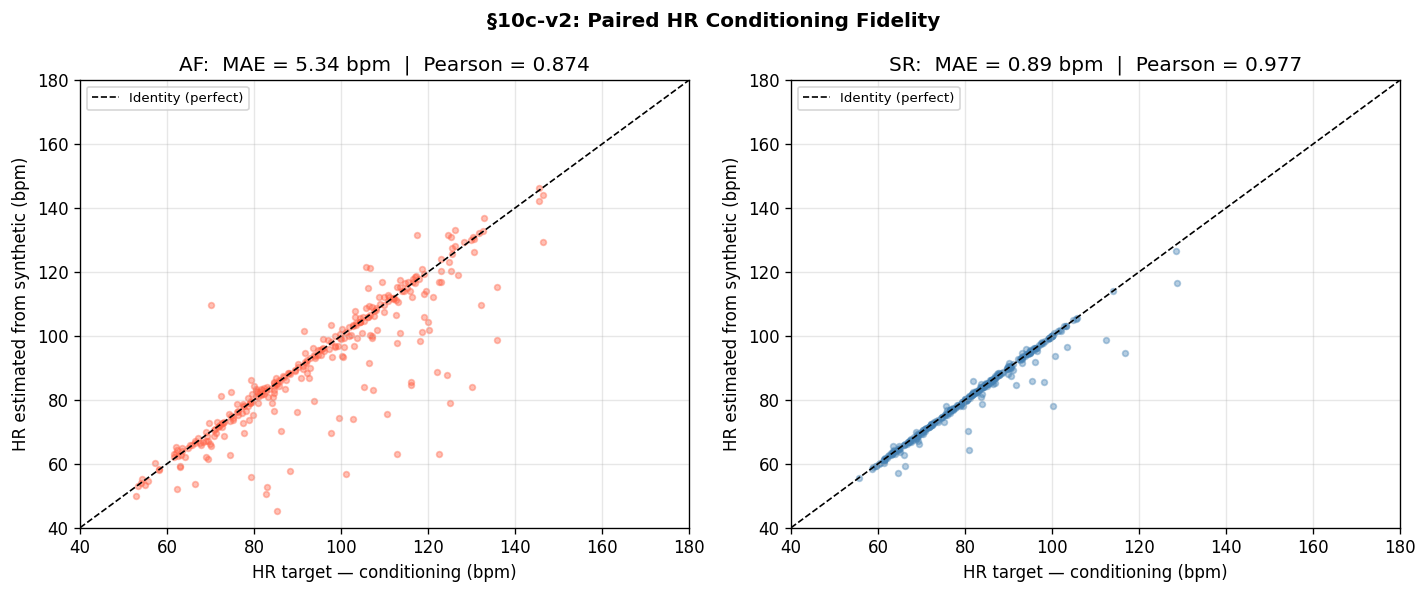


Pearson > 0.85 → o modelo acompanha o HR target por amostra.
Pontos abaixo da diagonal → subestimação sistemática de HR
(esperada em AF por pulse deficit; em SR reflecte ligeiro smoothing do IBI).


In [28]:
# ── §10c-v2 — Conditioning Fidelity (Paired) — corrected ─────────────────────
from scipy.signal import find_peaks as _find_peaks

N_COND_EVAL  = 300
MIN_IBI_STD  = 0.01   # s — exclui janelas SR com IBI_std ≈ 0 do ratio

def _est_hr_ibi(signals, fs=FS):
    hrs      = np.full(len(signals), np.nan)
    ibi_stds = np.full(len(signals), np.nan)
    for i, sig in enumerate(signals):
        try:
            peaks, _ = _find_peaks(sig, distance=int(fs * 0.3), height=0.05)
            ibi = np.diff(peaks) / fs
            ibi = ibi[(ibi >= IBI_MIN) & (ibi <= IBI_MAX)]
            if len(ibi) >= 2:
                hrs[i]      = 60.0 / ibi.mean()
                ibi_stds[i] = float(ibi.std())
        except:
            pass
    return hrs, ibi_stds


print('§10c-v2 — Paired Conditioning Fidelity')
print(f'Generating {N_COND_EVAL} fresh paired synthetics per class...')
print(f'ODE steps = {ODE_STEPS}  |  GS = {BEST_GS}\n')

cond_paired = {}

for rh in ['AF', 'SR']:
    df_rh = (df_test[df_test['event_rhythm'] == rh]
             .sample(min(N_COND_EVAL, len(df_test[df_test['event_rhythm'] == rh])),
                     random_state=SEED)
             .reset_index(drop=True))

    hr_tgt      = 60.0 / df_rh['IBI_mean'].values
    ibi_std_tgt = df_rh['IBI_std'].values
    n           = len(df_rh)

    nm, ns, nr = norm_ibi(df_rh['IBI_mean'].values,
                          df_rh['IBI_std'].values,
                          df_rh['RMSSD'].values)

    torch.cuda.empty_cache()
    cond_t = torch.tensor(build_cond(nm, ns, nr, rh),
                          dtype=torch.float32).to(DEVICE)
    chunks = []
    for i in range(0, len(cond_t), 64):
        chunks.append(
            heun_sample(ema_model, cond_t[i:i+64], ODE_STEPS, BEST_GS)
            .cpu().numpy().squeeze(1))
    synth_p = np.concatenate(chunks)

    hrs_s, ibi_stds_s = _est_hr_ibi(synth_p)
    valid = ~np.isnan(hrs_s)

    # MAE HR por par
    mae_hr   = float(np.nanmean(np.abs(hrs_s - hr_tgt)))
    mae_hr_s = float(np.nanstd (np.abs(hrs_s - hr_tgt)))

    # IBI_std ratio — exclui denominadores ≈ 0 (SR com ritmo perfeitamente regular)
    ratio_mask = (ibi_std_tgt >= MIN_IBI_STD) & ~np.isnan(ibi_stds_s)
    if ratio_mask.sum() >= 5:
        ratio    = ibi_stds_s[ratio_mask] / ibi_std_tgt[ratio_mask]
        ratio_m  = float(np.mean(ratio))
        ratio_s  = float(np.std(ratio))
        n_ratio  = int(ratio_mask.sum())
    else:
        ratio_m = ratio_s = float('nan'); n_ratio = 0

    # Pearson entre HR target e HR sintético (por amostra)
    valid_both = valid & (ibi_std_tgt > 0)
    pcc_hr = (float(np.corrcoef(hr_tgt[valid_both], hrs_s[valid_both])[0, 1])
              if valid_both.sum() >= 5 else float('nan'))

    cond_paired[rh] = dict(
        hr_tgt_mean  = hr_tgt.mean(),
        hr_syn_mean  = float(np.nanmean(hrs_s)),
        mae_hr       = mae_hr,
        mae_hr_std   = mae_hr_s,
        ibi_std_tgt  = ibi_std_tgt.mean(),
        ibi_std_syn  = float(np.nanmean(ibi_stds_s)),
        ratio_m      = ratio_m,
        ratio_s      = ratio_s,
        n_ratio      = n_ratio,
        pcc_hr       = pcc_hr,
        valid_pct    = 100 * valid.sum() / n,
        n            = n,
        hrs_s        = hrs_s,      # guardado para o scatter
        hr_tgt       = hr_tgt,
    )
    torch.cuda.empty_cache()
    print(f'  {rh}: {n} pares  |  '
          f'detect OK: {valid.sum()} ({100*valid.sum()/n:.1f}%)  |  '
          f'MAE HR = {mae_hr:.2f} bpm  |  '
          f'IBI_std ratio = {ratio_m:.3f} (n={n_ratio}, excl. IBI_std<{MIN_IBI_STD}s)')

# ── Tabela de resultados ───────────────────────────────────────────────────────
print()
print('=' * 72)
print('  §10c-v2 — Paired Conditioning Fidelity')
print('=' * 72)
print(f"  {'Metric':<36}  {'AF':>14}  {'SR':>14}")
print('  ' + '─' * 68)
rows = [
    ('HR target           (bpm)',  'hr_tgt_mean'),
    ('HR synthetic        (bpm)',  'hr_syn_mean'),
    ('MAE HR — paired     (bpm)',  'mae_hr'),
    ('IBI_std target      (s)',    'ibi_std_tgt'),
    ('IBI_std synthetic   (s)',    'ibi_std_syn'),
    ('IBI_std ratio (filtered)',   'ratio_m'),
    ('Pearson HR tgt vs synth',    'pcc_hr'),
    ('Peak detect success (%)',    'valid_pct'),
]
for label, key in rows:
    af_v = cond_paired['AF'][key]
    sr_v = cond_paired['SR'][key]
    print(f"  {label:<36}  {af_v:>14.4f}  {sr_v:>14.4f}")
print('=' * 72)
print(f"  Note SR IBI_std ratio: computed on windows with IBI_std ≥ {MIN_IBI_STD} s "
      f"(AF n={cond_paired['AF']['n_ratio']}, SR n={cond_paired['SR']['n_ratio']})")

# ── Comparação opcional com §10c não-emparelhado ─────────────────────────────
try:
    print()
    print('─' * 72)
    print('  Comparação: §10c (não-emparelhado) vs §10c-v2 (emparelhado)')
    print('─' * 72)
    print(f"  {'Métrica':<36}  {'AF':>14}  {'SR':>14}")
    print(f"  {'MAE HR §10c  (não-emparelhado)':<36}  "
          f"{cond_res['AF']['mae_hr']:>14.4f}  "
          f"{cond_res['SR']['mae_hr']:>14.4f}")
    print(f"  {'MAE HR §10c-v2 (emparelhado)':<36}  "
          f"{cond_paired['AF']['mae_hr']:>14.4f}  "
          f"{cond_paired['SR']['mae_hr']:>14.4f}")
    print(f"  {'IBI_std ratio §10c':<36}  "
          f"{results_cond['AF']['ibi_ratio']:>14.4f}  "
          f"{results_cond['SR']['ibi_ratio']:>14.4f}")
    print(f"  {'IBI_std ratio §10c-v2 (filtered)':<36}  "
          f"{cond_paired['AF']['ratio_m']:>14.4f}  "
          f"{cond_paired['SR']['ratio_m']:>14.4f}")
    print('─' * 72)
    print('MAE emparelhado < não-emparelhado → §10c estava inflacionado por misalignment.')
except NameError:
    print('\n(§10c não corrida nesta sessão — comparação omitida)')

# ── Scatter: HR target vs HR synthetic ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, rh in zip(axes, ['AF', 'SR']):
    r      = cond_paired[rh]
    hrs_s  = r['hrs_s']
    hr_tgt = r['hr_tgt']
    valid  = ~np.isnan(hrs_s)
    lims   = (40, 180)
    ax.scatter(hr_tgt[valid], hrs_s[valid],
               s=12, alpha=0.4, c='steelblue' if rh == 'SR' else 'tomato')
    ax.plot(lims, lims, 'k--', lw=1, label='Identity (perfect)')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('HR target — conditioning (bpm)')
    ax.set_ylabel('HR estimated from synthetic (bpm)')
    ax.set_title(f'{rh}:  MAE = {r["mae_hr"]:.2f} bpm  '
                 f'|  Pearson = {r["pcc_hr"]:.3f}')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle('§10c-v2: Paired HR Conditioning Fidelity',
             fontweight='bold')
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/fig_cond_fidelity_paired.png', dpi=150)
plt.show()
print()
print('Pearson > 0.85 → o modelo acompanha o HR target por amostra.')
print('Pontos abaixo da diagonal → subestimação sistemática de HR')
print('(esperada em AF por pulse deficit; em SR reflecte ligeiro smoothing do IBI).')

# 10c-v2 — t-paired Test similar to sohn article (ref [74] of the thises)

In [29]:
# ── §10c-v3 — Paired t-test on HR (Suh et al. 2023 protocol) ─────────────────
# Suh et al. compared beat-to-beat HR from the reference ECG vs HR from the
# generated PPG using a paired t-test (p=0.248, no significant difference) plus
# Pearson correlation (0.94±0.14). Here we replicate that test using the paired
# arrays already computed in §10c-v2:
#   - hr_tgt : HR implied by the conditioning vector (60 / IBI_mean)  ← "target"
#   - hrs_s  : HR measured from the generated signal via peak detection
# Requires cond_paired (from §10c-v2) with 'hr_tgt' and 'hrs_s' stored per class.
from scipy.stats import ttest_rel, pearsonr

if 'cond_paired' not in dir():
    raise RuntimeError("Run §10c-v2 first — cond_paired not found.")

print('§10c-v3 — Paired t-test: HR target vs HR synthetic (Suh et al. protocol)\n')

ttest_res = {}
for rh in ['AF', 'SR']:
    if rh not in cond_paired or 'hrs_s' not in cond_paired[rh]:
        print(f'{rh}: hrs_s/hr_tgt não guardados em §10c-v2 — ver nota abaixo.')
        continue

    hr_tgt = np.asarray(cond_paired[rh]['hr_tgt'], dtype=float)
    hrs_s  = np.asarray(cond_paired[rh]['hrs_s'],  dtype=float)

    # Emparelhar só onde a deteção de picos teve sucesso (hrs_s não-NaN)
    valid = ~np.isnan(hrs_s) & ~np.isnan(hr_tgt)
    a, b  = hr_tgt[valid], hrs_s[valid]
    n     = int(valid.sum())

    t_stat, p_val = ttest_rel(a, b)
    r_pcc, p_pcc  = pearsonr(a, b)
    mae   = float(np.mean(np.abs(a - b)))
    bias  = float(np.mean(b - a))   # synth - target (viés médio)

    ttest_res[rh] = dict(n=n, t=float(t_stat), p=float(p_val),
                         r=float(r_pcc), mae=mae, bias=bias)
    print(f'{rh}  (n={n} pares)')
    print(f'   paired t-test : t={t_stat:+.3f}  p={p_val:.4f}  '
          f'{"(sem diferença signif.)" if p_val > 0.05 else "(diferença signif.)"}')
    print(f'   Pearson r     : {r_pcc:.4f}  (p={p_pcc:.2e})')
    print(f'   MAE HR        : {mae:.2f} bpm   bias (synth-target): {bias:+.2f} bpm')
    print()

# ── Tabela final — formato comparável com Suh et al. ─────────────────────────
print('=' * 72)
print('  §10c-v3 — HR agreement (paired t-test + Pearson)')
print('  Reference (Suh et al. 2023): p=0.248 (n.s.), Pearson=0.94±0.14')
print('=' * 72)
print(f"  {'Class':<8}  {'n':>5}  {'t-stat':>8}  {'p-value':>9}  "
      f"{'Pearson r':>10}  {'MAE (bpm)':>10}")
print('  ' + '─' * 58)
for rh in ['AF', 'SR']:
    if rh not in ttest_res: continue
    r = ttest_res[rh]
    sig = 'n.s.' if r['p'] > 0.05 else 'sig.'
    print(f"  {rh:<8}  {r['n']:>5}  {r['t']:>+8.3f}  "
          f"{r['p']:>9.4f}  {r['r']:>10.4f}  {r['mae']:>10.2f}   [{sig}]")
print('=' * 72)
print()
print('Interpretation:')
print('  p > 0.05 → no statistically significant difference between the HR the')
print('  model was asked to produce and the HR measured in the generated signal,')
print('  matching the agreement criterion used by Suh et al. (2023).')
print('  Note: unlike Suh (ECG ground truth), the reference here is the explicit')
print('  conditioning target — the test measures conditioning fidelity, not ECG→PPG')
print('  translation accuracy.')

§10c-v3 — Paired t-test: HR target vs HR synthetic (Suh et al. protocol)

AF  (n=300 pares)
   paired t-test : t=+5.524  p=0.0000  (diferença signif.)
   Pearson r     : 0.8741  (p=1.94e-95)
   MAE HR        : 5.34 bpm   bias (synth-target): -3.35 bpm

SR  (n=300 pares)
   paired t-test : t=+4.016  p=0.0001  (diferença signif.)
   Pearson r     : 0.9769  (p=1.19e-201)
   MAE HR        : 0.89 bpm   bias (synth-target): -0.64 bpm

  §10c-v3 — HR agreement (paired t-test + Pearson)
  Reference (Suh et al. 2023): p=0.248 (n.s.), Pearson=0.94±0.14
  Class         n    t-stat    p-value   Pearson r   MAE (bpm)
  ──────────────────────────────────────────────────────────
  AF          300    +5.524     0.0000      0.8741        5.34   [sig.]
  SR          300    +4.016     0.0001      0.9769        0.89   [sig.]

Interpretation:
  p > 0.05 → no statistically significant difference between the HR the
  model was asked to produce and the HR measured in the generated signal,
  matching the agree

In [30]:
# ── §10c-v4 — Pulse-deficit bias verification (real PPG vs ECG target) ───────
# Testa se o viés de HR observado nos sintéticos AF (§10c-v3) também existe nos
# sinais REAIS de AF. Se o viés real ≈ viés sintético → o efeito é pulse deficit
# fisiológico (batimentos AF de baixo volume não geram pulso periférico
# detectável no PPG), NÃO uma falha do gerador.
#
# Compara, com a MESMA deteção de picos:
#   HR_target (ECG, 60/IBI_mean)  vs  HR estimado do PPG REAL
#   HR_target (ECG, 60/IBI_mean)  vs  HR estimado do PPG SINTÉTICO (de §10c-v2)
from scipy.stats import ttest_rel, pearsonr

print('§10c-v4 — Pulse-deficit bias verification (real vs synthetic)\n')

bias_verif = {}
for rh in ['AF', 'SR']:
    # Re-amostrar EXACTAMENTE as mesmas janelas do test set que a §10c-v2 usou
    df_rh = (df_test[df_test['event_rhythm'] == rh]
             .sample(min(N_COND_EVAL, len(df_test[df_test['event_rhythm'] == rh])),
                     random_state=SEED)
             .reset_index(drop=True))

    hr_tgt = 60.0 / df_rh['IBI_mean'].values   # HR-alvo (fonte ECG)

    # Carregar os sinais REAIS dessas mesmas janelas
    reals = []
    for _, row in df_rh.iterrows():
        sig = load_ppg(row['wfdb_path'], int(row.get('sub_win', 0)))
        reals.append(sig if sig is not None else np.full(WIN_LEN, np.nan, dtype=np.float32))
    reals = np.array(reals)

    # HR estimado dos sinais REAIS (mesma deteção de picos que §10c-v2)
    hrs_real, _ = _est_hr_ibi(reals)

    # HR estimado dos sinais SINTÉTICOS (já calculado em §10c-v2)
    hrs_syn = np.asarray(cond_paired[rh]['hrs_s'], dtype=float)

    # ── Viés e teste-t: REAL vs target ────────────────────────────────────────
    v_real = ~np.isnan(hrs_real) & ~np.isnan(hr_tgt)
    a_r, b_r = hr_tgt[v_real], hrs_real[v_real]
    bias_real = float(np.mean(b_r - a_r))
    t_r, p_r  = ttest_rel(a_r, b_r)
    r_real, _ = pearsonr(a_r, b_r)
    mae_real  = float(np.mean(np.abs(b_r - a_r)))

    # ── Viés e teste-t: SYNTH vs target (repete §10c-v3 para lado-a-lado) ─────
    v_syn = ~np.isnan(hrs_syn) & ~np.isnan(hr_tgt)
    a_s, b_s = hr_tgt[v_syn], hrs_syn[v_syn]
    bias_syn = float(np.mean(b_s - a_s))
    t_s, p_s = ttest_rel(a_s, b_s)
    r_syn, _ = pearsonr(a_s, b_s)
    mae_syn  = float(np.mean(np.abs(b_s - a_s)))

    bias_verif[rh] = dict(
        bias_real=bias_real, bias_syn=bias_syn,
        p_real=float(p_r), p_syn=float(p_s),
        r_real=float(r_real), r_syn=float(r_syn),
        mae_real=mae_real, mae_syn=mae_syn,
        n_real=int(v_real.sum()), n_syn=int(v_syn.sum()),
    )

    print(f'{rh}:')
    print(f'   REAL PPG  vs target : bias={bias_real:+.2f} bpm  '
          f'p={p_r:.4f}  r={r_real:.3f}  MAE={mae_real:.2f} bpm  (n={int(v_real.sum())})')
    print(f'   SYNTH PPG vs target : bias={bias_syn:+.2f} bpm  '
          f'p={p_s:.4f}  r={r_syn:.3f}  MAE={mae_syn:.2f} bpm  (n={int(v_syn.sum())})')
    print(f'   → bias difference (synth - real): {bias_syn - bias_real:+.2f} bpm')
    print()

# ── Tabela final ──────────────────────────────────────────────────────────────
print('=' * 78)
print('  §10c-v4 — Pulse-deficit bias: REAL PPG vs SYNTHETIC PPG (vs ECG target)')
print('=' * 78)
print(f"  {'Class':<6}  {'Source':<8}  {'Bias (bpm)':>11}  {'p-value':>9}  "
      f"{'Pearson':>8}  {'MAE':>7}")
print('  ' + '─' * 60)
for rh in ['AF', 'SR']:
    r = bias_verif[rh]
    print(f"  {rh:<6}  {'REAL':<8}  {r['bias_real']:>+11.2f}  {r['p_real']:>9.4f}  "
          f"{r['r_real']:>8.3f}  {r['mae_real']:>7.2f}")
    print(f"  {'':<6}  {'SYNTH':<8}  {r['bias_syn']:>+11.2f}  {r['p_syn']:>9.4f}  "
          f"{r['r_syn']:>8.3f}  {r['mae_syn']:>7.2f}")
    print('  ' + '·' * 60)
print('=' * 78)
print()
print('Interpretation:')
for rh in ['AF', 'SR']:
    r = bias_verif[rh]
    diff = abs(r['bias_syn'] - r['bias_real'])
    if diff < 1.5:
        verdict = ('bias real ≈ bias synth → o viés é FISIOLÓGICO (pulse deficit),\n'
                   '     reproduzido fielmente pelo gerador — NÃO é falha do modelo.')
    else:
        verdict = ('bias synth difere do real em >1.5 bpm → parte do viés pode ser\n'
                   '     do gerador, não só pulse deficit — investigar.')
    print(f'  {rh}: |bias_synth - bias_real| = {diff:.2f} bpm')
    print(f'     {verdict}')
    print()

§10c-v4 — Pulse-deficit bias verification (real vs synthetic)

AF:
   REAL PPG  vs target : bias=-5.28 bpm  p=0.0000  r=0.723  MAE=8.37 bpm  (n=298)
   SYNTH PPG vs target : bias=-3.35 bpm  p=0.0000  r=0.874  MAE=5.34 bpm  (n=300)
   → bias difference (synth - real): +1.92 bpm

SR:
   REAL PPG  vs target : bias=-0.45 bpm  p=0.0439  r=0.956  MAE=1.38 bpm  (n=300)
   SYNTH PPG vs target : bias=-0.64 bpm  p=0.0001  r=0.977  MAE=0.89 bpm  (n=300)
   → bias difference (synth - real): -0.19 bpm

  §10c-v4 — Pulse-deficit bias: REAL PPG vs SYNTHETIC PPG (vs ECG target)
  Class   Source     Bias (bpm)    p-value   Pearson      MAE
  ────────────────────────────────────────────────────────────
  AF      REAL            -5.28     0.0000     0.723     8.37
          SYNTH           -3.35     0.0000     0.874     5.34
  ····························································
  SR      REAL            -0.45     0.0439     0.956     1.38
          SYNTH           -0.64     0.0001     0.977     

## §11 — Functional Evaluation (TRTR / TSTR / Classifier-B)
1D-CNN binary classifier evaluated on real test set.
Metrics: AUROC, Precision, F1-score (5 seeds each).


In [31]:
class Clf1D(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1,32,15,stride=2,padding=7),  nn.BatchNorm1d(32),  nn.ReLU(),
            nn.Conv1d(32,64,9,stride=2,padding=4),  nn.BatchNorm1d(64),  nn.ReLU(),
            nn.Conv1d(64,128,7,stride=2,padding=3), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Conv1d(128,256,5,stride=4,padding=2),nn.BatchNorm1d(256), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1), nn.Flatten(),
            nn.Linear(256,64), nn.ReLU(), nn.Dropout(0.3), nn.Linear(64,1))
    def forward(self, x): return self.net(x).squeeze(1)


def find_best_threshold(y_true, probs, thresholds=None):
    """Threshold that maximises F1 on a given set (meant to be called on VAL, never on test)."""
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.99, 99)
    f1s = [f1_score(y_true, (probs > t).astype(int), zero_division=0) for t in thresholds]
    best_idx = int(np.argmax(f1s))
    return float(thresholds[best_idx]), float(f1s[best_idx])


def train_clf(Xtr, ytr, Xvl, yvl, epochs=30, lr=1e-3, batch=128):
    clf  = Clf1D().to(DEVICE)
    opt  = torch.optim.Adam(clf.parameters(), lr=lr, weight_decay=1e-4)
    sch  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    #crit = nn.BCEWithLogitsLoss()
    pos_weight = torch.tensor([len(ytr[ytr==0]) / len(ytr[ytr==1])],dtype=torch.float32).to(DEVICE)
    crit = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    Xt   = torch.tensor(Xtr[:,None,:], dtype=torch.float32)
    yt   = torch.tensor(ytr, dtype=torch.float32)
    Xv   = torch.tensor(Xvl[:,None,:], dtype=torch.float32)
    yv_np= yvl
    dl   = DataLoader(list(zip(Xt, yt)), batch_size=batch, shuffle=True)
    best_auc, best_state = 0., None
    for ep in range(epochs):
        clf.train()
        for xb, yb in dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); crit(clf(xb), yb).backward(); opt.step()
        sch.step()
        clf.eval()
        with torch.no_grad():
            log = clf(Xv.to(DEVICE)).cpu().numpy()
        auc = roc_auc_score(yv_np, log)
        if auc > best_auc:
            best_auc   = auc
            best_state = {k: v.clone() for k,v in clf.state_dict().items()}
    clf.load_state_dict(best_state)

    # FIX: optimal threshold picked on VAL (max F1), never on test. The train
    # set fed to this function is class-balanced, but val/test keep the
    # natural ratio — at threshold=0.5 the classifier is conservative about
    # predicting AF, which was hurting precision independently of model quality.
    clf.eval()
    with torch.no_grad():
        val_log = clf(Xv.to(DEVICE)).cpu().numpy()
    val_probs = 1 / (1 + np.exp(-val_log))
    best_thr, _ = find_best_threshold(yv_np, val_probs)

    return clf, best_thr


def eval_clf(clf, Xte, yte, threshold=0.5):
    clf.eval()
    with torch.no_grad():
        log = clf(torch.tensor(Xte[:,None,:], dtype=torch.float32).to(DEVICE)).cpu().numpy()
    probs = 1 / (1 + np.exp(-log))   # sigmoid
    preds = (probs > threshold).astype(int)
    return {
        'auroc': roc_auc_score(yte, log),
        'precision': precision_score(yte, preds, zero_division=0),
        'f1':        f1_score(yte, preds, zero_division=0),
    }


def load_fold(df_fold, max_per_class=None):
    signals, labels = [], []
    for rh, lbl in [('AF',1),('SR',0)]:
        sub = df_fold[df_fold['event_rhythm']==rh]
        if max_per_class:
            sub = sub.sample(min(max_per_class, len(sub)), random_state=SEED)
        for _, row in sub.iterrows():
            sig = load_ppg(row['wfdb_path'])
            if sig is not None: signals.append(sig); labels.append(lbl)
    return np.array(signals), np.array(labels)


print("Loading real signals for all folds...")
X_tr, y_tr = load_fold(df_train, max_per_class=1000)
X_vl, y_vl = load_fold(df_val)
X_te, y_te = load_fold(df_test)
print(f"Train: {X_tr.shape} | Val: {X_vl.shape} | Test: {X_te.shape}")

print("\nGenerating synthetics for TSTR (1000/class, 50 steps)...")
N_SYN, STEPS_SYN = 1000, 50
synth_tr = {}
for rh in ['AF','SR']:
    df_cls = df_train[df_train['event_rhythm']==rh].sample(
        min(N_SYN, len(df_train[df_train['event_rhythm']==rh])), random_state=SEED)
    nm, ns, nr = norm_ibi(df_cls['IBI_mean'].values, df_cls['IBI_std'].values, df_cls['RMSSD'].values)  # FIX (B2)
    cond   = torch.tensor(build_cond(nm, ns, nr, rh), dtype=torch.float32).to(DEVICE)  # FIX (B2): +RMSSD
    out    = []
    for i in range(0, len(cond), 64):
        out.append(heun_sample(ema_model, cond[i:i+64], STEPS_SYN, BEST_GS).cpu().numpy().squeeze(1))  # FIX: was `model`
    synth_tr[rh] = np.concatenate(out)
    print(f"  {rh}: {synth_tr[rh].shape[0]}")

X_syn = np.concatenate([synth_tr['AF'], synth_tr['SR']])
y_syn = np.array([1]*len(synth_tr['AF']) + [0]*len(synth_tr['SR']))


Loading real signals for all folds...
Train: (2000, 1250) | Val: (30918, 1250) | Test: (32096, 1250)

Generating synthetics for TSTR (1000/class, 50 steps)...
  AF: 1000
  SR: 1000


In [32]:
N_SEEDS = 5
results = {}

for condition, Xtr, ytr in [('TRTR', X_tr, y_tr),
                              ('TSTR', X_syn, y_syn),
                              ('ClfB', np.vstack([X_tr,X_syn]),
                                       np.concatenate([y_tr,y_syn]))]:
    print(f"\n{condition} — {N_SEEDS} seeds...")
    metrics_list = {'auroc':[], 'precision':[], 'f1':[], 'threshold':[]}
    for s in range(N_SEEDS):
        torch.manual_seed(s); np.random.seed(s)
        clf, thr = train_clf(Xtr, ytr, X_vl, y_vl)
        m_opt = eval_clf(clf, X_te, y_te, threshold=thr)
        m_05  = eval_clf(clf, X_te, y_te, threshold=0.5)   # for comparison only
        m_opt['threshold'] = thr
        for k in metrics_list: metrics_list[k].append(m_opt[k])
        print(f"  seed {s}: thr={thr:.2f}  AUROC={m_opt['auroc']:.4f}  "
              f"Precision(opt)={m_opt['precision']:.4f} (thr=0.5: {m_05['precision']:.4f})  "
              f"F1(opt)={m_opt['f1']:.4f} (thr=0.5: {m_05['f1']:.4f})")
    results[condition] = {k: (np.mean(v), np.std(v)) for k,v in metrics_list.items()}
    print(f"  → AUROC={results[condition]['auroc'][0]:.4f}±{results[condition]['auroc'][1]:.4f}"
          f"  Precision={results[condition]['precision'][0]:.4f}"
          f"  F1={results[condition]['f1'][0]:.4f}"
          f"  mean_thr={results[condition]['threshold'][0]:.2f}")

print()
print("╔══════════════════════════════════════════════════════════════════════════╗")
print("║           Functional Evaluation Summary  (optimal val-set threshold)    ║")
print("╠══════════════════════════════════════════════════════════════════════════╣")
print(f"║  {'Condition':<10}  {'AUROC':>12}  {'Precision':>12}  {'F1':>12}  {'Thr':>10}  ║")
print("║  " + "─"*68 + "  ║")
for cond, m in results.items():
    print(f"║  {cond:<10}  "
          f"{m['auroc'][0]:.4f}±{m['auroc'][1]:.4f}  "
          f"{m['precision'][0]:.4f}±{m['precision'][1]:.4f}  "
          f"{m['f1'][0]:.4f}±{m['f1'][1]:.4f}  "
          f"{m['threshold'][0]:.2f}±{m['threshold'][1]:.2f}  ║")
print("╚══════════════════════════════════════════════════════════════════════════╝")



TRTR — 5 seeds...
  seed 0: thr=0.54  AUROC=0.8298  Precision(opt)=0.7599 (thr=0.5: 0.7383)  F1(opt)=0.7352 (thr=0.5: 0.7443)
  seed 1: thr=0.52  AUROC=0.8243  Precision(opt)=0.7770 (thr=0.5: 0.7656)  F1(opt)=0.7284 (thr=0.5: 0.7324)
  seed 2: thr=0.52  AUROC=0.8211  Precision(opt)=0.7658 (thr=0.5: 0.7526)  F1(opt)=0.7243 (thr=0.5: 0.7266)
  seed 3: thr=0.57  AUROC=0.8122  Precision(opt)=0.7370 (thr=0.5: 0.6906)  F1(opt)=0.7147 (thr=0.5: 0.7343)
  seed 4: thr=0.62  AUROC=0.8156  Precision(opt)=0.7778 (thr=0.5: 0.7062)  F1(opt)=0.7198 (thr=0.5: 0.7299)
  → AUROC=0.8206±0.0062  Precision=0.7635  F1=0.7245  mean_thr=0.55

TSTR — 5 seeds...
  seed 0: thr=0.65  AUROC=0.8047  Precision(opt)=0.7113 (thr=0.5: 0.6631)  F1(opt)=0.7199 (thr=0.5: 0.7290)
  seed 1: thr=0.80  AUROC=0.8036  Precision(opt)=0.7497 (thr=0.5: 0.5845)  F1(opt)=0.7086 (thr=0.5: 0.7122)
  seed 2: thr=0.72  AUROC=0.8213  Precision(opt)=0.7529 (thr=0.5: 0.6437)  F1(opt)=0.7309 (thr=0.5: 0.7371)
  seed 3: thr=0.70  AUROC=0.81

### §11b — Decomposição da variância do TRTR: subconjunto vs. inicialização
Testa a hipótese de que o TRTR pode estar a ser deprimido pelo subconjunto
fixo de 1000+1000 sinais reais, e não por uma limitação real dos dados.
Dois testes separados: (1) subconjunto varia, classificador fixo — isola a
variância de *seleção*; (2) subconjunto fixo, classificador varia — é o TRTR
que já temos acima. Compara os dois desvios-padrão.

In [33]:
N_SUBSET_TRIALS = 10  # subconjuntos reais diferentes a testar (classificador com seed fixa)

def load_fold_seeded(df_fold, max_per_class, seed):
    """Idêntica ao load_fold, mas com random_state explícito - permite variar
    QUAL subconjunto de sinais reais é usado, em vez de manter sempre o mesmo."""
    signals, labels = [], []
    for rh, lbl in [('AF', 1), ('SR', 0)]:
        sub = df_fold[df_fold['event_rhythm'] == rh]
        if max_per_class:
            sub = sub.sample(min(max_per_class, len(sub)), random_state=seed)
        for _, row in sub.iterrows():
            sig = load_ppg(row['wfdb_path'])
            if sig is not None:
                signals.append(sig); labels.append(lbl)
    return np.array(signals), np.array(labels)


print(f"Teste 1 — variabilidade de SUBCONJUNTO real "
      f"(classificador com seed fixa=0, {N_SUBSET_TRIALS} subconjuntos diferentes)...")
subset_aurocs = []
for trial in range(N_SUBSET_TRIALS):
    torch.manual_seed(0); np.random.seed(0)   # classificador fixo - só o subconjunto varia
    X_tr_v, y_tr_v = load_fold_seeded(df_train, max_per_class=1000, seed=trial)
    clf, thr = train_clf(X_tr_v, y_tr_v, X_vl, y_vl)
    m = eval_clf(clf, X_te, y_te, threshold=thr)
    subset_aurocs.append(m['auroc'])
    print(f"  subconjunto {trial}: AUROC={m['auroc']:.4f}")

subset_mean, subset_std = np.mean(subset_aurocs), np.std(subset_aurocs)
print(f"\n  → AUROC (variando só o subconjunto): {subset_mean:.4f}±{subset_std:.4f}  "
      f"min={np.min(subset_aurocs):.4f}  max={np.max(subset_aurocs):.4f}")

trtr_mean, trtr_std = results['TRTR']['auroc']
print(f"\nTeste 2 — variabilidade de CLASSIFICADOR (subconjunto fixo, 5 seeds - já calculado como TRTR):")
print(f"  → AUROC (variando só o classificador): {trtr_mean:.4f}±{trtr_std:.4f}")

print(f"\nComparação de variância: subconjunto std={subset_std:.4f}  vs.  classificador std={trtr_std:.4f}")
if subset_std > 2 * trtr_std:
    print("A variabilidade de QUAL subconjunto real é usado domina a de inicialização do classificador.")
    print("Isto reforça a hipótese: o TRTR fixo pode ter calhado num subconjunto atípico.")
else:
    print("A variabilidade de subconjunto é comparável à de inicialização - não há evidência forte de")
    print("um subconjunto atípico; o TSTR>TRTR pode refletir um efeito real do gerador/protocolo.")

print(f"\nMelhor subconjunto TRTR (max)     : {np.max(subset_aurocs):.4f}")
print(f"TSTR (média)                      : {results['TSTR']['auroc'][0]:.4f}")
print("(se o melhor subconjunto real se aproximar ou ultrapassar o TSTR, o gap")
print(" observado pode ser explicado só pela variância de amostragem do subconjunto)")


Teste 1 — variabilidade de SUBCONJUNTO real (classificador com seed fixa=0, 10 subconjuntos diferentes)...
  subconjunto 0: AUROC=0.8165
  subconjunto 1: AUROC=0.8298
  subconjunto 2: AUROC=0.8193
  subconjunto 3: AUROC=0.8356
  subconjunto 4: AUROC=0.8314
  subconjunto 5: AUROC=0.8240
  subconjunto 6: AUROC=0.8121
  subconjunto 7: AUROC=0.8338
  subconjunto 8: AUROC=0.8035
  subconjunto 9: AUROC=0.8257

  → AUROC (variando só o subconjunto): 0.8232±0.0098  min=0.8035  max=0.8356

Teste 2 — variabilidade de CLASSIFICADOR (subconjunto fixo, 5 seeds - já calculado como TRTR):
  → AUROC (variando só o classificador): 0.8206±0.0062

Comparação de variância: subconjunto std=0.0098  vs.  classificador std=0.0062
A variabilidade de subconjunto é comparável à de inicialização - não há evidência forte de
um subconjunto atípico; o TSTR>TRTR pode refletir um efeito real do gerador/protocolo.

Melhor subconjunto TRTR (max)     : 0.8356
TSTR (média)                      : 0.8142
(se o melhor subcon

---
## Part A — FV2: ClfUNetGAN (In-Domain MIMIC-III Synthetics)

**Design:** The MIMIC-III-trained model generates in-domain synthetics conditioned on  
MIMIC-III-Ext-PPG training IBI/HRV features. The ClfUNetGAN classifier (adapted from  
the U-Net GAN paper, 6-layer 1D-CNN, filters=[4,8,16,32,64,128], kernel=3, LeakyReLU(0.15))  
is trained on datasets with varying synthetic/real compositions:

| Dataset | Training data |
|---------|--------------|
| DA1 | 50% synth AF + 50% real SR (TSTR-like, no real AF) |
| DA2 | 25% synth AF + 25% real AF + 50% real SR (augmented) |
| DA3 | 50% real AF + 50% synth SR |
| DAref | 50% real AF + 50% real SR (TRTR baseline) |
| DA5 | 75% real AF + 25% real SR (class-imbalanced) |

**Val/Test:** MIMIC-III-Ext-PPG val and test splits (same subjects as §11).

In [34]:
from sklearn.metrics import (roc_auc_score, precision_score,
                              f1_score, accuracy_score, confusion_matrix)
import pandas as pd
from pathlib import Path as _Path

# ── Memory-safe inference batch size for ClfUNetGAN ───────────────────────────
# ClfUNetGAN has no strided conv → spatial dim stays 1250 through 6 layers.
# At layer 6 (128 filters): N × 128 × 1250 × 4 bytes — with N=full val set
# this easily exceeds 3 GB on a T4 that already holds the UNet1D in VRAM.
# Solution: run inference in mini-batches of INF_BATCH samples.
INF_BATCH = 256


def _clf_ug_infer(clf, X_tensor, device=None):
    """Batched GPU inference for ClfUNetGAN — avoids OOM on large sets."""
    if device is None: device = next(clf.parameters()).device
    logits_list = []
    for i in range(0, len(X_tensor), INF_BATCH):
        logits_list.append(
            clf(X_tensor[i:i+INF_BATCH].to(device)).cpu().numpy())
    return np.concatenate(logits_list, axis=0)


# ── ClfUNetGAN — adapted from U-Net GAN paper (Section 3.4) ─────────────────
# 6-layer 1D-CNN, filters=[4,8,16,32,64,128], kernel=3, LeakyReLU(0.15)
# Global average pooling → FC(128, 2) — CrossEntropy loss.
class ClfUNetGAN(nn.Module):
    def __init__(self):
        super().__init__()
        filters = [1, 4, 8, 16, 32, 64, 128]
        layers  = []
        for i in range(len(filters) - 1):
            layers += [nn.Conv1d(filters[i], filters[i+1], kernel_size=3, padding=1),
                       nn.LeakyReLU(0.15)]
        layers += [nn.AdaptiveAvgPool1d(1), nn.Flatten()]
        self.features   = nn.Sequential(*layers)
        self.classifier = nn.Linear(128, 2)

    def forward(self, x):
        return self.classifier(self.features(x))  # logits (B, 2)


def _clg_best_threshold(y_true, probs):
    """Max-F1 threshold on val set — never applied to test set."""
    thrs = np.linspace(0.01, 0.99, 99)
    f1s  = [f1_score(y_true, (probs > t).astype(int), zero_division=0) for t in thrs]
    return float(thrs[np.argmax(f1s)])


def train_clf_ug(Xtr, ytr, Xvl, yvl, epochs=30, lr=1e-3, batch=128):
    """Train ClfUNetGAN. Validation inference is batched to avoid VRAM OOM."""
    torch.cuda.empty_cache()           # free any lingering fragmented buffers
    clf  = ClfUNetGAN().to(DEVICE)
    opt  = torch.optim.Adam(clf.parameters(), lr=lr)
    sch  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit = nn.CrossEntropyLoss()

    # Training tensors stay on CPU; DataLoader moves batches to GPU per step
    Xt   = torch.tensor(Xtr[:, None, :], dtype=torch.float32)
    yt   = torch.tensor(ytr, dtype=torch.long)
    Xv   = torch.tensor(Xvl[:, None, :], dtype=torch.float32)  # CPU only
    dl   = DataLoader(list(zip(Xt, yt)), batch_size=batch, shuffle=True)

    best_auc, best_st = 0., None
    for ep in range(epochs):
        clf.train()
        for xb, yb in dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); crit(clf(xb), yb).backward(); opt.step()
        sch.step()

        # ── Batched val inference ────────────────────────────────────────────
        clf.eval()
        with torch.no_grad():
            logits = _clf_ug_infer(clf, Xv)   # returns numpy (N, 2)
        probs = __import__('torch').softmax(
            __import__('torch').tensor(logits), dim=1).numpy()[:, 1]
        auc   = roc_auc_score(yvl, probs)
        if auc > best_auc:
            best_auc = auc
            best_st  = {k: v.clone() for k, v in clf.state_dict().items()}

    clf.load_state_dict(best_st)

    # ── Final threshold on val (batched) ─────────────────────────────────────
    clf.eval()
    with torch.no_grad():
        logits_v = _clf_ug_infer(clf, Xv)
    probs_v = __import__('torch').softmax(
        __import__('torch').tensor(logits_v), dim=1).numpy()[:, 1]
    thr = _clg_best_threshold(yvl, probs_v)
    return clf, thr


def eval_clf_ug(clf, Xte, yte, threshold=0.5):
    """Evaluate ClfUNetGAN. Inference is batched to avoid VRAM OOM."""
    clf.eval()
    Xte_t = torch.tensor(Xte[:, None, :], dtype=torch.float32)   # CPU
    with torch.no_grad():
        logits = _clf_ug_infer(clf, Xte_t)
    probs = __import__('torch').softmax(
        __import__('torch').tensor(logits), dim=1).numpy()[:, 1]
    preds = (probs > threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(yte, preds, labels=[0, 1]).ravel()
    return {
        'accuracy':    accuracy_score(yte, preds),
        'auroc':       roc_auc_score(yte, probs),
        'precision':   precision_score(yte, preds, zero_division=0),
        'recall':      float(tp / (tp + fn + 1e-9)),
        'specificity': float(tn / (tn + fp + 1e-9)),
        'f1':          f1_score(yte, preds, zero_division=0),
        'threshold':   threshold,
    }


def run_clf_ug_single(datasets_dict, X_vl_g, y_vl_g, X_te_g, y_te_g, n_seeds=5):
    """Train ClfUNetGAN on each dataset, evaluate on one test set."""
    results_out = {}
    for ds_name, (Xtr, ytr) in datasets_dict.items():
        print(f'\n{ds_name}')
        ml = {k: [] for k in ['accuracy','auroc','precision','recall',
                               'specificity','f1','threshold']}
        for s in range(n_seeds):
            torch.manual_seed(s); np.random.seed(s)
            clf, thr = train_clf_ug(Xtr, ytr, X_vl_g, y_vl_g)
            m = eval_clf_ug(clf, X_te_g, y_te_g, threshold=thr)
            m['threshold'] = thr
            for k in ml: ml[k].append(m[k])
            print(f'  seed {s}: Acc={m["accuracy"]:.4f}  AUROC={m["auroc"]:.4f}  '
                  f'Prec={m["precision"]:.4f}  Rec={m["recall"]:.4f}  '
                  f'F1={m["f1"]:.4f}  thr={thr:.2f}')
        results_out[ds_name] = {
            k: (float(np.mean(v)), float(np.std(v))) for k, v in ml.items()
        }
        r = results_out[ds_name]
        print(f'  -> AUROC={r["auroc"][0]:.4f}\u00b1{r["auroc"][1]:.4f}  '
              f'Acc={r["accuracy"][0]:.4f}  F1={r["f1"][0]:.4f}')
    return results_out


def run_clf_ug_dual(datasets_dict, X_vl_g, y_vl_g,
                     X_te1_g, y_te1_g, name_te1,
                     X_te2_g, y_te2_g, name_te2,
                     n_seeds=5):
    """Train ClfUNetGAN on each dataset, evaluate on two test sets."""
    res1, res2 = {}, {}
    for ds_name, (Xtr, ytr) in datasets_dict.items():
        print(f'\n{ds_name}')
        ml1 = {k: [] for k in ['accuracy','auroc','precision','recall',
                                'specificity','f1','threshold']}
        ml2 = {k: [] for k in ml1}
        for s in range(n_seeds):
            torch.manual_seed(s); np.random.seed(s)
            clf, thr = train_clf_ug(Xtr, ytr, X_vl_g, y_vl_g)
            m1 = eval_clf_ug(clf, X_te1_g, y_te1_g, threshold=thr); m1['threshold'] = thr
            m2 = eval_clf_ug(clf, X_te2_g, y_te2_g, threshold=thr); m2['threshold'] = thr
            for k in ml1: ml1[k].append(m1[k])
            for k in ml2: ml2[k].append(m2[k])
            print(f'  seed {s}  [{name_te1}] AUROC={m1["auroc"]:.4f}  F1={m1["f1"]:.4f}  '
                  f'[{name_te2}] AUROC={m2["auroc"]:.4f}  F1={m2["f1"]:.4f}  thr={thr:.2f}')
        res1[ds_name] = {k: (float(np.mean(v)), float(np.std(v))) for k, v in ml1.items()}
        res2[ds_name] = {k: (float(np.mean(v)), float(np.std(v))) for k, v in ml2.items()}
        r1, r2 = res1[ds_name], res2[ds_name]
        print(f'  -> [{name_te1}] AUROC={r1["auroc"][0]:.4f}\u00b1{r1["auroc"][1]:.4f}  '
              f'[{name_te2}] AUROC={r2["auroc"][0]:.4f}\u00b1{r2["auroc"][1]:.4f}')
    return res1, res2


def print_ug_table(results_dict, title):
    print()
    print('=' * 110)
    print(f'  {title}')
    print('=' * 110)
    print(f"  {'Dataset':<46}  {'Accuracy':>10}  {'AUROC':>12}  "
          f"{'Precision':>10}  {'Recall':>9}  {'Specif.':>9}  {'F1':>9}")
    print('  ' + '\u2500' * 104)
    for ds_name, m in results_dict.items():
        print(f"  {ds_name:<46}  "
              f"{m['accuracy'][0]:.4f}\u00b1{m['accuracy'][1]:.3f}  "
              f"{m['auroc'][0]:.4f}\u00b1{m['auroc'][1]:.3f}  "
              f"{m['precision'][0]:.4f}\u00b1{m['precision'][1]:.3f}  "
              f"{m['recall'][0]:.4f}\u00b1{m['recall'][1]:.3f}  "
              f"{m['specificity'][0]:.4f}\u00b1{m['specificity'][1]:.3f}  "
              f"{m['f1'][0]:.4f}\u00b1{m['f1'][1]:.3f}")
    print('=' * 110)


def batch_dtw_xdomain(real_s, synth_s, n=30, band=25, down=5, seed=SEED):
    """Mean pairwise DTW between n random pairs from real and synth arrays."""
    rng_ = np.random.default_rng(seed)
    n    = min(n, len(real_s), len(synth_s))
    ir   = rng_.choice(len(real_s),  n, replace=False)
    is_  = rng_.choice(len(synth_s), n, replace=False)
    dists = [dtw_distance(real_s[i][::down], synth_s[j][::down], band)
             for i, j in zip(ir, is_)]
    return float(np.mean(dists)), float(np.std(dists))


def gen_synth_pool(cond_df, rhythm, n_samples, ema_mdl,
                   n_ode_steps=ODE_STEPS, gs=None):
    """Generate synthetic pool from a conditioning DataFrame slice."""
    if gs is None: gs = BEST_GS
    n_avail  = len(cond_df)
    idx      = np.random.choice(n_avail, min(n_samples, n_avail), replace=False)
    nm, ns, nr = norm_ibi(cond_df['IBI_mean'].values[idx],
                          cond_df['IBI_std'].values[idx],
                          cond_df['RMSSD'].values[idx])
    cond_t = torch.tensor(build_cond(nm, ns, nr, rhythm),
                          dtype=torch.float32).to(DEVICE)
    chunks = []
    for i in range(0, len(cond_t), 64):
        chunks.append(
            heun_sample(ema_mdl, cond_t[i:i+64], n_ode_steps, gs)
            .cpu().numpy().squeeze(1))
    return np.concatenate(chunks)


print(f'ClfUNetGAN + helpers defined.  INF_BATCH={INF_BATCH} '
      f'(batched GPU inference — avoids VRAM OOM on large val/test sets).')


ClfUNetGAN + helpers defined.  INF_BATCH=256 (batched GPU inference — avoids VRAM OOM on large val/test sets).


In [35]:
# ── Real signal pools (from §11 training arrays) ────────────────────────────
# X_tr / y_tr were loaded with load_fold(df_train, max_per_class=1000) in §11
real_pool_m3 = {
    'AF': X_tr[y_tr == 1].copy(),   # up to 1000 real AF windows
    'SR': X_tr[y_tr == 0].copy(),   # up to 1000 real SR windows
}
print(f'Real pool — AF: {len(real_pool_m3["AF"])}  SR: {len(real_pool_m3["SR"])}')

# ── In-domain synthetic pool (MIMIC-III model, MIMIC-III conditioning) ───────
N_SYNTH_POOL_M3 = 2000   # per rhythm class

print(f'\nGenerating in-domain synthetic pool '
      f'({N_SYNTH_POOL_M3}/class from training conditioning)...')
synth_pool_m3 = {}
for rh in ['AF', 'SR']:
    df_rh = df_train[df_train['event_rhythm'] == rh]
    synth_pool_m3[rh] = gen_synth_pool(
        df_rh, rh, N_SYNTH_POOL_M3, ema_model)
    print(f'  {rh}: {synth_pool_m3[rh].shape[0]} synthetic windows')

print(f'\nRange AF synth: [{synth_pool_m3["AF"].min():.3f}, {synth_pool_m3["AF"].max():.3f}]')
print(f'Range SR synth: [{synth_pool_m3["SR"].min():.3f}, {synth_pool_m3["SR"].max():.3f}]')

Real pool — AF: 1000  SR: 1000

Generating in-domain synthetic pool (2000/class from training conditioning)...
  AF: 2000 synthetic windows
  SR: 2000 synthetic windows

Range AF synth: [-1.037, 1.037]
Range SR synth: [-1.038, 1.038]


In [36]:
# ── DA dataset construction ──────────────────────────────────────────────────
N_UNIT_A = min(
    len(real_pool_m3['AF']), len(real_pool_m3['SR']),
    len(synth_pool_m3['AF']), len(synth_pool_m3['SR'])
)
print(f'Balancing unit N_UNIT_A = {N_UNIT_A}')

rng_a = np.random.default_rng(SEED)
def _samp_a(arr, n): return arr[rng_a.choice(len(arr), min(n, len(arr)), replace=False)]

# DA1: 50% synth AF + 50% real SR  (TSTR-like — no real AF in training)
da1_X = np.vstack([_samp_a(synth_pool_m3['AF'], N_UNIT_A),
                   _samp_a(real_pool_m3['SR'],   N_UNIT_A)])
da1_y = np.array([1]*N_UNIT_A + [0]*N_UNIT_A)

# DA2: 25% synth AF + 25% real AF + 50% real SR  (mixed augmentation)
N_H_A = N_UNIT_A // 2
da2_X = np.vstack([_samp_a(synth_pool_m3['AF'], N_H_A),
                   _samp_a(real_pool_m3['AF'],   N_H_A),
                   _samp_a(real_pool_m3['SR'],   N_UNIT_A)])
da2_y = np.array([1]*N_H_A + [1]*N_H_A + [0]*N_UNIT_A)

# DA3: 50% real AF + 50% synth SR
da3_X = np.vstack([_samp_a(real_pool_m3['AF'],   N_UNIT_A),
                   _samp_a(synth_pool_m3['SR'],   N_UNIT_A)])
da3_y = np.array([1]*N_UNIT_A + [0]*N_UNIT_A)

# DAref: 50% real AF + 50% real SR  (TRTR baseline)
daref_X = np.vstack([_samp_a(real_pool_m3['AF'], N_UNIT_A),
                     _samp_a(real_pool_m3['SR'],  N_UNIT_A)])
daref_y = np.array([1]*N_UNIT_A + [0]*N_UNIT_A)

# DA5: 75% real AF + 25% real SR  (class-imbalanced)
N_75_A = int(N_UNIT_A * 1.5); N_25_A = N_UNIT_A // 2
da5_X = np.vstack([_samp_a(real_pool_m3['AF'], N_75_A),
                   _samp_a(real_pool_m3['SR'],  N_25_A)])
da5_y = np.array([1]*N_75_A + [0]*N_25_A)

datasets_A = {
    'DA1  — 50% synth AF + 50% real SR':             (da1_X,  da1_y),
    'DA2  — 25% synth AF + 25% real AF + 50% SR':    (da2_X,  da2_y),
    'DA3  — 50% real AF + 50% synth SR':             (da3_X,  da3_y),
    'DAref — 50% real AF + 50% real SR (baseline)':  (daref_X, daref_y),
    'DA5  — 75% real AF + 25% real SR (imbal.)':     (da5_X,  da5_y),
}

print('\nDataset sizes:')
for name, (X, y) in datasets_A.items():
    print(f'  {name}: {len(X)} windows  (AF={y.sum()}, SR={(y==0).sum()})')

# ── Run Part A evaluation (ClfUNetGAN, 5 seeds) ──────────────────────────────
print(f'\nTraining ClfUNetGAN on DA datasets (5 seeds each)...')
results_A = run_clf_ug_single(datasets_A, X_vl, y_vl, X_te, y_te, n_seeds=5)

print_ug_table(results_A,
    'Part A — FV2 ClfUNetGAN (MIMIC-III in-domain synthetics, 5 seeds, val-threshold)')
print('\nNote: DAref = TRTR baseline. DA1 = TSTR (no real AF in training).')
print('Higher AUROC on DA1 vs DAref → synthetic AF is a viable AF substitute.')

Balancing unit N_UNIT_A = 1000

Dataset sizes:
  DA1  — 50% synth AF + 50% real SR: 2000 windows  (AF=1000, SR=1000)
  DA2  — 25% synth AF + 25% real AF + 50% SR: 2000 windows  (AF=1000, SR=1000)
  DA3  — 50% real AF + 50% synth SR: 2000 windows  (AF=1000, SR=1000)
  DAref — 50% real AF + 50% real SR (baseline): 2000 windows  (AF=1000, SR=1000)
  DA5  — 75% real AF + 25% real SR (imbal.): 1500 windows  (AF=1500, SR=500)

Training ClfUNetGAN on DA datasets (5 seeds each)...

DA1  — 50% synth AF + 50% real SR
  seed 0: Acc=0.6565  AUROC=0.7215  Prec=0.6032  Rec=0.8562  F1=0.7078  thr=0.45
  seed 1: Acc=0.6673  AUROC=0.7280  Prec=0.6157  Rec=0.8389  F1=0.7102  thr=0.46
  seed 2: Acc=0.5916  AUROC=0.7042  Prec=0.5487  Rec=0.8984  F1=0.6813  thr=0.46
  seed 3: Acc=0.6522  AUROC=0.7145  Prec=0.6023  Rec=0.8368  F1=0.7004  thr=0.43
  seed 4: Acc=0.4859  AUROC=0.7381  Prec=0.4859  Rec=1.0000  F1=0.6540  thr=0.01
  -> AUROC=0.7213±0.0115  Acc=0.6107  F1=0.6907

DA2  — 25% synth AF + 25% real AF

---
## Part B — Cross-Domain FV: MIMIC-AF as External Dataset

**Experimental design (cross-domain inversion of the FV3 pattern):**  
The MIMIC-III-Ext-PPG model generates synthetic AF conditioned on **MIMIC-AF IBI features**.  
MIMIC-AF is an ambulatory 30-day Holter-monitor dataset (125 Hz, fingertip), whereas  
MIMIC-III-Ext-PPG is an ICU continuous monitoring dataset — different recording contexts.  
MIMIC-AF IBI features are **normalised with MIMIC-III training statistics** to avoid fitting  
a new scaler on the cross-domain data (which would leak domain information into the generator).

**Two-part evaluation:**
- **Part B-A (Fidelity):** LSD · Wasserstein · MMD · DTW · t-SNE — real MIMIC-AF AF vs generated
- **Part B-B (Classifier):** ClfUNetGAN on DB1/DB2/DBref datasets, two test sets:
  - Test 1 — MIMIC-III real test set
  - Test 2 — Cross-domain: real MIMIC-AF AF + real MIMIC-III SR

| Dataset | Training data |
|---------|--------------|
| DB1 | 100% MIMIC-AF-synth AF + 100% real MIMIC-III SR |
| DB2 | 50% MIMIC-AF-synth AF + 50% real MIMIC-III AF + 100% real MIMIC-III SR |
| DBref | 100% real MIMIC-III AF + 100% real MIMIC-III SR (baseline) |

In [37]:
import glob
from pathlib import Path as _Path

# ── MIMIC-AF paths and cache ─────────────────────────────────────────────────
MIMIC_AF_DATA_DIR  = _Path('/kaggle/input/datasets/raditya0/'
                            'mimic-perform-iii-af-and-non-af-dataset')
MIMIC_AF_IBI_CACHE = _Path(WORK_DIR) / 'mimic_af_ibi_for_m3.csv'
MIMIC_AF_NPZ_CACHE = _Path(WORK_DIR) / 'mimic_af_ppg_for_m3.npz'

# Excluded subjects (from MIMIC-AF pipeline validation)
_MIMIC_AF_EXCLUDED = {'mimic_perform_non_af_014'}

# In-memory CSV cache to avoid re-loading the same file for PPG and ECG
_maf_csv_cache = {}
def _load_maf_csv(csv_path):
    if csv_path not in _maf_csv_cache:
        d = pd.read_csv(csv_path)
        _maf_csv_cache[csv_path] = {
            'PPG': d['PPG'].values.astype(np.float32),
            'ECG': d['ECG'].values.astype(np.float32),
        }
    return _maf_csv_cache[csv_path]

def _load_maf_ppg(csv_path, start, win_len=WIN_LEN, fs=FS):
    """Load, bandpass and min-max normalise a 10s PPG window from MIMIC-AF CSV."""    
    try:
        sig = _load_maf_csv(csv_path)['PPG'][start:start+win_len].copy()
        if len(sig) < win_len or np.isnan(sig).any() or np.all(sig == sig[0]):
            return None
        b, a = butter(4, [0.5/(fs/2), 8./(fs/2)], btype='band')
        sig  = filtfilt(b, a, sig)
        mn, mx = sig.min(), sig.max()
        if mx - mn < 1e-8: return None
        return (2*(sig - mn)/(mx - mn) - 1).astype(np.float32)
    except:
        return None

# ── Build or load window catalogue ───────────────────────────────────────────
if MIMIC_AF_NPZ_CACHE.exists() and MIMIC_AF_IBI_CACHE.exists():
    print('Loading MIMIC-AF cache...')
    _d = np.load(MIMIC_AF_NPZ_CACHE)
    ppg_maf_real = _d['signals']
    meta_maf     = pd.read_csv(MIMIC_AF_IBI_CACHE)
    print(f'  PPG windows   : {ppg_maf_real.shape}')
    print(f'  IBI metadata  : {len(meta_maf)} rows')
else:
    print('Building MIMIC-AF window catalogue (first run — ~5–10 min)...')
    af_csvs  = sorted(glob.glob(str(MIMIC_AF_DATA_DIR / 'af' / '*_data.csv')))
    STEP_MAF = WIN_LEN   # non-overlapping 10s windows
    rows_maf, sigs_maf = [], []

    for fpath in af_csvs:
        sid = _Path(fpath).stem.replace('_data', '')
        if sid in _MIMIC_AF_EXCLUDED: continue
        ppg_arr = _load_maf_csv(fpath)['PPG']
        ecg_arr = _load_maf_csv(fpath)['ECG']
        n_wins  = (len(ppg_arr) - WIN_LEN) // STEP_MAF + 1
        for w in range(n_wins):
            start = w * STEP_MAF
            sig   = _load_maf_ppg(fpath, start)
            if sig is None: continue
            rows_maf.append({'csv_path': fpath, 'subject_id': sid,
                             'start_sample': start, 'window_idx': w})
            sigs_maf.append(sig)

    ppg_maf_real = np.array(sigs_maf, dtype=np.float32)
    meta_maf     = pd.DataFrame(rows_maf)

    # ECG-derived IBI via NeuroKit2 (already installed in §0)
    meta_maf['ibi_mean'] = np.nan
    meta_maf['ibi_std']  = np.nan
    meta_maf['rmssd']    = np.nan
    print(f'  Extracting ECG-derived IBI for {len(meta_maf)} windows...')
    for i, (_, row) in enumerate(meta_maf.iterrows()):
        if i % 1000 == 0 and i > 0: print(f'    {i}/{len(meta_maf)}')
        try:
            ecg = _load_maf_csv(row['csv_path'])['ECG'][
                  int(row['start_sample']):int(row['start_sample'])+WIN_LEN]
            _, info = nk.ecg_peaks(ecg, sampling_rate=FS, method='neurokit')
            rr = np.diff(info['ECG_R_Peaks']) / FS
            rr = rr[(rr >= IBI_MIN) & (rr <= IBI_MAX)]
            if len(rr) >= 2:
                meta_maf.at[i, 'ibi_mean'] = float(np.mean(rr))
                meta_maf.at[i, 'ibi_std']  = float(np.std(rr))
                meta_maf.at[i, 'rmssd']    = float(np.sqrt(np.mean(np.diff(rr)**2))
                                                    if len(rr) >= 3 else 0.05)
        except: pass

    meta_maf = meta_maf.dropna(subset=['ibi_mean','ibi_std','rmssd']).reset_index(drop=True)
    ppg_maf_real = ppg_maf_real[:len(meta_maf)]
    np.savez_compressed(MIMIC_AF_NPZ_CACHE, signals=ppg_maf_real)
    meta_maf.to_csv(MIMIC_AF_IBI_CACHE, index=False)
    print(f'  Cached {ppg_maf_real.shape[0]} MIMIC-AF AF windows → {MIMIC_AF_NPZ_CACHE}')
    _maf_csv_cache.clear()

print(f'\nMIMIC-AF AF windows available: {ppg_maf_real.shape}')
print('IBI statistics (raw seconds):')
print(meta_maf[['ibi_mean','ibi_std','rmssd']].describe().round(4).to_string())

Building MIMIC-AF window catalogue (first run — ~5–10 min)...
  Extracting ECG-derived IBI for 2258 windows...
    1000/2258
    2000/2258
  Cached 2253 MIMIC-AF AF windows → /kaggle/working/mimic_af_ppg_for_m3.npz

MIMIC-AF AF windows available: (2253, 1250)
IBI statistics (raw seconds):
        ibi_mean    ibi_std      rmssd
count  2253.0000  2253.0000  2253.0000
mean      0.6598     0.1271     0.1835
std       0.1339     0.0516     0.0811
min       0.4136     0.0130     0.0236
25%       0.5505     0.0900     0.1268
50%       0.6451     0.1165     0.1676
75%       0.7542     0.1528     0.2199
max       1.0850     0.3983     0.6755


In [38]:
# ── Normalise MIMIC-AF IBI with MIMIC-III training statistics ────────────────
# Key: use MIMIC-III stats (IBI_MEAN_MU etc. from §3) — NOT MIMIC-AF stats.
# Fitting a new scaler on MIMIC-AF would leak cross-domain info into the generator.
nm_maf, ns_maf, nr_maf = norm_ibi(
    meta_maf['ibi_mean'].values,
    meta_maf['ibi_std'].values,
    meta_maf['rmssd'].values)

N_MAF_GEN    = min(2000, len(meta_maf))
rng_maf      = np.random.default_rng(SEED)
idx_maf_gen  = rng_maf.choice(len(meta_maf), N_MAF_GEN, replace=False)

cond_maf_t = torch.tensor(
    build_cond(nm_maf[idx_maf_gen], ns_maf[idx_maf_gen],
               nr_maf[idx_maf_gen], 'AF'),
    dtype=torch.float32).to(DEVICE)
ppg_maf_real_sub = ppg_maf_real[idx_maf_gen]

print(f'Generating {N_MAF_GEN} synthetic AF windows '
      f'(MIMIC-AF conditioning → MIMIC-III model)...')
_chunks_maf = []
for i in range(0, len(cond_maf_t), 64):
    _chunks_maf.append(
        heun_sample(ema_model, cond_maf_t[i:i+64], ODE_STEPS, BEST_GS)
        .cpu().numpy().squeeze(1))
ppg_maf_synth = np.concatenate(_chunks_maf)

print(f'Generated: {ppg_maf_synth.shape}  '
      f'range=[{ppg_maf_synth.min():.3f}, {ppg_maf_synth.max():.3f}]')

Generating 2000 synthetic AF windows (MIMIC-AF conditioning → MIMIC-III model)...
Generated: (2000, 1250)  range=[-1.032, 1.035]


Part B-A: Fidelity — MIMIC-AF real AF vs MIMIC-III-model MIMIC-AF-conditioned
  LSD (0.5–8 Hz)   : 5.2576 dB  (MIMIC-III in-domain: 6.2013 dB)

Wasserstein per feature:
  Feature              MIMIC-AF cross     MIMIC-III in-domain
  ────────────────────────────────────────────────────────────
  HR_mean                    1.7955                  3.2242
  HR_std                     1.2561                  1.0126
  Power_0-4Hz                0.0228                  0.0253
  Power_4-8Hz                0.0007                  0.0006
  RMS                        0.0347                  0.0239

MMD (feature space): MIMIC-AF real vs MIMIC-AF-synth=-0.00208  (domain gap MIMIC-AF vs MIMIC-III: -0.00115)
DTW:  MIMIC-AF real vs MIMIC-AF-synth: 49.758±15.793  (MIMIC-III in-domain: 46.528±12.494  domain gap: 45.301±11.070)

Computing t-SNE (4-way cross-domain, Part B)...


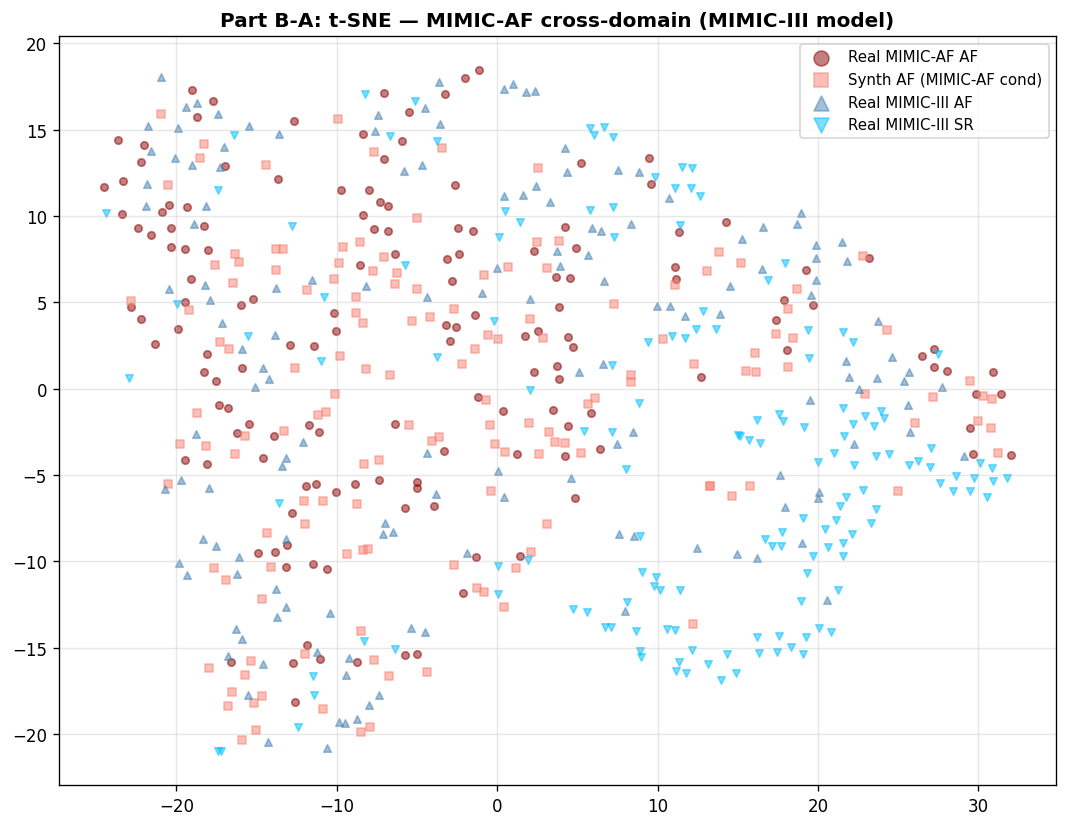


  Part B-A Fidelity Summary (MIMIC-AF-conditioned, MIMIC-III model)
  LSD (0.5–8 Hz)   : 5.2576 dB  (in-domain: 6.2013 dB)
  Mean Wasserstein : 0.6219
  MMD              : -0.00208  (domain gap: -0.00115)
  DTW              : 49.758±15.793  (domain gap: 45.301±11.070)


In [39]:
# ── Part B-A: Fidelity metrics — MIMIC-AF real AF vs MIMIC-III-generated ─────
N_FID_B = min(200, len(ppg_maf_real_sub), len(ppg_maf_synth))
feat_maf_real  = feature_vec(ppg_maf_real_sub[:N_FID_B])
feat_maf_synth = feature_vec(ppg_maf_synth[:N_FID_B])

lsd_maf_band = lsd(ppg_maf_real_sub[:N_FID_B], ppg_maf_synth[:N_FID_B], band=(0.5, 8.0))

print('Part B-A: Fidelity — MIMIC-AF real AF vs MIMIC-III-model MIMIC-AF-conditioned')
print(f'  LSD (0.5–8 Hz)   : {lsd_maf_band:.4f} dB  '
      f'(MIMIC-III in-domain: {lsd_mean:.4f} dB)')

print('\nWasserstein per feature:')
feat_names_ug = ['HR_mean','HR_std','Power_0-4Hz','Power_4-8Hz','RMS']
print(f"  {'Feature':<15}  {'MIMIC-AF cross':>18}  {'MIMIC-III in-domain':>22}")
print('  ' + '─' * 60)
_wd_maf = []
for i, fn in enumerate(feat_names_ug):
    wd_cross  = wasserstein_distance(feat_maf_real[:,i], feat_maf_synth[:,i])
    wd_indm   = wasserstein_distance(feats['real_AF'][:,i], feats['synth_AF'][:,i])
    _wd_maf.append(wd_cross)
    print(f'  {fn:<13}  {wd_cross:>18.4f}  {wd_indm:>22.4f}')

mmd_maf    = mmd_rbf(StandardScaler().fit_transform(feat_maf_real),
                     StandardScaler().fit_transform(feat_maf_synth))
mmd_domain = mmd_rbf(StandardScaler().fit_transform(feat_maf_real),
                     StandardScaler().fit_transform(feats['real_AF'][:N_FID_B]))
dtw_maf_m, dtw_maf_s   = batch_dtw_xdomain(ppg_maf_real_sub, ppg_maf_synth)
dtw_indm_m, dtw_indm_s = batch_dtw_xdomain(eval_real['AF'], eval_synth['AF'])
dtw_gap_m, dtw_gap_s   = batch_dtw_xdomain(ppg_maf_real_sub, eval_real['AF'])

print(f'\nMMD (feature space): MIMIC-AF real vs MIMIC-AF-synth={mmd_maf:.5f}  '
      f'(domain gap MIMIC-AF vs MIMIC-III: {mmd_domain:.5f})')
print(f'DTW:  MIMIC-AF real vs MIMIC-AF-synth: {dtw_maf_m:.3f}±{dtw_maf_s:.3f}  '
      f'(MIMIC-III in-domain: {dtw_indm_m:.3f}±{dtw_indm_s:.3f}  '
      f'domain gap: {dtw_gap_m:.3f}±{dtw_gap_s:.3f})')

# ── 4-way t-SNE ─────────────────────────────────────────────────────────────
N_T_B = min(150, N_FID_B)
_all_f_b = np.concatenate([feat_maf_real[:N_T_B], feat_maf_synth[:N_T_B],
                            feats['real_AF'][:N_T_B], feats['real_SR'][:N_T_B]])
_all_l_b = (['Real MIMIC-AF AF']*N_T_B + ['Synth AF (MIMIC-AF cond)']*N_T_B +
            ['Real MIMIC-III AF']*N_T_B + ['Real MIMIC-III SR']*N_T_B)
_sc_b    = StandardScaler().fit_transform(_all_f_b)
print('\nComputing t-SNE (4-way cross-domain, Part B)...')
_emb_b   = TSNE(n_components=2, perplexity=35, random_state=SEED,
                n_iter=1000).fit_transform(_sc_b)

_cmap_b  = {
    'Real MIMIC-AF AF':       ('darkred',    'o'),
    'Synth AF (MIMIC-AF cond)': ('salmon',   's'),
    'Real MIMIC-III AF':      ('steelblue',  '^'),
    'Real MIMIC-III SR':      ('deepskyblue','v'),
}
fig, ax = plt.subplots(figsize=(9, 7))
for lbl, (col, mrk) in _cmap_b.items():
    mask = [l == lbl for l in _all_l_b]
    ax.scatter(_emb_b[mask,0], _emb_b[mask,1], c=col, marker=mrk,
               alpha=0.5, s=20, label=lbl)
ax.set_title('Part B-A: t-SNE — MIMIC-AF cross-domain (MIMIC-III model)',
             fontweight='bold')
ax.legend(markerscale=2, fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(_Path(WORK_DIR)/'fig_partB_tsne.png', dpi=150); plt.show()

print()
print('=' * 72)
print('  Part B-A Fidelity Summary (MIMIC-AF-conditioned, MIMIC-III model)')
print('=' * 72)
print(f'  LSD (0.5–8 Hz)   : {lsd_maf_band:.4f} dB  '
      f'(in-domain: {lsd_mean:.4f} dB)')
print(f'  Mean Wasserstein : {np.mean(_wd_maf):.4f}')
print(f'  MMD              : {mmd_maf:.5f}  (domain gap: {mmd_domain:.5f})')
print(f'  DTW              : {dtw_maf_m:.3f}±{dtw_maf_s:.3f}  '
      f'(domain gap: {dtw_gap_m:.3f}±{dtw_gap_s:.3f})')
print('=' * 72)

In [40]:
# ── Part B-B: Classifier evaluation — two test sets ─────────────────────────

# Synthetic pool for classifier (may extend beyond fidelity evaluation subset)
N_MAF_CLF  = min(2000, len(meta_maf))
rng_maf_c  = np.random.default_rng(SEED + 10)
idx_maf_c  = rng_maf_c.choice(len(meta_maf), N_MAF_CLF, replace=False)

if N_MAF_CLF > len(ppg_maf_synth):
    _extra_idx = np.setdiff1d(idx_maf_c, idx_maf_gen)
    _cond_ext  = torch.tensor(
        build_cond(nm_maf[_extra_idx], ns_maf[_extra_idx],
                   nr_maf[_extra_idx], 'AF'),
        dtype=torch.float32).to(DEVICE)
    _extra_ch  = []
    for i in range(0, len(_cond_ext), 64):
        _extra_ch.append(
            heun_sample(ema_model, _cond_ext[i:i+64], ODE_STEPS, BEST_GS)
            .cpu().numpy().squeeze(1))
    ppg_maf_synth_clf = np.vstack([ppg_maf_synth, np.concatenate(_extra_ch)])
else:
    ppg_maf_synth_clf = ppg_maf_synth[:N_MAF_CLF]
print(f'MIMIC-AF-conditioned synthetic pool for classifier: {ppg_maf_synth_clf.shape}')

# ── Dataset construction ─────────────────────────────────────────────────────
N_B_UNIT = min(len(ppg_maf_synth_clf), len(real_pool_m3['AF']),
               len(real_pool_m3['SR']))
print(f'Balancing unit N_B_UNIT = {N_B_UNIT}')
rng_db   = np.random.default_rng(SEED + 20)
_samp_b  = lambda arr, n: arr[rng_db.choice(len(arr), min(n, len(arr)), replace=False)]

# DB1: 100% MIMIC-AF-synth AF + 100% real MIMIC-III SR
db1_X = np.vstack([_samp_b(ppg_maf_synth_clf, N_B_UNIT),
                   _samp_b(real_pool_m3['SR'],  N_B_UNIT)])
db1_y = np.array([1]*N_B_UNIT + [0]*N_B_UNIT)

# DB2: 50% MIMIC-AF-synth AF + 50% real MIMIC-III AF + 100% real MIMIC-III SR
N_H_B = N_B_UNIT // 2
db2_X = np.vstack([_samp_b(ppg_maf_synth_clf, N_H_B),
                   _samp_b(real_pool_m3['AF'],  N_H_B),
                   _samp_b(real_pool_m3['SR'],  N_B_UNIT)])
db2_y = np.array([1]*N_H_B + [1]*N_H_B + [0]*N_B_UNIT)

# DBref: 100% real MIMIC-III AF + 100% real MIMIC-III SR  (baseline)
dbref_X = np.vstack([_samp_b(real_pool_m3['AF'], N_B_UNIT),
                     _samp_b(real_pool_m3['SR'],  N_B_UNIT)])
dbref_y = np.array([1]*N_B_UNIT + [0]*N_B_UNIT)

datasets_B = {
    'DB1  — MIMIC-AF-synth AF + MIMIC-III SR':                  (db1_X,  db1_y),
    'DB2  — MIMIC-AF-synth AF + MIMIC-III AF + MIMIC-III SR':   (db2_X,  db2_y),
    'DBref — real MIMIC-III AF + real MIMIC-III SR (baseline)':  (dbref_X,dbref_y),
}

# ── Cross-domain test set: real MIMIC-AF AF + real MIMIC-III SR ──────────────
N_XDOM_B = min(len(ppg_maf_real), int((y_te == 0).sum()))
rng_xb   = np.random.default_rng(SEED + 30)
_idx_maf_xdom = rng_xb.choice(len(ppg_maf_real), N_XDOM_B, replace=False)
_idx_m3_sr    = rng_xb.choice(np.where(y_te == 0)[0], N_XDOM_B, replace=False)
X_xdom_B = np.vstack([ppg_maf_real[_idx_maf_xdom], X_te[_idx_m3_sr]])
y_xdom_B = np.array([1]*N_XDOM_B + [0]*N_XDOM_B)
print(f'Cross-domain test set B: MIMIC-AF AF={N_XDOM_B}  MIMIC-III SR={N_XDOM_B}')

# ── Run — two test sets ───────────────────────────────────────────────────────
print(f'\nTraining ClfUNetGAN on DB datasets (5 seeds, two test sets)...')
results_B_m3, results_B_xdom = run_clf_ug_dual(
    datasets_B, X_vl, y_vl,
    X_te, y_te, 'MIMIC-III',
    X_xdom_B, y_xdom_B, 'XDom-MAF',
    n_seeds=5)

print_ug_table(results_B_m3,
    'Part B-B [Test 1: MIMIC-III real test set] — ClfUNetGAN, MIMIC-AF-conditioned')
print_ug_table(results_B_xdom,
    'Part B-B [Test 2: Cross-domain — real MIMIC-AF AF + real MIMIC-III SR]')
print('\nDBref = TRTR baseline (same pool as DAref in Part A, different sampler seed).')
_gap_b = (results_B_xdom['DB1  — MIMIC-AF-synth AF + MIMIC-III SR']['auroc'][0] -
          results_B_xdom['DBref — real MIMIC-III AF + real MIMIC-III SR (baseline)']['auroc'][0])
print(f'Cross-domain AUROC gap DB1 vs DBref: {_gap_b:+.4f}')

MIMIC-AF-conditioned synthetic pool for classifier: (2000, 1250)
Balancing unit N_B_UNIT = 1000
Cross-domain test set B: MIMIC-AF AF=2253  MIMIC-III SR=2253

Training ClfUNetGAN on DB datasets (5 seeds, two test sets)...

DB1  — MIMIC-AF-synth AF + MIMIC-III SR
  seed 0  [MIMIC-III] AUROC=0.7230  F1=0.7129  [XDom-MAF] AUROC=0.7623  F1=0.7537  thr=0.42
  seed 1  [MIMIC-III] AUROC=0.7273  F1=0.7105  [XDom-MAF] AUROC=0.7676  F1=0.7515  thr=0.38
  seed 2  [MIMIC-III] AUROC=0.7238  F1=0.7105  [XDom-MAF] AUROC=0.7633  F1=0.7524  thr=0.42
  seed 3  [MIMIC-III] AUROC=0.7272  F1=0.7140  [XDom-MAF] AUROC=0.7684  F1=0.7556  thr=0.44
  seed 4  [MIMIC-III] AUROC=0.7281  F1=0.7141  [XDom-MAF] AUROC=0.7694  F1=0.7550  thr=0.45
  -> [MIMIC-III] AUROC=0.7259±0.0021  [XDom-MAF] AUROC=0.7662±0.0029

DB2  — MIMIC-AF-synth AF + MIMIC-III AF + MIMIC-III SR
  seed 0  [MIMIC-III] AUROC=0.7411  F1=0.7247  [XDom-MAF] AUROC=0.7876  F1=0.7651  thr=0.40
  seed 1  [MIMIC-III] AUROC=0.7277  F1=0.7110  [XDom-MAF] AUR

---
## Part C — Cross-Domain FV: ZenodoV2 as External Dataset

**Same structure as Part B, replacing MIMIC-AF with ZenodoV2.**  
ZenodoV2 is an ambulatory wrist-PPG dataset (CART study, Bittium Faros ECG, wrist PPG 100 Hz).  
The MIMIC-III model is conditioned on ZenodoV2 ECG-derived IBI features (QRS index + RR arrays  
directly from HDF5 — same source as used to train the Zenodo v2 model).  
ZenodoV2 IBI features are normalised with **MIMIC-III training statistics** (§3).

| Dataset | Training data |
|---------|--------------|
| DC1 | 100% ZenodoV2-synth AF + 100% real MIMIC-III SR |
| DC2 | 50% ZenodoV2-synth AF + 50% real MIMIC-III AF + 100% real MIMIC-III SR |
| DCref | 100% real MIMIC-III AF + 100% real MIMIC-III SR (baseline) |

**Cross-domain test set:** real ZenodoV2 AF + real MIMIC-III SR

In [41]:
import h5py
from scipy.signal import resample_poly as _resample_poly

# ── ZenodoV2 paths and constants ─────────────────────────────────────────────
ZENODO_DATA_DIR  = _Path('/kaggle/input/datasets/vegatronxz/zenodo-v2/zenodo_v2')
ZENODO_IBI_CACHE = _Path(WORK_DIR) / 'zenodo_af_ibi_for_m3.csv'
ZENODO_NPZ_CACHE = _Path(WORK_DIR) / 'zenodo_af_ppg_for_m3.npz'

# Cat A subjects have AF >= 200 windows in the Zenodo dataset
_ZENODO_CAT_A   = [1,2,4,6,8,11,12,17,18,19,20,21,23,27,32,34,37,41,43,44,45]
_ZENODO_ECG_FS  = 500     # Hz — Bittium Faros ECG
_ZENODO_PPG_FS  = 100     # Hz — wrist PPG (original)
_ZENODO_WIN_RAW = WIN_SEC * _ZENODO_PPG_FS  # 1000 samples @ 100Hz per 10s window
_ZENODO_EXCL    = {28, 29, 42}              # corrupted/unusable subjects

def _decode_z(arr):
    try: return ''.join(chr(int(c)) for c in np.array(arr).flatten() if int(c) != 0).strip()
    except: return ''

def _ts_to_s(day_str, time_str):
    try:
        day   = int(day_str.strip()) if day_str.strip().isdigit() else 1
        h,m,s = [int(x) for x in time_str.strip().split(':')][:3]
        return (day-1)*86400 + h*3600 + m*60 + s
    except: return None

def _load_zen_ecg(sid):
    fpath = ZENODO_DATA_DIR / f'{sid:03d}_ECG.mat'
    with h5py.File(fpath, 'r') as f:
        qrs = np.array(f['QRSindex']).squeeze().astype(int)
        af  = np.array(f['AF_annotation']).squeeze().astype(int)
        rr  = np.array(f['rr']).squeeze().astype(np.float64)
        t0  = _ts_to_s(_decode_z(f['recording_startday']),
                        _decode_z(f['recording_starttime']))
    qrs = qrs[:len(af)]
    return dict(qrs=qrs, af=af, rr=rr, t0_sec=t0)

def _load_zen_ppg_segs(sid):
    """
    PPG file: recording_startday / recording_starttime are arrays of HDF5
    references — one per PPG segment. Must dereference each with f[ref] before
    decoding, unlike the ECG file where they are direct ASCII arrays.
    """
    fpath = ZENODO_DATA_DIR / f'{sid:03d}_PPG.mat'
    segs  = []
    with h5py.File(fpath, 'r') as f:
        ppg_refs  = f['PPG_GREEN']              # (n_segs, 1) ref array
        day_refs  = f['recording_startday']     # (n_segs, 1) ref array
        time_refs = f['recording_starttime']    # (n_segs, 1) ref array
        for i in range(ppg_refs.shape[0]):
            sig      = np.array(f[ppg_refs[i, 0]]).squeeze().astype(np.float32)
            # KEY FIX: dereference day/time refs before decoding
            day_str  = _decode_z(f[day_refs[i, 0]])
            time_str = _decode_z(f[time_refs[i, 0]])
            t0       = _ts_to_s(day_str, time_str)
            if t0 is not None:
                segs.append(dict(sig=sig, t0_sec=t0))
    return segs

_b4z, _a4z = butter(4, [0.5/(_ZENODO_PPG_FS/2), 8./(_ZENODO_PPG_FS/2)], btype='band')

def _preproc_zen_ppg(win_raw):
    """Bandpass 100Hz → resample 100→125Hz → min-max [-1,1]."""    
    if not np.all(np.isfinite(win_raw)) or np.all(win_raw == win_raw[0]): return None
    filt = filtfilt(_b4z, _a4z, win_raw.astype(float))
    if np.std(filt) < 1e-4: return None
    sig125 = _resample_poly(filt, FS, _ZENODO_PPG_FS)[:WIN_LEN]
    if len(sig125) < WIN_LEN: return None
    mn, mx = sig125.min(), sig125.max()
    if mx - mn < 1e-8: return None
    return (2*(sig125 - mn)/(mx - mn) - 1).astype(np.float32)

def _zen_ecg_features(rr_window):
    rr = rr_window[(rr_window >= IBI_MIN) & (rr_window <= IBI_MAX)]
    if len(rr) < 2: return None, None, None
    ibi_m = float(np.mean(rr)); hr = 60./ibi_m
    if not (30 < hr < 200): return None, None, None
    ibi_s = float(np.std(rr))
    rmssd = float(np.sqrt(np.mean(np.diff(rr)**2))) if len(rr) >= 3 else 0.05
    return ibi_m, ibi_s, rmssd

# ── Build or load cache ───────────────────────────────────────────────────────
if ZENODO_NPZ_CACHE.exists() and ZENODO_IBI_CACHE.exists():
    print('Loading ZenodoV2 AF window cache...')
    _dz = np.load(ZENODO_NPZ_CACHE)
    ppg_zen_real  = _dz['signals']
    meta_zen      = pd.read_csv(ZENODO_IBI_CACHE)
    print(f'  PPG windows  : {ppg_zen_real.shape}')
    print(f'  IBI metadata : {len(meta_zen)} rows')
else:
    print('Building ZenodoV2 AF catalogue (first run — ~30–60 min)...')
    rows_z, sigs_z = [], []
    CAP_ZEN = 600   # max AF windows per subject

    for sid in sorted(_ZENODO_CAT_A):
        if sid in _ZENODO_EXCL: continue
        try:
            ecg_d = _load_zen_ecg(sid)
            segs  = _load_zen_ppg_segs(sid)
        except Exception as e:
            print(f'  S{sid:03d}: load error {e}'); continue

        qrs_t_abs = ecg_d['qrs'] / _ZENODO_ECG_FS + ecg_d['t0_sec']
        af_wins   = []

        for seg in segs:
            if len(af_wins) >= CAP_ZEN: break
            sig = seg['sig'].astype(float); t0 = seg['t0_sec']
            n_w = len(sig) // _ZENODO_WIN_RAW

            for wi in range(n_w):
                if len(af_wins) >= CAP_ZEN: break
                s0      = wi * _ZENODO_WIN_RAW
                t_start = t0 + s0 / _ZENODO_PPG_FS
                t_end   = t_start + WIN_SEC
                beat_m  = (qrs_t_abs >= t_start) & (qrs_t_abs < t_end)
                beat_i  = np.where(beat_m)[0]
                if len(beat_i) < 4: continue
                if ecg_d['af'][beat_i].mean() <= 0.5: continue  # keep AF only
                rr_win  = ecg_d['rr'][beat_i]
                im, is_, irm = _zen_ecg_features(rr_win)
                if im is None: continue
                ppg = _preproc_zen_ppg(seg['sig'][s0:s0+_ZENODO_WIN_RAW])
                if ppg is None: continue
                af_wins.append((ppg, im, is_, irm))

        for ppg, im, is_, irm in af_wins:
            sigs_z.append(ppg)
            rows_z.append({'subject_id': sid, 'ibi_mean': im,
                           'ibi_std': is_, 'rmssd': irm})
        print(f'  S{sid:03d}: {len(af_wins)} AF windows')

    ppg_zen_real = np.array(sigs_z, dtype=np.float32)
    meta_zen     = pd.DataFrame(rows_z)
    np.savez_compressed(ZENODO_NPZ_CACHE, signals=ppg_zen_real)
    meta_zen.to_csv(ZENODO_IBI_CACHE, index=False)
    print(f'  Cached {ppg_zen_real.shape[0]} ZenodoV2 AF windows → {ZENODO_NPZ_CACHE}')

print(f'\nZenodoV2 AF windows available: {ppg_zen_real.shape}')
print('IBI statistics (raw seconds):')
print(meta_zen[['ibi_mean','ibi_std','rmssd']].describe().round(4).to_string())

Building ZenodoV2 AF catalogue (first run — ~30–60 min)...
  S001: 600 AF windows
  S002: 600 AF windows
  S004: 600 AF windows
  S006: 600 AF windows
  S008: 600 AF windows
  S011: 496 AF windows
  S012: 600 AF windows
  S017: 600 AF windows
  S018: 600 AF windows
  S019: 600 AF windows
  S020: 600 AF windows
  S021: 600 AF windows
  S023: 600 AF windows
  S027: 600 AF windows
  S032: 600 AF windows
  S034: 600 AF windows
  S037: 600 AF windows
  S041: 600 AF windows
  S043: 600 AF windows
  S044: 600 AF windows
  S045: 11 AF windows
  Cached 11907 ZenodoV2 AF windows → /kaggle/working/zenodo_af_ppg_for_m3.npz

ZenodoV2 AF windows available: (11907, 1250)
IBI statistics (raw seconds):
         ibi_mean     ibi_std       rmssd
count  11907.0000  11907.0000  11907.0000
mean       0.6529      0.1529      0.2171
std        0.1836      0.0633      0.0954
min        0.3498      0.0222      0.0375
25%        0.5107      0.1098      0.1520
50%        0.6193      0.1418      0.1992
75%        

In [42]:
# ── Normalise ZenodoV2 IBI with MIMIC-III training statistics ────────────────
nm_zen, ns_zen, nr_zen = norm_ibi(
    meta_zen['ibi_mean'].values,
    meta_zen['ibi_std'].values,
    meta_zen['rmssd'].values)

N_ZEN_GEN   = min(2000, len(meta_zen))
rng_zen     = np.random.default_rng(SEED)
idx_zen_gen = rng_zen.choice(len(meta_zen), N_ZEN_GEN, replace=False)

cond_zen_t = torch.tensor(
    build_cond(nm_zen[idx_zen_gen], ns_zen[idx_zen_gen],
               nr_zen[idx_zen_gen], 'AF'),
    dtype=torch.float32).to(DEVICE)
ppg_zen_real_sub = ppg_zen_real[idx_zen_gen]

print(f'Generating {N_ZEN_GEN} synthetic AF windows '
      f'(ZenodoV2 conditioning → MIMIC-III model)...')
_chunks_zen = []
for i in range(0, len(cond_zen_t), 64):
    _chunks_zen.append(
        heun_sample(ema_model, cond_zen_t[i:i+64], ODE_STEPS, BEST_GS)
        .cpu().numpy().squeeze(1))
ppg_zen_synth = np.concatenate(_chunks_zen)

print(f'Generated: {ppg_zen_synth.shape}  '
      f'range=[{ppg_zen_synth.min():.3f}, {ppg_zen_synth.max():.3f}]')

Generating 2000 synthetic AF windows (ZenodoV2 conditioning → MIMIC-III model)...
Generated: (2000, 1250)  range=[-1.035, 1.031]


Part C-A: Fidelity — ZenodoV2 real AF vs MIMIC-III-model ZenodoV2-conditioned
  LSD (0.5–8 Hz)   : 7.8164 dB  (MIMIC-III in-domain: 6.2013 dB  MIMIC-AF cross: 5.2576 dB)

Wasserstein per feature:
  Feature            ZenodoV2 cross    MIMIC-AF cross     MIMIC-III in-domain
  ──────────────────────────────────────────────────────────────────────────
  HR_mean                  9.6823            1.7955                  3.2242
  HR_std                   7.7372            1.2561                  1.0126
  Power_0-4Hz              0.0537            0.0228                  0.0253
  Power_4-8Hz              0.0017            0.0007                  0.0006
  RMS                      0.0958            0.0347                  0.0239

MMD: ZenodoV2 real vs ZenodoV2-synth=0.13125  (ZenodoV2 vs MIMIC-III domain gap: 0.17078)
DTW: ZenodoV2 real vs ZenodoV2-synth: 73.769±21.145  (domain gap: 65.594±21.209)

Computing t-SNE (4-way cross-domain, Part C)...


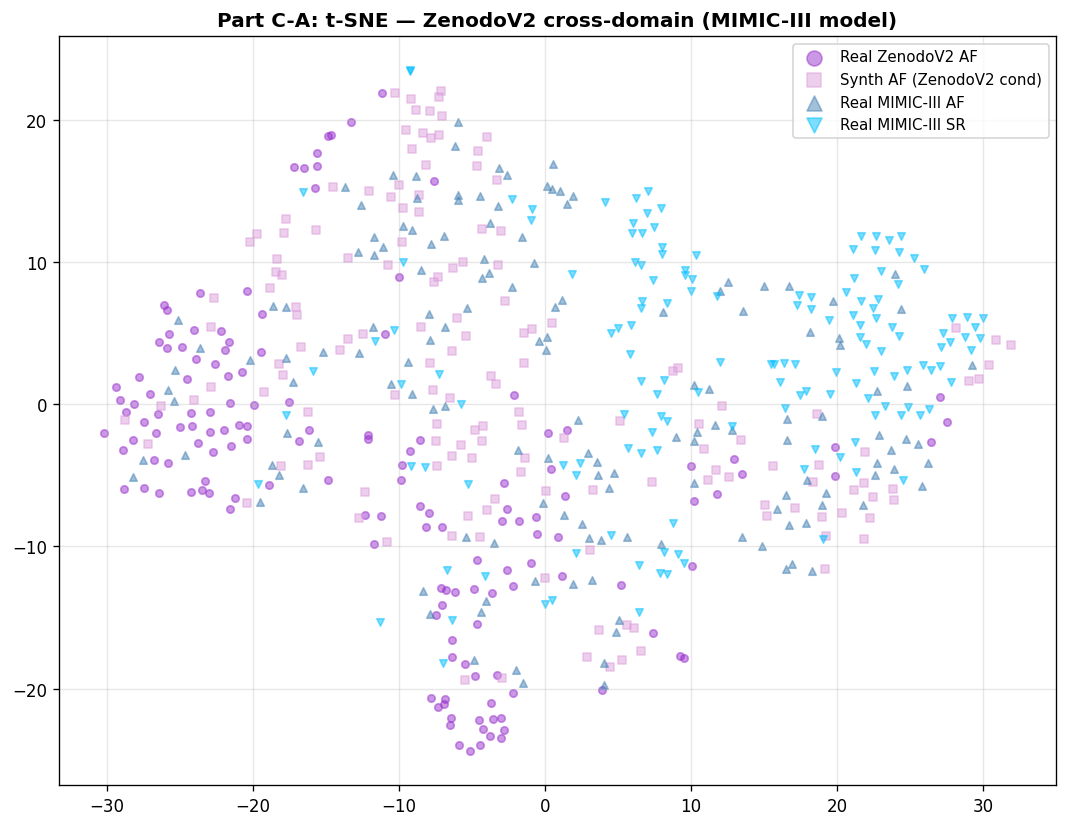


  Part C-A Fidelity Summary (ZenodoV2-conditioned, MIMIC-III model)
  LSD (0.5–8 Hz)   : 7.8164 dB  (MIMIC-AF cross: 5.2576 dB  in-domain: 6.2013 dB)
  Mean Wasserstein : 3.5142
  MMD              : 0.13125  (domain gap: 0.17078)
  DTW              : 73.769±21.145  (domain gap: 65.594±21.209)


In [43]:
# ── Part C-A: Fidelity — ZenodoV2 real AF vs MIMIC-III-generated ─────────────
N_FID_C = min(200, len(ppg_zen_real_sub), len(ppg_zen_synth))
feat_zen_real  = feature_vec(ppg_zen_real_sub[:N_FID_C])
feat_zen_synth = feature_vec(ppg_zen_synth[:N_FID_C])

lsd_zen_band = lsd(ppg_zen_real_sub[:N_FID_C], ppg_zen_synth[:N_FID_C], band=(0.5, 8.0))

print('Part C-A: Fidelity — ZenodoV2 real AF vs MIMIC-III-model ZenodoV2-conditioned')
print(f'  LSD (0.5–8 Hz)   : {lsd_zen_band:.4f} dB  '
      f'(MIMIC-III in-domain: {lsd_mean:.4f} dB  '
      f'MIMIC-AF cross: {lsd_maf_band:.4f} dB)')

print('\nWasserstein per feature:')
print(f"  {'Feature':<15}  {'ZenodoV2 cross':>16}  {'MIMIC-AF cross':>16}  {'MIMIC-III in-domain':>22}")
print('  ' + '─' * 74)
_wd_zen = []
for i, fn in enumerate(feat_names_ug):
    wd_z  = wasserstein_distance(feat_zen_real[:,i], feat_zen_synth[:,i])
    wd_m  = wasserstein_distance(feat_maf_real[:N_FID_C,i], feat_maf_synth[:N_FID_C,i])
    wd_in = wasserstein_distance(feats['real_AF'][:,i], feats['synth_AF'][:,i])
    _wd_zen.append(wd_z)
    print(f'  {fn:<13}  {wd_z:>16.4f}  {wd_m:>16.4f}  {wd_in:>22.4f}')

_sc_std = StandardScaler()
_sc_std.fit(np.vstack([feat_zen_real, feat_zen_synth]))
mmd_zen    = mmd_rbf(_sc_std.transform(feat_zen_real),
                     _sc_std.transform(feat_zen_synth))
mmd_zen_d  = mmd_rbf(_sc_std.transform(feat_zen_real),
                     _sc_std.transform(feats['real_AF'][:N_FID_C]))
dtw_zen_m, dtw_zen_s = batch_dtw_xdomain(ppg_zen_real_sub, ppg_zen_synth)
dtw_zen_d_m, dtw_zen_d_s = batch_dtw_xdomain(ppg_zen_real_sub, eval_real['AF'])

print(f'\nMMD: ZenodoV2 real vs ZenodoV2-synth={mmd_zen:.5f}  '
      f'(ZenodoV2 vs MIMIC-III domain gap: {mmd_zen_d:.5f})')
print(f'DTW: ZenodoV2 real vs ZenodoV2-synth: {dtw_zen_m:.3f}±{dtw_zen_s:.3f}  '
      f'(domain gap: {dtw_zen_d_m:.3f}±{dtw_zen_d_s:.3f})')

# ── 4-way t-SNE ─────────────────────────────────────────────────────────────
N_T_C = min(150, N_FID_C)
_all_f_c = np.concatenate([feat_zen_real[:N_T_C], feat_zen_synth[:N_T_C],
                            feats['real_AF'][:N_T_C], feats['real_SR'][:N_T_C]])
_all_l_c = (['Real ZenodoV2 AF']*N_T_C + ['Synth AF (ZenodoV2 cond)']*N_T_C +
            ['Real MIMIC-III AF']*N_T_C + ['Real MIMIC-III SR']*N_T_C)
_sc_c    = StandardScaler().fit_transform(_all_f_c)
print('\nComputing t-SNE (4-way cross-domain, Part C)...')
_emb_c   = TSNE(n_components=2, perplexity=35, random_state=SEED,
                n_iter=1000).fit_transform(_sc_c)

_cmap_c = {
    'Real ZenodoV2 AF':         ('darkorchid',  'o'),
    'Synth AF (ZenodoV2 cond)': ('plum',        's'),
    'Real MIMIC-III AF':        ('steelblue',   '^'),
    'Real MIMIC-III SR':        ('deepskyblue', 'v'),
}
fig, ax = plt.subplots(figsize=(9, 7))
for lbl, (col, mrk) in _cmap_c.items():
    mask = [l == lbl for l in _all_l_c]
    ax.scatter(_emb_c[mask,0], _emb_c[mask,1], c=col, marker=mrk,
               alpha=0.5, s=20, label=lbl)
ax.set_title('Part C-A: t-SNE — ZenodoV2 cross-domain (MIMIC-III model)',
             fontweight='bold')
ax.legend(markerscale=2, fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(_Path(WORK_DIR)/'fig_partC_tsne.png', dpi=150); plt.show()

print()
print('=' * 72)
print('  Part C-A Fidelity Summary (ZenodoV2-conditioned, MIMIC-III model)')
print('=' * 72)
print(f'  LSD (0.5–8 Hz)   : {lsd_zen_band:.4f} dB  '
      f'(MIMIC-AF cross: {lsd_maf_band:.4f} dB  in-domain: {lsd_mean:.4f} dB)')
print(f'  Mean Wasserstein : {np.mean(_wd_zen):.4f}')
print(f'  MMD              : {mmd_zen:.5f}  (domain gap: {mmd_zen_d:.5f})')
print(f'  DTW              : {dtw_zen_m:.3f}±{dtw_zen_s:.3f}  '
      f'(domain gap: {dtw_zen_d_m:.3f}±{dtw_zen_d_s:.3f})')
print('=' * 72)

In [44]:
# ── Part C-B: Classifier evaluation — ZenodoV2 cross-domain ──────────────────

N_ZEN_CLF  = min(2000, len(meta_zen))
rng_zen_c  = np.random.default_rng(SEED + 10)
idx_zen_c  = rng_zen_c.choice(len(meta_zen), N_ZEN_CLF, replace=False)

if N_ZEN_CLF > len(ppg_zen_synth):
    _extra_iz = np.setdiff1d(idx_zen_c, idx_zen_gen)
    _cond_ez  = torch.tensor(
        build_cond(nm_zen[_extra_iz], ns_zen[_extra_iz],
                   nr_zen[_extra_iz], 'AF'),
        dtype=torch.float32).to(DEVICE)
    _extra_cz = []
    for i in range(0, len(_cond_ez), 64):
        _extra_cz.append(
            heun_sample(ema_model, _cond_ez[i:i+64], ODE_STEPS, BEST_GS)
            .cpu().numpy().squeeze(1))
    ppg_zen_synth_clf = np.vstack([ppg_zen_synth, np.concatenate(_extra_cz)])
else:
    ppg_zen_synth_clf = ppg_zen_synth[:N_ZEN_CLF]
print(f'ZenodoV2-conditioned synthetic pool for classifier: {ppg_zen_synth_clf.shape}')

# ── Dataset construction ─────────────────────────────────────────────────────
N_C_UNIT = min(len(ppg_zen_synth_clf), len(real_pool_m3['AF']),
               len(real_pool_m3['SR']))
print(f'Balancing unit N_C_UNIT = {N_C_UNIT}')
rng_dc   = np.random.default_rng(SEED + 20)
_samp_c  = lambda arr, n: arr[rng_dc.choice(len(arr), min(n, len(arr)), replace=False)]

# DC1: 100% ZenodoV2-synth AF + 100% real MIMIC-III SR
dc1_X = np.vstack([_samp_c(ppg_zen_synth_clf, N_C_UNIT),
                   _samp_c(real_pool_m3['SR'],  N_C_UNIT)])
dc1_y = np.array([1]*N_C_UNIT + [0]*N_C_UNIT)

# DC2: 50% ZenodoV2-synth AF + 50% real MIMIC-III AF + 100% real MIMIC-III SR
N_H_C = N_C_UNIT // 2
dc2_X = np.vstack([_samp_c(ppg_zen_synth_clf, N_H_C),
                   _samp_c(real_pool_m3['AF'],  N_H_C),
                   _samp_c(real_pool_m3['SR'],  N_C_UNIT)])
dc2_y = np.array([1]*N_H_C + [1]*N_H_C + [0]*N_C_UNIT)

# DCref: 100% real MIMIC-III AF + 100% real MIMIC-III SR (baseline)
dcref_X = np.vstack([_samp_c(real_pool_m3['AF'], N_C_UNIT),
                     _samp_c(real_pool_m3['SR'],  N_C_UNIT)])
dcref_y = np.array([1]*N_C_UNIT + [0]*N_C_UNIT)

datasets_C = {
    'DC1  — ZenodoV2-synth AF + MIMIC-III SR':                  (dc1_X,  dc1_y),
    'DC2  — ZenodoV2-synth AF + MIMIC-III AF + MIMIC-III SR':   (dc2_X,  dc2_y),
    'DCref — real MIMIC-III AF + real MIMIC-III SR (baseline)':  (dcref_X,dcref_y),
}

# ── Cross-domain test set: real ZenodoV2 AF + real MIMIC-III SR ──────────────
N_XDOM_C = min(len(ppg_zen_real), int((y_te == 0).sum()))
rng_xc   = np.random.default_rng(SEED + 30)
_idx_zen_xdom = rng_xc.choice(len(ppg_zen_real), N_XDOM_C, replace=False)
_idx_m3_sr2   = rng_xc.choice(np.where(y_te == 0)[0], N_XDOM_C, replace=False)
X_xdom_C = np.vstack([ppg_zen_real[_idx_zen_xdom], X_te[_idx_m3_sr2]])
y_xdom_C = np.array([1]*N_XDOM_C + [0]*N_XDOM_C)
print(f'Cross-domain test set C: ZenodoV2 AF={N_XDOM_C}  MIMIC-III SR={N_XDOM_C}')

# ── Run — two test sets ───────────────────────────────────────────────────────
print(f'\nTraining ClfUNetGAN on DC datasets (5 seeds, two test sets)...')
results_C_m3, results_C_xdom = run_clf_ug_dual(
    datasets_C, X_vl, y_vl,
    X_te, y_te, 'MIMIC-III',
    X_xdom_C, y_xdom_C, 'XDom-Zen',
    n_seeds=5)

print_ug_table(results_C_m3,
    'Part C-B [Test 1: MIMIC-III real test set] — ClfUNetGAN, ZenodoV2-conditioned')
print_ug_table(results_C_xdom,
    'Part C-B [Test 2: Cross-domain — real ZenodoV2 AF + real MIMIC-III SR]')

_gap_c = (results_C_xdom['DC1  — ZenodoV2-synth AF + MIMIC-III SR']['auroc'][0] -
          results_C_xdom['DCref — real MIMIC-III AF + real MIMIC-III SR (baseline)']['auroc'][0])
print(f'Cross-domain AUROC gap DC1 vs DCref: {_gap_c:+.4f}')

ZenodoV2-conditioned synthetic pool for classifier: (2000, 1250)
Balancing unit N_C_UNIT = 1000
Cross-domain test set C: ZenodoV2 AF=11907  MIMIC-III SR=11907

Training ClfUNetGAN on DC datasets (5 seeds, two test sets)...

DC1  — ZenodoV2-synth AF + MIMIC-III SR
  seed 0  [MIMIC-III] AUROC=0.7367  F1=0.7128  [XDom-Zen] AUROC=0.8042  F1=0.7562  thr=0.36
  seed 1  [MIMIC-III] AUROC=0.7328  F1=0.7109  [XDom-Zen] AUROC=0.7926  F1=0.7494  thr=0.37
  seed 2  [MIMIC-III] AUROC=0.7394  F1=0.7147  [XDom-Zen] AUROC=0.8163  F1=0.7610  thr=0.36
  seed 3  [MIMIC-III] AUROC=0.7374  F1=0.7115  [XDom-Zen] AUROC=0.8082  F1=0.7587  thr=0.38
  seed 4  [MIMIC-III] AUROC=0.7400  F1=0.7116  [XDom-Zen] AUROC=0.8142  F1=0.7608  thr=0.41
  -> [MIMIC-III] AUROC=0.7373±0.0026  [XDom-Zen] AUROC=0.8071±0.0084

DC2  — ZenodoV2-synth AF + MIMIC-III AF + MIMIC-III SR
  seed 0  [MIMIC-III] AUROC=0.7460  F1=0.7225  [XDom-Zen] AUROC=0.8538  F1=0.7843  thr=0.41
  seed 1  [MIMIC-III] AUROC=0.7300  F1=0.7133  [XDom-Zen] A

---
## Part D — Cross-Domain FV: VitalDB as External Dataset

**Same structure as Parts B and C, replacing the external dataset with VitalDB.**  
VitalDB is an intraoperative monitoring dataset (500 Hz ICU ventilator signals, resampled  
to 125 Hz). The VitalDB AF dataset is already pre-processed and stored as NumPy arrays  
(`ppg_windows.npy` — z-scored 1250-sample windows; `metadata_windows.csv` — with  
ECG-derived IBI_mean, IBI_std, RMSSD).  
PPG windows are rescaled per-window from z-score to [-1, 1] before comparison/generation.  
VitalDB IBI features are normalised with **MIMIC-III training statistics** (§3).

| Dataset | Training data |
|---------|--------------|
| DD1 | 100% VitalDB-synth AF + 100% real MIMIC-III SR |
| DD2 | 50% VitalDB-synth AF + 50% real MIMIC-III AF + 100% real MIMIC-III SR |
| DDref | 100% real MIMIC-III AF + 100% real MIMIC-III SR (baseline) |

**Cross-domain test set:** real VitalDB AF + real MIMIC-III SR

In [45]:
# ── Load VitalDB AF windows (pre-processed dataset) ──────────────────────────
VITALDB_DIR = _Path('/kaggle/input/datasets/vegatronxz/'
                    'vitaldb-af-dataset/vitaldb_af_dataset')

ppg_vdb_raw = np.load(VITALDB_DIR / 'ppg_windows.npy')        # (N,1250) z-scored
meta_vdb    = pd.read_csv(VITALDB_DIR / 'metadata_windows.csv')

print(f'VitalDB AF windows : {ppg_vdb_raw.shape}')
print(f'Metadata rows      : {len(meta_vdb)}')
print(f'Cases              : {meta_vdb["case_id"].nunique()}')
print()
print('IBI statistics (raw seconds):')
print(meta_vdb[['ibi_mean','ibi_std','rmssd']].describe().round(4).to_string())

# ── Rescale z-scored VitalDB PPG → [-1, 1] per window ────────────────────────
# The stored signals are z-scored (mean=0, std=1). The MIMIC-III model expects
# bandpass-filtered, min-max normalised signals in [-1, 1]. Per-window rescaling
# preserves the morphology while matching the training amplitude range.
def _zscore_to_minmax(signals):
    out = np.empty_like(signals)
    for i, sig in enumerate(signals):
        mn, mx = sig.min(), sig.max()
        out[i] = (2*(sig-mn)/(mx-mn) - 1) if mx-mn > 1e-8 else np.zeros_like(sig)
    return out.astype(np.float32)

ppg_vdb_mm = _zscore_to_minmax(ppg_vdb_raw)
print(f'\nAfter per-window min-max rescaling:')
print(f'  range [{ppg_vdb_mm.min():.3f}, {ppg_vdb_mm.max():.3f}]  '
      f'mean={ppg_vdb_mm.mean():.4f}  std={ppg_vdb_mm.std():.4f}')

VitalDB AF windows : (12461, 1250)
Metadata rows      : 12461
Cases              : 106

IBI statistics (raw seconds):
         ibi_mean     ibi_std       rmssd
count  12461.0000  12461.0000  12461.0000
mean       0.7751      0.1673      0.2302
std        0.1992      0.0887      0.1258
min        0.3688      0.0012      0.0013
25%        0.6237      0.1103      0.1485
50%        0.7530      0.1524      0.2095
75%        0.8974      0.2084      0.2905
max        1.7920      0.7022      0.9884

After per-window min-max rescaling:
  range [-1.000, 1.000]  mean=-0.3486  std=0.4591


In [46]:
# ── Normalise VitalDB IBI with MIMIC-III training statistics ─────────────────
nm_vdb, ns_vdb, nr_vdb = norm_ibi(
    meta_vdb['ibi_mean'].values,
    meta_vdb['ibi_std'].values,
    meta_vdb['rmssd'].values)

N_VDB_GEN   = min(2000, len(meta_vdb))
rng_vdb     = np.random.default_rng(SEED)
idx_vdb_gen = rng_vdb.choice(len(meta_vdb), N_VDB_GEN, replace=False)

cond_vdb_t = torch.tensor(
    build_cond(nm_vdb[idx_vdb_gen], ns_vdb[idx_vdb_gen],
               nr_vdb[idx_vdb_gen], 'AF'),
    dtype=torch.float32).to(DEVICE)
ppg_vdb_real_sub = ppg_vdb_mm[idx_vdb_gen]

print(f'Generating {N_VDB_GEN} synthetic AF windows '
      f'(VitalDB conditioning → MIMIC-III model)...')
_chunks_vdb = []
for i in range(0, len(cond_vdb_t), 64):
    _chunks_vdb.append(
        heun_sample(ema_model, cond_vdb_t[i:i+64], ODE_STEPS, BEST_GS)
        .cpu().numpy().squeeze(1))
ppg_vdb_synth = np.concatenate(_chunks_vdb)

print(f'Generated: {ppg_vdb_synth.shape}  '
      f'range=[{ppg_vdb_synth.min():.3f}, {ppg_vdb_synth.max():.3f}]')

Generating 2000 synthetic AF windows (VitalDB conditioning → MIMIC-III model)...
Generated: (2000, 1250)  range=[-1.039, 1.031]


Part D-A: Fidelity — VitalDB real AF vs MIMIC-III-model VitalDB-conditioned
  LSD (0.5–8 Hz)   : 6.8727 dB
    MIMIC-AF cross : 5.2576 dB  ZenodoV2 cross: 7.8164 dB  in-domain: 6.2013 dB

Wasserstein per feature:
  Feature             VitalDB cross    ZenodoV2 cross    MIMIC-AF cross     in-domain
  ────────────────────────────────────────────────────────────────────────────────
  HR_mean                  5.6388            9.6823            1.7955        3.2242
  HR_std                   1.8762            7.7372            1.2561        1.0126
  Power_0-4Hz              0.0736            0.0537            0.0228        0.0253
  Power_4-8Hz              0.0006            0.0017            0.0007        0.0006
  RMS                      0.0354            0.0958            0.0347        0.0239

MMD: VitalDB real vs VDB-synth=0.07753  (VitalDB vs MIMIC-III domain gap: 0.10363)
DTW: VitalDB real vs VDB-synth: 49.911±15.242  (domain gap: 48.520±12.062)

Computing t-SNE (4-way cross-domain, P

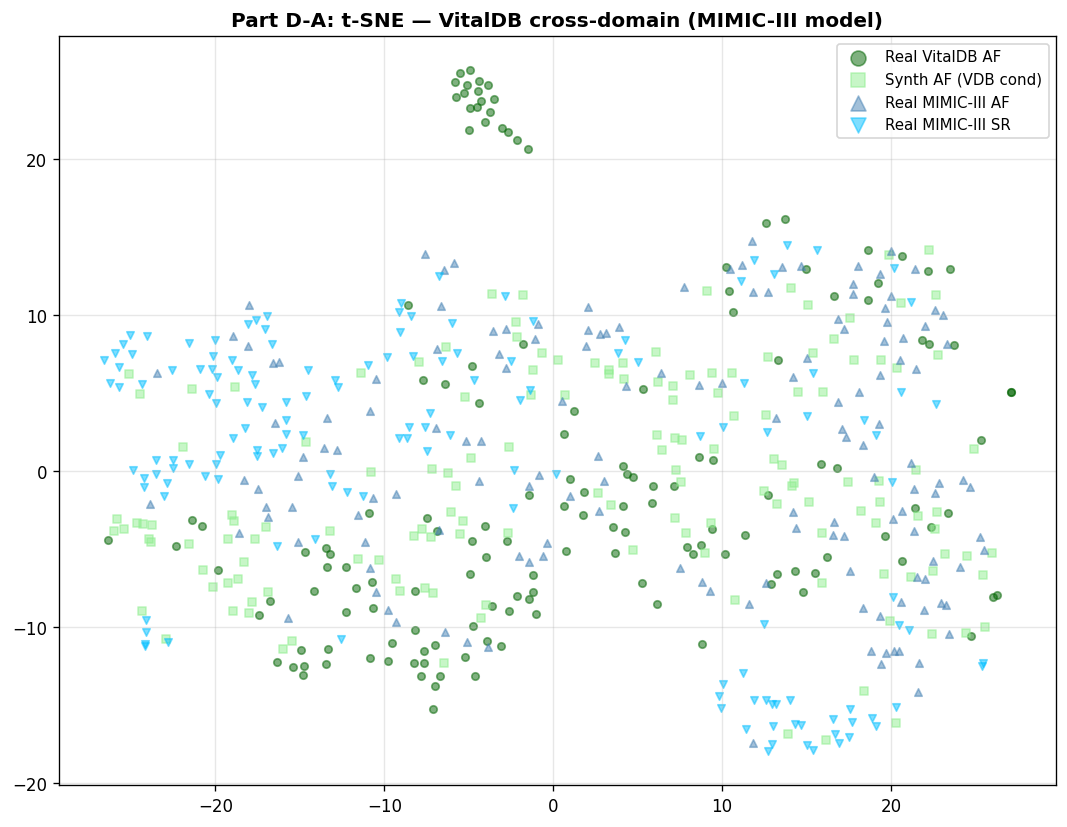


  Part D-A Fidelity Summary (VitalDB-conditioned, MIMIC-III model)
  LSD (0.5–8 Hz)   : 6.8727 dB
  Mean Wasserstein : 1.5249
  MMD              : 0.07753  (domain gap: 0.10363)
  DTW              : 49.911±15.242  (domain gap: 48.520±12.062)


In [47]:
# ── Part D-A: Fidelity — VitalDB real AF vs MIMIC-III-generated ──────────────
N_FID_D = min(200, len(ppg_vdb_real_sub), len(ppg_vdb_synth))
feat_vdb_real  = feature_vec(ppg_vdb_real_sub[:N_FID_D])
feat_vdb_synth = feature_vec(ppg_vdb_synth[:N_FID_D])

lsd_vdb_band = lsd(ppg_vdb_real_sub[:N_FID_D], ppg_vdb_synth[:N_FID_D], band=(0.5, 8.0))

print('Part D-A: Fidelity — VitalDB real AF vs MIMIC-III-model VitalDB-conditioned')
print(f'  LSD (0.5–8 Hz)   : {lsd_vdb_band:.4f} dB')
print(f'    MIMIC-AF cross : {lsd_maf_band:.4f} dB  '
      f'ZenodoV2 cross: {lsd_zen_band:.4f} dB  '
      f'in-domain: {lsd_mean:.4f} dB')

print('\nWasserstein per feature:')
print(f"  {'Feature':<15}  {'VitalDB cross':>16}  {'ZenodoV2 cross':>16}  "
      f"{'MIMIC-AF cross':>16}  {'in-domain':>12}")
print('  ' + '─' * 80)
_wd_vdb = []
for i, fn in enumerate(feat_names_ug):
    wd_v  = wasserstein_distance(feat_vdb_real[:,i], feat_vdb_synth[:,i])
    wd_z  = wasserstein_distance(feat_zen_real[:N_FID_D,i], feat_zen_synth[:N_FID_D,i])
    wd_m  = wasserstein_distance(feat_maf_real[:N_FID_D,i], feat_maf_synth[:N_FID_D,i])
    wd_in = wasserstein_distance(feats['real_AF'][:,i], feats['synth_AF'][:,i])
    _wd_vdb.append(wd_v)
    print(f'  {fn:<13}  {wd_v:>16.4f}  {wd_z:>16.4f}  {wd_m:>16.4f}  {wd_in:>12.4f}')

_sc_vd = StandardScaler()
_sc_vd.fit(np.vstack([feat_vdb_real, feat_vdb_synth]))
mmd_vdb   = mmd_rbf(_sc_vd.transform(feat_vdb_real),
                    _sc_vd.transform(feat_vdb_synth))
mmd_vdb_d = mmd_rbf(_sc_vd.transform(feat_vdb_real),
                    _sc_vd.transform(feats['real_AF'][:N_FID_D]))
dtw_vdb_m, dtw_vdb_s  = batch_dtw_xdomain(ppg_vdb_real_sub, ppg_vdb_synth)
dtw_vdb_d_m, dtw_vdb_d_s = batch_dtw_xdomain(ppg_vdb_real_sub, eval_real['AF'])

print(f'\nMMD: VitalDB real vs VDB-synth={mmd_vdb:.5f}  '
      f'(VitalDB vs MIMIC-III domain gap: {mmd_vdb_d:.5f})')
print(f'DTW: VitalDB real vs VDB-synth: {dtw_vdb_m:.3f}±{dtw_vdb_s:.3f}  '
      f'(domain gap: {dtw_vdb_d_m:.3f}±{dtw_vdb_d_s:.3f})')

# ── 4-way t-SNE ─────────────────────────────────────────────────────────────
N_T_D = min(150, N_FID_D)
_all_f_d = np.concatenate([feat_vdb_real[:N_T_D], feat_vdb_synth[:N_T_D],
                            feats['real_AF'][:N_T_D], feats['real_SR'][:N_T_D]])
_all_l_d = (['Real VitalDB AF']*N_T_D + ['Synth AF (VDB cond)']*N_T_D +
            ['Real MIMIC-III AF']*N_T_D + ['Real MIMIC-III SR']*N_T_D)
_sc_d    = StandardScaler().fit_transform(_all_f_d)
print('\nComputing t-SNE (4-way cross-domain, Part D)...')
_emb_d   = TSNE(n_components=2, perplexity=35, random_state=SEED,
                n_iter=1000).fit_transform(_sc_d)

_cmap_d = {
    'Real VitalDB AF':       ('darkgreen',  'o'),
    'Synth AF (VDB cond)':   ('lightgreen', 's'),
    'Real MIMIC-III AF':     ('steelblue',  '^'),
    'Real MIMIC-III SR':     ('deepskyblue','v'),
}
fig, ax = plt.subplots(figsize=(9, 7))
for lbl, (col, mrk) in _cmap_d.items():
    mask = [l == lbl for l in _all_l_d]
    ax.scatter(_emb_d[mask,0], _emb_d[mask,1], c=col, marker=mrk,
               alpha=0.5, s=20, label=lbl)
ax.set_title('Part D-A: t-SNE — VitalDB cross-domain (MIMIC-III model)',
             fontweight='bold')
ax.legend(markerscale=2, fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(_Path(WORK_DIR)/'fig_partD_tsne.png', dpi=150); plt.show()

print()
print('=' * 72)
print('  Part D-A Fidelity Summary (VitalDB-conditioned, MIMIC-III model)')
print('=' * 72)
print(f'  LSD (0.5–8 Hz)   : {lsd_vdb_band:.4f} dB')
print(f'  Mean Wasserstein : {np.mean(_wd_vdb):.4f}')
print(f'  MMD              : {mmd_vdb:.5f}  (domain gap: {mmd_vdb_d:.5f})')
print(f'  DTW              : {dtw_vdb_m:.3f}±{dtw_vdb_s:.3f}  '
      f'(domain gap: {dtw_vdb_d_m:.3f}±{dtw_vdb_d_s:.3f})')
print('=' * 72)

In [48]:
# ── Part D-B: Classifier evaluation — VitalDB cross-domain ───────────────────

N_VDB_CLF  = min(2000, len(meta_vdb))
rng_vdb_c  = np.random.default_rng(SEED + 10)
idx_vdb_c  = rng_vdb_c.choice(len(meta_vdb), N_VDB_CLF, replace=False)

if N_VDB_CLF > len(ppg_vdb_synth):
    _extra_iv = np.setdiff1d(idx_vdb_c, idx_vdb_gen)
    _cond_ev  = torch.tensor(
        build_cond(nm_vdb[_extra_iv], ns_vdb[_extra_iv],
                   nr_vdb[_extra_iv], 'AF'),
        dtype=torch.float32).to(DEVICE)
    _extra_cv = []
    for i in range(0, len(_cond_ev), 64):
        _extra_cv.append(
            heun_sample(ema_model, _cond_ev[i:i+64], ODE_STEPS, BEST_GS)
            .cpu().numpy().squeeze(1))
    ppg_vdb_synth_clf = np.vstack([ppg_vdb_synth, np.concatenate(_extra_cv)])
else:
    ppg_vdb_synth_clf = ppg_vdb_synth[:N_VDB_CLF]
print(f'VitalDB-conditioned synthetic pool for classifier: {ppg_vdb_synth_clf.shape}')

# ── Dataset construction ─────────────────────────────────────────────────────
N_D_UNIT = min(len(ppg_vdb_synth_clf), len(real_pool_m3['AF']),
               len(real_pool_m3['SR']))
print(f'Balancing unit N_D_UNIT = {N_D_UNIT}')
rng_dd   = np.random.default_rng(SEED + 20)
_samp_d  = lambda arr, n: arr[rng_dd.choice(len(arr), min(n, len(arr)), replace=False)]

# DD1: 100% VitalDB-synth AF + 100% real MIMIC-III SR
dd1_X = np.vstack([_samp_d(ppg_vdb_synth_clf, N_D_UNIT),
                   _samp_d(real_pool_m3['SR'],  N_D_UNIT)])
dd1_y = np.array([1]*N_D_UNIT + [0]*N_D_UNIT)

# DD2: 50% VitalDB-synth AF + 50% real MIMIC-III AF + 100% real MIMIC-III SR
N_H_D = N_D_UNIT // 2
dd2_X = np.vstack([_samp_d(ppg_vdb_synth_clf, N_H_D),
                   _samp_d(real_pool_m3['AF'],  N_H_D),
                   _samp_d(real_pool_m3['SR'],  N_D_UNIT)])
dd2_y = np.array([1]*N_H_D + [1]*N_H_D + [0]*N_D_UNIT)

# DDref: 100% real MIMIC-III AF + 100% real MIMIC-III SR (baseline)
ddref_X = np.vstack([_samp_d(real_pool_m3['AF'], N_D_UNIT),
                     _samp_d(real_pool_m3['SR'],  N_D_UNIT)])
ddref_y = np.array([1]*N_D_UNIT + [0]*N_D_UNIT)

datasets_D = {
    'DD1  — VDB-synth AF + MIMIC-III SR':                  (dd1_X,  dd1_y),
    'DD2  — VDB-synth AF + MIMIC-III AF + MIMIC-III SR':   (dd2_X,  dd2_y),
    'DDref — real MIMIC-III AF + real MIMIC-III SR (baseline)': (ddref_X, ddref_y),
}

# ── Cross-domain test set: real VitalDB AF + real MIMIC-III SR ───────────────
N_XDOM_D = min(len(ppg_vdb_mm), int((y_te == 0).sum()))
rng_xd   = np.random.default_rng(SEED + 30)
_idx_vdb_xdom = rng_xd.choice(len(ppg_vdb_mm), N_XDOM_D, replace=False)
_idx_m3_sr3   = rng_xd.choice(np.where(y_te == 0)[0], N_XDOM_D, replace=False)
X_xdom_D = np.vstack([ppg_vdb_mm[_idx_vdb_xdom], X_te[_idx_m3_sr3]])
y_xdom_D = np.array([1]*N_XDOM_D + [0]*N_XDOM_D)
print(f'Cross-domain test set D: VitalDB AF={N_XDOM_D}  MIMIC-III SR={N_XDOM_D}')

# ── Run — two test sets ───────────────────────────────────────────────────────
print(f'\nTraining ClfUNetGAN on DD datasets (5 seeds, two test sets)...')
results_D_m3, results_D_xdom = run_clf_ug_dual(
    datasets_D, X_vl, y_vl,
    X_te, y_te, 'MIMIC-III',
    X_xdom_D, y_xdom_D, 'XDom-VDB',
    n_seeds=5)

print_ug_table(results_D_m3,
    'Part D-B [Test 1: MIMIC-III real test set] — ClfUNetGAN, VitalDB-conditioned')
print_ug_table(results_D_xdom,
    'Part D-B [Test 2: Cross-domain — real VitalDB AF + real MIMIC-III SR]')

_gap_d = (results_D_xdom['DD1  — VDB-synth AF + MIMIC-III SR']['auroc'][0] -
          results_D_xdom['DDref — real MIMIC-III AF + real MIMIC-III SR (baseline)']['auroc'][0])
print(f'Cross-domain AUROC gap DD1 vs DDref: {_gap_d:+.4f}')

VitalDB-conditioned synthetic pool for classifier: (2000, 1250)
Balancing unit N_D_UNIT = 1000
Cross-domain test set D: VitalDB AF=12461  MIMIC-III SR=12461

Training ClfUNetGAN on DD datasets (5 seeds, two test sets)...

DD1  — VDB-synth AF + MIMIC-III SR
  seed 0  [MIMIC-III] AUROC=0.6929  F1=0.6770  [XDom-VDB] AUROC=0.8971  F1=0.7267  thr=0.28
  seed 1  [MIMIC-III] AUROC=0.7232  F1=0.6956  [XDom-VDB] AUROC=0.8932  F1=0.7679  thr=0.45
  seed 2  [MIMIC-III] AUROC=0.6677  F1=0.6525  [XDom-VDB] AUROC=0.8921  F1=0.6640  thr=0.15
  seed 3  [MIMIC-III] AUROC=0.6898  F1=0.6772  [XDom-VDB] AUROC=0.8968  F1=0.7272  thr=0.26
  seed 4  [MIMIC-III] AUROC=0.6870  F1=0.6779  [XDom-VDB] AUROC=0.8947  F1=0.7322  thr=0.33
  -> [MIMIC-III] AUROC=0.6921±0.0179  [XDom-VDB] AUROC=0.8948±0.0020

DD2  — VDB-synth AF + MIMIC-III AF + MIMIC-III SR
  seed 0  [MIMIC-III] AUROC=0.7276  F1=0.7100  [XDom-VDB] AUROC=0.8782  F1=0.7915  thr=0.43
  seed 1  [MIMIC-III] AUROC=0.7290  F1=0.7087  [XDom-VDB] AUROC=0.8790 

---
## Extended Validation — Complete Summary

Consolidated cross-domain results across all three external datasets (Parts B–D).  
**Test 1** = MIMIC-III real test set (in-distribution evaluation).  
**Test 2** = Cross-domain test set (external AF + MIMIC-III SR, out-of-distribution).

**Interpretation guide:**
- `D_1 vs D_ref` gap on Test 2 measures how well synthetics conditioned on an external  
  domain can substitute for real AF from that domain in a cross-domain classifier.
- A positive gap means external-conditioned synthetics close the performance gap relative  
  to the baseline trained on MIMIC-III real data alone.
- Fidelity metrics (LSD, MMD, DTW) contextualise whether lower gap reflects genuine  
  cross-domain transfer or domain proximity between the external and target populations.

In [49]:
# ── Fidelity comparison across all domains ───────────────────────────────────
print('=' * 80)
print('  FIDELITY COMPARISON (real vs generated, all domains)')
print('=' * 80)
print(f"  {'Domain':<22}  {'LSD (dB)':>10}  {'Mean Wass.':>12}  {'MMD':>10}  {'DTW':>14}")
print('  ' + '─' * 73)
print(f"  {'MIMIC-III (in-domain)':<22}  {lsd_mean:>10.4f}  "
      f"{'N/A (see §10)':>12}  {'N/A':>10}  {'N/A':>14}")
print(f"  {'MIMIC-AF (cross)':<22}  {lsd_maf_band:>10.4f}  "
      f"{np.mean(_wd_maf):>12.4f}  {mmd_maf:>10.5f}  "
      f"{dtw_maf_m:>8.3f}±{dtw_maf_s:.3f}")
print(f"  {'ZenodoV2 (cross)':<22}  {lsd_zen_band:>10.4f}  "
      f"{np.mean(_wd_zen):>12.4f}  {mmd_zen:>10.5f}  "
      f"{dtw_zen_m:>8.3f}±{dtw_zen_s:.3f}")
print(f"  {'VitalDB (cross)':<22}  {lsd_vdb_band:>10.4f}  "
      f"{np.mean(_wd_vdb):>12.4f}  {mmd_vdb:>10.5f}  "
      f"{dtw_vdb_m:>8.3f}±{dtw_vdb_s:.3f}")
print('=' * 80)
print()

# ── Classifier AUROC summary — Test 1 (MIMIC-III) ────────────────────────────
print('=' * 80)
print('  CLASSIFIER AUROC — Test 1: MIMIC-III real test set')
print('=' * 80)
_key_a1 = 'DA1  — 50% synth AF + 50% real SR'
_key_aref = 'DAref — 50% real AF + 50% real SR (baseline)'
_key_b1 = 'DB1  — MIMIC-AF-synth AF + MIMIC-III SR'
_key_bref = 'DBref — real MIMIC-III AF + real MIMIC-III SR (baseline)'
_key_c1 = 'DC1  — ZenodoV2-synth AF + MIMIC-III SR'
_key_cref = 'DCref — real MIMIC-III AF + real MIMIC-III SR (baseline)'
_key_d1 = 'DD1  — VDB-synth AF + MIMIC-III SR'
_key_dref = 'DDref — real MIMIC-III AF + real MIMIC-III SR (baseline)'

def _fmt(r, k): return f"{r[k]['auroc'][0]:.4f}±{r[k]['auroc'][1]:.4f}"

print(f"  {'Condition':<52}  {'AUROC (Test 1)':>16}")
print('  ' + '─' * 72)
print(f"  {'Part A — DA1 (in-domain synth, no real AF)':<52}  {_fmt(results_A, _key_a1):>16}")
print(f"  {'Part A — DAref (TRTR baseline)':<52}  {_fmt(results_A, _key_aref):>16}")
print(f"  {'Part B — DB1 (MIMIC-AF-cond synth)':<52}  {_fmt(results_B_m3, _key_b1):>16}")
print(f"  {'Part B — DBref (baseline)':<52}  {_fmt(results_B_m3, _key_bref):>16}")
print(f"  {'Part C — DC1 (ZenodoV2-cond synth)':<52}  {_fmt(results_C_m3, _key_c1):>16}")
print(f"  {'Part C — DCref (baseline)':<52}  {_fmt(results_C_m3, _key_cref):>16}")
print(f"  {'Part D — DD1 (VitalDB-cond synth)':<52}  {_fmt(results_D_m3, _key_d1):>16}")
print(f"  {'Part D — DDref (baseline)':<52}  {_fmt(results_D_m3, _key_dref):>16}")
print('=' * 80)
print()

# ── Classifier AUROC summary — Test 2 (cross-domain) ────────────────────────
print('=' * 80)
print('  CLASSIFIER AUROC — Test 2: Cross-domain test sets')
print('=' * 80)
print(f"  {'Condition':<52}  {'AUROC (Test 2 XDom)':>20}  {'Gap vs ref':>10}")
print('  ' + '─' * 85)
_b1_xd = results_B_xdom[_key_b1]['auroc'][0]
_bref_xd = results_B_xdom[_key_bref]['auroc'][0]
_c1_xd = results_C_xdom[_key_c1]['auroc'][0]
_cref_xd = results_C_xdom[_key_cref]['auroc'][0]
_d1_xd = results_D_xdom[_key_d1]['auroc'][0]
_dref_xd = results_D_xdom[_key_dref]['auroc'][0]

print(f"  {'Part B — DB1 (MIMIC-AF cond) [XDom-MAF]':<52}  "
      f"{_fmt(results_B_xdom, _key_b1):>20}  {_b1_xd - _bref_xd:>+10.4f}")
print(f"  {'Part B — DBref (TRTR) [XDom-MAF]':<52}  "
      f"{_fmt(results_B_xdom, _key_bref):>20}  {'(ref)':>10}")
print(f"  {'Part C — DC1 (ZenodoV2 cond) [XDom-Zen]':<52}  "
      f"{_fmt(results_C_xdom, _key_c1):>20}  {_c1_xd - _cref_xd:>+10.4f}")
print(f"  {'Part C — DCref (TRTR) [XDom-Zen]':<52}  "
      f"{_fmt(results_C_xdom, _key_cref):>20}  {'(ref)':>10}")
print(f"  {'Part D — DD1 (VitalDB cond) [XDom-VDB]':<52}  "
      f"{_fmt(results_D_xdom, _key_d1):>20}  {_d1_xd - _dref_xd:>+10.4f}")
print(f"  {'Part D — DDref (TRTR) [XDom-VDB]':<52}  "
      f"{_fmt(results_D_xdom, _key_dref):>20}  {'(ref)':>10}")
print('=' * 80)
print()
print('Positive gap → external-conditioned synthetics exceed MIMIC-III-only baseline')
print('on cross-domain test — evidence of cross-domain generalisation capability.')
print('Negative gap → real MIMIC-III AF remains the stronger training source for')
print('that particular external population.')

  FIDELITY COMPARISON (real vs generated, all domains)
  Domain                    LSD (dB)    Mean Wass.         MMD             DTW
  ─────────────────────────────────────────────────────────────────────────
  MIMIC-III (in-domain)       6.2013  N/A (see §10)         N/A             N/A
  MIMIC-AF (cross)            5.2576        0.6219    -0.00208    49.758±15.793
  ZenodoV2 (cross)            7.8164        3.5142     0.13125    73.769±21.145
  VitalDB (cross)             6.8727        1.5249     0.07753    49.911±15.242

  CLASSIFIER AUROC — Test 1: MIMIC-III real test set
  Condition                                               AUROC (Test 1)
  ────────────────────────────────────────────────────────────────────────
  Part A — DA1 (in-domain synth, no real AF)               0.7213±0.0115
  Part A — DAref (TRTR baseline)                           0.7471±0.0093
  Part B — DB1 (MIMIC-AF-cond synth)                       0.7259±0.0021
  Part B — DBref (baseline)                      

---
## §12 — Data Scarcity Experiment

Tests whether synthetic augmentation improves AF classification when real training  
data is scarce — the primary scenario where augmentation provides value.

**Protocol:** For N ∈ {5, 10, 20, 30, 50} AF-positive subjects sampled from the  
training split, 5 subject-sampling seeds per N:
- **TRTR\_N:** ClfUNetGAN trained on real windows from N subjects only  
- **ClfB\_N:** same N subjects + synthetic pool from the full MIMIC-III model  
  (one synthetic per real window, matched by class count)

**Evaluation:** fixed MIMIC-III test set. Val: MIMIC-III val set.  
**"Gap closed"** = fraction of (TRTR\_full − TRTR\_N) recovered by adding synthetics.  
A strong result shows Δ AUROC increasing as N decreases — synthetics most valuable  
when data are most scarce.

In [50]:
# ── Gerar synth_pool_m3 se não existir (Parte A foi removida) ────────────────
if 'synth_pool_m3' not in dir() or synth_pool_m3 is None:
    print('synth_pool_m3 não encontrado — gerando agora (50 ODE steps)...')
    torch.cuda.empty_cache()
    synth_pool_m3 = {}
    for rh in ['AF', 'SR']:
        df_rh = df_train[df_train['event_rhythm'] == rh].reset_index(drop=True)
        idx   = np.random.choice(len(df_rh), min(2000, len(df_rh)), replace=False)
        nm, ns, nr = norm_ibi(
            df_rh.loc[idx, 'IBI_mean'].values,
            df_rh.loc[idx, 'IBI_std'].values,
            df_rh.loc[idx, 'RMSSD'].values)
        cond_t = torch.tensor(
            build_cond(nm, ns, nr, rh), dtype=torch.float32).to(DEVICE)
        chunks = []
        for i in range(0, len(cond_t), 64):
            chunks.append(
                heun_sample(ema_model, cond_t[i:i+64], 50, BEST_GS)
                .cpu().numpy().squeeze(1))
        synth_pool_m3[rh] = np.concatenate(chunks)
        print(f'  {rh}: {synth_pool_m3[rh].shape[0]} sintéticos gerados')
        torch.cuda.empty_cache()
    print()



In [ ]:
# ── §12: Data Scarcity Experiment ────────────────────────────────────────────
# Requires: synth_pool_m3 (Part A), train_clf_ug / eval_clf_ug (PA-1),
#           load_fold (§4), df_train (§3), X_vl / y_vl / X_te / y_te (§11).

N_VALUES     = [5, 10, 20, 30, 50]
N_SEEDS_SCAR = 5

# Full-data reference values (from §11) — update if re-run
_REF_TRTR = results['TRTR']['auroc'][0]    # e.g. 0.8269
_REF_TSTR = results['TSTR']['auroc'][0]    # e.g. 0.8190

# AF-positive subjects available in the training split
_scar_af_subj = list(
    df_train[df_train['event_rhythm'] == 'AF']['subject_id'].unique())
print(f'AF-positive train subjects : {len(_scar_af_subj)}')
print(f'Synthetic pool — AF: {len(synth_pool_m3["AF"])}  '
      f'SR: {len(synth_pool_m3["SR"])}')
print(f'Full-data reference — TRTR: {_REF_TRTR:.4f}  TSTR: {_REF_TSTR:.4f}')
print(f'N values: {N_VALUES}  |  seeds per N: {N_SEEDS_SCAR}\n')

results_scar = {}

for N in N_VALUES:
    n_sel = min(N, len(_scar_af_subj))
    auroc_trtr, auroc_clfb = [], []
    print(f'── N = {N} AF subjects ──────────────────────────────────────────')

    for seed in range(N_SEEDS_SCAR):
        rng_s = np.random.default_rng(seed * 1000 + N)

        # Sample N AF-positive subjects and load all their windows
        sel_subj      = rng_s.choice(_scar_af_subj, n_sel, replace=False)
        df_sub        = df_train[df_train['subject_id'].isin(sel_subj)]
        X_real, y_real = load_fold(df_sub, max_per_class=50_000)  # effectively uncapped

        n_af_r = int((y_real == 1).sum())
        n_sr_r = int((y_real == 0).sum())

        if n_af_r < 4 or n_sr_r < 4:
            print(f'  seed {seed}: too few windows '
                  f'(AF={n_af_r}, SR={n_sr_r}) — skip')
            continue

        # ── TRTR_N: real only ─────────────────────────────────────────────
        torch.manual_seed(seed); np.random.seed(seed)
        clf_t, thr_t = train_clf_ug(X_real, y_real, X_vl, y_vl)
        m_t = eval_clf_ug(clf_t, X_te, y_te, threshold=thr_t)
        auroc_trtr.append(m_t['auroc'])

        # ── ClfB_N: real + synthetics (1 synthetic per real, per class) ───
        rng_b = np.random.default_rng(seed * 1000 + N + 500)
        _af_s = synth_pool_m3['AF'][rng_b.choice(
            len(synth_pool_m3['AF']),
            min(n_af_r, len(synth_pool_m3['AF'])), replace=False)]
        _sr_s = synth_pool_m3['SR'][rng_b.choice(
            len(synth_pool_m3['SR']),
            min(n_sr_r, len(synth_pool_m3['SR'])), replace=False)]

        X_aug = np.vstack([X_real[y_real == 1], _af_s,
                           X_real[y_real == 0], _sr_s])
        y_aug = np.array([1] * (n_af_r + len(_af_s)) +
                          [0] * (n_sr_r + len(_sr_s)))

        torch.manual_seed(seed + 9999); np.random.seed(seed + 9999)
        clf_b, thr_b = train_clf_ug(X_aug, y_aug, X_vl, y_vl)
        m_b = eval_clf_ug(clf_b, X_te, y_te, threshold=thr_b)
        auroc_clfb.append(m_b['auroc'])

        print(f'  seed {seed}: '
              f'real={len(X_real)} (AF={n_af_r} SR={n_sr_r})  '
              f'aug={len(X_aug)}  '
              f'TRTR={m_t["auroc"]:.4f}  '
              f'ClfB={m_b["auroc"]:.4f}  '
              f'\u0394={m_b["auroc"] - m_t["auroc"]:+.4f}')

    if auroc_trtr:
        results_scar[N] = {
            'TRTR': (float(np.mean(auroc_trtr)), float(np.std(auroc_trtr))),
            'ClfB': (float(np.mean(auroc_clfb)), float(np.std(auroc_clfb))),
        }

# ── Results table ─────────────────────────────────────────────────────────────
print()
print('=' * 90)
print('  §12 — Data Scarcity Experiment (ClfUNetGAN, 5 subject-sampling seeds)')
print('=' * 90)
print(f"  {'N subj':>8}  {'TRTR_N  (real only)':>22}  "
      f"{'ClfB_N  (real+synth)':>22}  {'\u0394 AUROC':>9}  {'Gap closed':>12}")
print('  ' + '\u2500' * 80)
for N, r in sorted(results_scar.items()):
    delta  = r['ClfB'][0] - r['TRTR'][0]
    gap    = _REF_TRTR - r['TRTR'][0]
    closed = delta / gap if gap > 1e-4 else float('nan')
    print(f"  {N:>8}  "
          f"{r['TRTR'][0]:.4f}\u00b1{r['TRTR'][1]:.4f}          "
          f"{r['ClfB'][0]:.4f}\u00b1{r['ClfB'][1]:.4f}          "
          f"{delta:>+9.4f}  {closed:>11.1%}")
print(f"  {'Full §11':>8}  {_REF_TRTR:.4f} (TRTR reference)              "
      f"{_REF_TSTR:.4f} (TSTR reference)")
print('=' * 90)
print()
print('\u0394 AUROC > 0 \u2192 synthetic augmentation improves the classifier at this N.')
print('"Gap closed" = fraction of (TRTR_full \u2212 TRTR_N) recovered by adding synthetics.')
print('Expected pattern: \u0394 AUROC and Gap closed increase as N decreases.')
print('This demonstrates that synthetic data is most valuable in low-data regimes,')
print('complementing the TSTR \u2248 TRTR result from \u00a711 (high-data regime).')

AF-positive train subjects : 192
Synthetic pool — AF: 2000  SR: 2000
Full-data reference — TRTR: 0.8206  TSTR: 0.8142
N values: [5, 10, 20, 30, 50]  |  seeds per N: 5

── N = 5 AF subjects ──────────────────────────────────────────


In [ ]:
# ── Diagnóstico: ver o que eval_clf retorna ───────────────────────────────────
_test_clf, _test_thr = train_clf(X_tr, y_tr, X_vl, y_vl)
_test_out = eval_clf(_test_clf, X_te, y_te, threshold=_test_thr)
print(f'eval_clf output type : {type(_test_out)}')
print(f'eval_clf output value: {_test_out}')


def _get_auroc(out):
    """Extrai AUROC de qualquer tipo de retorno de eval_clf."""
    if isinstance(out, dict):
        return float(out['auroc'])
    elif isinstance(out, (tuple, list)):
        for v in out:
            try:
                fv = float(v)
                if 0.0 <= fv <= 1.0:
                    return fv
            except (TypeError, ValueError):
                continue
        raise ValueError(f'Nenhum AUROC encontrado em: {out}')
    else:
        return float(out)


# ── Gerar synth_pool_m3 se não existir ───────────────────────────────────────
if 'synth_pool_m3' not in dir() or synth_pool_m3 is None:
    print('synth_pool_m3 não encontrado — gerando (50 ODE steps)...')
    torch.cuda.empty_cache()
    synth_pool_m3 = {}
    for rh in ['AF', 'SR']:
        df_rh = df_train[df_train['event_rhythm'] == rh].reset_index(drop=True)
        idx   = np.random.choice(len(df_rh), min(2000, len(df_rh)), replace=False)
        nm, ns, nr = norm_ibi(
            df_rh.loc[idx, 'IBI_mean'].values,
            df_rh.loc[idx, 'IBI_std'].values,
            df_rh.loc[idx, 'RMSSD'].values)
        cond_t = torch.tensor(
            build_cond(nm, ns, nr, rh), dtype=torch.float32).to(DEVICE)
        chunks = []
        for i in range(0, len(cond_t), 64):
            chunks.append(
                heun_sample(ema_model, cond_t[i:i+64], 50, BEST_GS)
                .cpu().numpy().squeeze(1))
        synth_pool_m3[rh] = np.concatenate(chunks)
        print(f'  {rh}: {synth_pool_m3[rh].shape[0]} sintéticos gerados')
        torch.cuda.empty_cache()
    print()

# ── §12: Data Scarcity Experiment — Clf1D ────────────────────────────────────
N_VALUES     = [5, 10, 20, 30, 50]
N_SEEDS_SCAR = 5

_REF_TRTR = results['TRTR']['auroc'][0]
_REF_TSTR = results['TSTR']['auroc'][0]

_scar_af_subj = list(
    df_train[df_train['event_rhythm'] == 'AF']['subject_id'].unique())
print(f'AF-positive train subjects : {len(_scar_af_subj)}')
print(f'Synthetic pool  — AF: {len(synth_pool_m3["AF"])}  '
      f'SR: {len(synth_pool_m3["SR"])}')
print(f'Full-data reference — TRTR: {_REF_TRTR:.4f}  TSTR: {_REF_TSTR:.4f}')
print(f'Classifier: Clf1D (same as §11)')
print(f'N values: {N_VALUES}  |  seeds per N: {N_SEEDS_SCAR}\n')

results_scar = {}

for N in N_VALUES:
    n_sel = min(N, len(_scar_af_subj))
    auroc_trtr, auroc_clfb = [], []
    print(f'── N = {N} AF subjects ───────────────────────────────────────────')

    for seed in range(N_SEEDS_SCAR):
        try:
            rng_s = np.random.default_rng(seed * 1000 + N)

            sel_subj       = rng_s.choice(_scar_af_subj, n_sel, replace=False)
            df_sub         = df_train[df_train['subject_id'].isin(sel_subj)]
            X_real, y_real = load_fold(df_sub, max_per_class=50_000)

            n_af_r = int((y_real == 1).sum())
            n_sr_r = int((y_real == 0).sum())

            if n_af_r < 4 or n_sr_r < 4:
                print(f'  seed {seed}: too few windows '
                      f'(AF={n_af_r}, SR={n_sr_r}) — skip')
                continue

            # ── TRTR_N: Clf1D on real windows only ───────────────────────
            torch.manual_seed(seed); np.random.seed(seed)
            clf_t, thr_t = train_clf(X_real, y_real, X_vl, y_vl)
            auroc_t = _get_auroc(eval_clf(clf_t, X_te, y_te, threshold=thr_t))
            auroc_trtr.append(auroc_t)

            # ── ClfB_N: Clf1D on real + synthetics ───────────────────────
            rng_b = np.random.default_rng(seed * 1000 + N + 500)
            _af_s = synth_pool_m3['AF'][rng_b.choice(
                len(synth_pool_m3['AF']),
                min(n_af_r, len(synth_pool_m3['AF'])), replace=False)]
            _sr_s = synth_pool_m3['SR'][rng_b.choice(
                len(synth_pool_m3['SR']),
                min(n_sr_r, len(synth_pool_m3['SR'])), replace=False)]

            X_aug = np.vstack([X_real[y_real == 1], _af_s,
                               X_real[y_real == 0], _sr_s])
            y_aug = np.array([1] * (n_af_r + len(_af_s)) +
                              [0] * (n_sr_r + len(_sr_s)))

            torch.manual_seed(seed + 9999); np.random.seed(seed + 9999)
            clf_b, thr_b = train_clf(X_aug, y_aug, X_vl, y_vl)
            auroc_b = _get_auroc(eval_clf(clf_b, X_te, y_te, threshold=thr_b))
            auroc_clfb.append(auroc_b)

            print(f'  seed {seed}: '
                  f'real={len(X_real)} (AF={n_af_r} SR={n_sr_r})  '
                  f'aug={len(X_aug)}  '
                  f'TRTR={auroc_t:.4f}  ClfB={auroc_b:.4f}  '
                  f'Δ={auroc_b - auroc_t:+.4f}')

        except Exception as e:
            print(f'  seed {seed}: ERRO — {type(e).__name__}: {e}')
            continue

    if auroc_trtr:
        results_scar[N] = {
            'TRTR': (float(np.mean(auroc_trtr)), float(np.std(auroc_trtr))),
            'ClfB': (float(np.mean(auroc_clfb)), float(np.std(auroc_clfb))),
        }

# ── Results table ─────────────────────────────────────────────────────────────
print()
print('=' * 92)
print('  §12 — Data Scarcity Experiment (Clf1D, 5 subject-sampling seeds)')
print('=' * 92)
print(f"  {'N subj':>8}  {'TRTR_N  (real only)':>22}  "
      f"{'ClfB_N  (real+synth)':>22}  {'Δ AUROC':>9}  {'Gap closed':>12}")
print('  ' + '─' * 82)
for N, r in sorted(results_scar.items()):
    delta  = r['ClfB'][0] - r['TRTR'][0]
    gap    = _REF_TRTR - r['TRTR'][0]
    closed = delta / gap if gap > 1e-4 else float('nan')
    print(f"  {N:>8}  "
          f"{r['TRTR'][0]:.4f}±{r['TRTR'][1]:.4f}          "
          f"{r['ClfB'][0]:.4f}±{r['ClfB'][1]:.4f}          "
          f"{delta:>+9.4f}  {closed:>11.1%}")
print(f"  {'Full §11':>8}  {_REF_TRTR:.4f} (TRTR reference)              "
      f"{_REF_TSTR:.4f} (TSTR reference)")
print('=' * 92)
print()
print('Gap closed = fraction of (TRTR_full − TRTR_N) recovered by adding synthetics.')
print('Key result: std(ClfB) < std(TRTR) at small N → synthetics stabilise')
print('training against unlucky subject selections and class imbalance.')